In [1]:
# plot detection examples
import numpy as np
import matplotlib.pyplot as plt
import mne

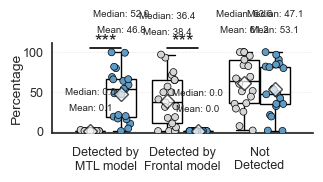

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

# === Load and preprocess data ===
# df = pd.read_excel(r"\\132.66.207.73\rem\35. RotemV\frontal_channels\Plot Data in Excel\kfold_xgb\kfold_xgb_boxplot.xlsx")
df = pd.read_excel(r"figures\kfold_xgb_boxplot.xlsx")

df = df[
    (df['Depth Category'] != 'Both Depth') &
    (df['Scalp Detection Type'] != 'Both Scalp')
]

df['Scalp Detection Type'] = df['Scalp Detection Type'].replace({
    'MTL Scalp': 'Detected by\nMTL model',
    'Frontal Scalp': 'Detected by\nFrontal model',
    'Not Detected': 'Not\nDetected'
})
df['Depth Category'] = df['Depth Category'].replace({
    'Only Frontal Depth': 'Frontal IEDs',
    'Only MTL Depth': 'MTL IEDs'
})

# === Style ===
sns.set_context("notebook", font_scale=1.3)
sns.set_style("white")

fig, ax = plt.subplots(figsize=(3.5, 2.5))

depth_palette = {
    'MTL IEDs': '#5E9BC7',
    'Frontal IEDs': '#d5d6d7' 
}

# === Boxplot ===
sns.boxplot(
    x='Scalp Detection Type',
    y='Percentage',
    hue='Depth Category',
    data=df,
    ax=ax,
    palette=['white'] * len(df['Depth Category'].unique()),  # Boxes white,
    showfliers=False,
    linewidth=1,
    boxprops=dict(edgecolor='black', facecolor='white'),
    medianprops=dict(color='black', linewidth=1),
    whiskerprops=dict(color='black', linewidth=1),
    capprops=dict(color='black', linewidth=1)
)


sns.stripplot(
    x='Scalp Detection Type',
    y='Percentage',
    hue='Depth Category',
    data=df,
    dodge=True,
    jitter=0.25,
    size=5,
    palette=depth_palette,
    edgecolor='black',
    linewidth=0.5,
    ax=ax
)

# === Black diamonds for means ===
group_means = df.groupby(['Scalp Detection Type', 'Depth Category'])['Percentage'].mean().reset_index()
for i, x_cat in enumerate(df['Scalp Detection Type'].unique()):
    for j, depth_cat in enumerate(df['Depth Category'].unique()):
        subset = group_means[
            (group_means['Scalp Detection Type'] == x_cat) &
            (group_means['Depth Category'] == depth_cat)
        ]
        if not subset.empty:
            x_pos = i - 0.2 + j * 0.4
            y_mean = subset['Percentage'].values[0]
            ax.plot(x_pos, y_mean, marker='D', markerfacecolor='white', markeredgecolor='black', markersize=7, alpha=0.7, zorder=3)

# === Calculate means and medians ===
group_stats = df.groupby(['Scalp Detection Type', 'Depth Category'])['Percentage'].agg(['mean', 'median']).reset_index()

for i, x_cat in enumerate(df['Scalp Detection Type'].unique()):
    for j, depth_cat in enumerate(df['Depth Category'].unique()):
        subset = group_stats[
            (group_stats['Scalp Detection Type'] == x_cat) &
            (group_stats['Depth Category'] == depth_cat)
        ]
        if not subset.empty:
            x_pos = i - 0.2 + j * 0.4
            y_max = df[
                (df['Scalp Detection Type'] == x_cat) &
                (df['Depth Category'] == depth_cat)
            ]['Percentage'].max()
            
            # ממקמים את הטקסט קצת מעל הנקודות העליונות
            y_text = y_max + 3  

            mean_val = subset['mean'].values[0]
            median_val = subset['median'].values[0]

            ax.text(x_pos, y_text + 20,     f"Mean: {mean_val:.1f}", ha='center', va='bottom', fontsize=7)
            ax.text(x_pos, y_text+40,   f"Median: {median_val:.1f}", ha='center', va='bottom', fontsize=7)


# === Stats: t-tests and significance ===
groups = df['Scalp Detection Type'].unique()
depths = df['Depth Category'].unique()
pvals = []
pairs = []

for x_cat in groups:
    vals = []
    for d_cat in depths:
        subset = df[
            (df['Scalp Detection Type'] == x_cat) &
            (df['Depth Category'] == d_cat)
        ]['Percentage'].dropna()
        vals.append(subset)
    if len(vals) == 2:
        stat, p = ttest_ind(vals[0], vals[1], equal_var=False)
        pvals.append(p)
        pairs.append((x_cat, depths[0], depths[1]))

# Bonferroni correction
reject, pvals_corrected, _, _ = multipletests(pvals, method='bonferroni')

# === Add aligned stars ===
star_y = df['Percentage'].max() + 7
line_y = star_y - 2
for i, (x_cat, d1, d2) in enumerate(pairs):
    if not reject[i]:
        continue
    star = '***' if pvals_corrected[i] < 0.001 else '**' if pvals_corrected[i] < 0.01 else '*'
    x_idx = list(groups).index(x_cat)
    ax.plot([x_idx - 0.2, x_idx + 0.2], [line_y] * 2, color='black', linewidth=1.2)
    ax.text(x_idx, star_y-5, star, ha='center', va='bottom', fontsize=14)

# === Final formatting ===
ax.set_ylabel('Percentage', fontsize=10, labelpad=0)
ax.set_xlabel('')
ax.set_ylim(bottom=-2, top=star_y + 5)
ax.tick_params(axis='x', labelsize=9)
ax.tick_params(axis='y', labelsize=9, pad=0)
ax.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.4)

# === Legend inside top right, deduplicated ===
# Get only boxplot handles for legend
box_handles, box_labels = ax.get_legend_handles_labels()

# Keep only the first 2 handles (Frontal IEDs, MTL IEDs) from the boxplot
ax.legend(
    handles=box_handles[:2],
    labels=box_labels[:2],
    loc='upper center',
    bbox_to_anchor=(0.5, 1.22),  # adjust vertical placement
    ncol=2,
    frameon=False,
    fontsize=11
)
ax.legend_.remove()


sns.despine()
plt.tight_layout(rect=[0, 0, 1, 0.95])  # leave space at the top for the legend
# save
# plt.savefig('figures/frontal_boxplot_flipped.png', dpi=300, bbox_inches='tight', transparent=False)
plt.show()


In [9]:
group_stats['mean ± std'] = group_stats.apply(
    lambda r: f"{r['mean']:.2f} ± {r['std']:.2f}", axis=1
)

display(group_stats[['Scalp Detection Type', 'Depth Category', 'mean ± std']])


,Scalp Detection Type,Depth Category,mean ± std
0,Detected by\nFrontal model,Frontal IEDs,38.41 ± 31.29
1,Detected by\nFrontal model,MTL IEDs,0.01 ± 0.03
2,Detected by\nMTL model,Frontal IEDs,0.09 ± 0.31
3,Detected by\nMTL model,MTL IEDs,46.82 ± 31.03
4,Not\nDetected,Frontal IEDs,61.17 ± 31.68
5,Not\nDetected,MTL IEDs,53.14 ± 31.06


C:\Users\user\AppData\Local\Temp\ipykernel_10800\1198895442.py:116: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


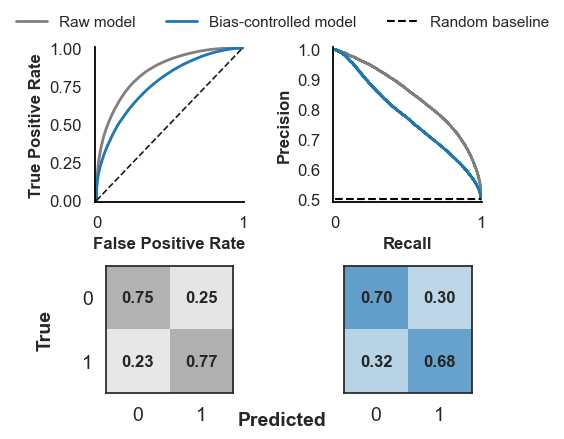

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
from matplotlib.colors import to_rgb
import seaborn as sns
from matplotlib.gridspec import GridSpec

# === Setup ===
sns.set_context("notebook", font_scale=1.3)
sns.set_style("white")
fig = plt.figure(figsize=(5, 4.5))
gs = GridSpec(2, 2, height_ratios=[1.1, 0.9], hspace=0.45, wspace=0.6)

# === ROC & PR Curves (Top Row) ===
roc1 = pd.read_csv('figures/roc_curve_bmax_asym.csv')
metrics1 = pd.read_csv('figures/curve_bmax_asym_metrics.csv')
roc2 = pd.read_csv('figures/roc_curve_b3000_sym.csv')
metrics2 = pd.read_csv('figures/roc_curve_b3000_sym_metrics.csv')
pr1 = pd.read_csv('figures/pr_curve_bmax_asym.csv')
pr2 = pd.read_csv('figures/pr_curve_b3000_sym.csv')

# ROC Curve
# ROC Curve
ax_roc = fig.add_subplot(gs[0, 0])
roc_line1, = ax_roc.plot(roc1['fpr'], roc1['tpr'], label='Raw model', linewidth=2, color='#7f7f7f')  # gray
roc_line2, = ax_roc.plot(roc2['fpr'], roc2['tpr'], label='Bias-controlled model', linewidth=2, color='#1f77b4')  # blue

rand_line, = ax_roc.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Random classifier')
ax_roc.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax_roc.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax_roc.set_xlim([-0.01, 1.01])
ax_roc.set_ylim([-0.01, 1.01])
for side in ['top', 'right']:
    ax_roc.spines[side].set_visible(False)
for side in ['left', 'bottom']:
    ax_roc.spines[side].set_color('black')
    ax_roc.spines[side].set_linewidth(1.3)

# PR Curve
ax_pr = fig.add_subplot(gs[0, 1])
ax_pr.plot(pr1['recall'], pr1['precision'], label='Raw model', linewidth=2, color='#7f7f7f')  # gray
ax_pr.plot(pr2['recall'], pr2['precision'], label='Bias-controlled model', linewidth=2, color='#1f77b4')  # blue
ax_pr.hlines(y=0.5, xmin=0, xmax=1, colors='black', linestyles='--', label='Random baseline')
ax_pr.set_xlabel('Recall', fontsize=12, fontweight='bold')
ax_pr.set_ylabel('Precision', fontsize=12, fontweight='bold')
ax_pr.set_xlim([-0.01, 1.01])
ax_pr.set_ylim([0.49, 1.01])
for side in ['top', 'right']:
    ax_pr.spines[side].set_visible(False)
for side in ['left', 'bottom']:
    ax_pr.spines[side].set_color('black')
    ax_pr.spines[side].set_linewidth(1.3)

ax_roc.set_yticks([0.0, 0.25, 0.5, 0.75, 1.0])
ax_pr.set_yticks([0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
ax_roc.tick_params(axis='both', labelsize=12)
ax_pr.tick_params(axis='both', labelsize=12)

# === Confusion Matrices (Bottom Row) ===
paths = [
    ('figures/confusion_bmax_asym_metrics.csv', '#999999'),   # gray for Raw model
    ('figures/confusion_b3000_sym_metrics.csv', '#1f77b4')    # blue for Bias-controlled
]

for i, (path, base_color) in enumerate(paths):
    ax = fig.add_subplot(gs[1, i])
    df = pd.read_csv(path)
    y_true, y_pred = df['y_true'], df['y_pred']
    cm = confusion_matrix(y_true, y_pred, normalize='true')

    base_rgb = np.array(to_rgb(base_color))
    cm_colors = np.ones((*cm.shape, 3))
    for row in range(2):
        for col in range(2):
            intensity = 1 - cm[row, col]
            alt_row, alt_col = row, 1 - col
            cm_colors[alt_row, alt_col] = 1 - (1 - base_rgb) * intensity

    ax.imshow(cm_colors, extent=[-0.5, 1.5, 1.5, -0.5])
    for row in range(2):
        for col in range(2):
            ax.text(col, row, f"{cm[row, col]:.2f}", ha='center', va='center', fontsize=12, fontweight='bold')

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['0', '1'], fontsize=14)
    ax.set_yticks([0, 1])

    if i == 0:
        ax.set_yticklabels(['0', '1'], fontsize=14)
        ax.set_ylabel("True", fontsize=14, fontweight='bold')
        ax.yaxis.set_label_coords(-0.4, 0.5)  # Shift label left (tweak as needed)

    else:
        ax.set_yticklabels([])
        ax.set_ylabel("")

# === Centered "Predicted" Label ===
fig.text(0.5, 0.05, 'Predicted', ha='center', va='center', fontsize=14, fontweight='bold')

# === Legend Just Below the Top Row (Under the Curves' X-Axes) ===
handles, labels = ax_pr.get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 0.98),  # slightly below top row axes
    ncol=3,
    frameon=False,
    fontsize=11
)


# === Final Layout ===
# plt.tight_layout(rect=[0, 0.1, 1, 0.945])
plt.tight_layout()
# Save the figure
# fig.savefig('figures/combined_curves_and_confusion.png', dpi=300, bbox_inches='tight', transparent=False)
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_10800\1030772949.py:125: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


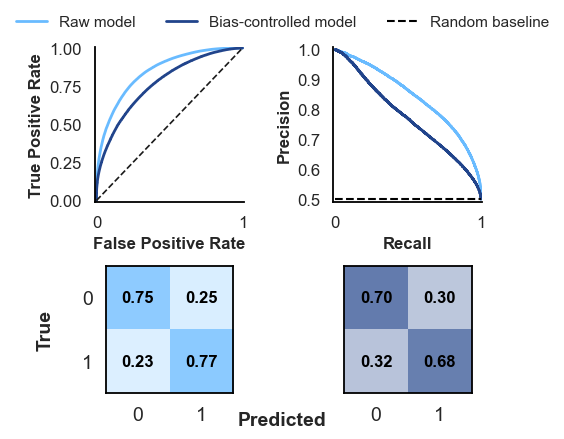

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LinearSegmentedColormap

# === Colors ===
LIGHT_BLUE = "#69BBFF"   # כחול בהיר
DARK_BLUE  = "#21448B"   # כחול כהה

# Colormaps: White -> Blue shade
cmap_light = LinearSegmentedColormap.from_list("white_to_lightblue", ["#FFFFFF", LIGHT_BLUE])
cmap_dark  = LinearSegmentedColormap.from_list("white_to_darkblue",  ["#FFFFFF", DARK_BLUE])

# === Setup ===
sns.set_context("notebook", font_scale=1.3)
sns.set_style("white")
fig = plt.figure(figsize=(5, 4.5))
gs = GridSpec(2, 2, height_ratios=[1.1, 0.9], hspace=0.45, wspace=0.6)

# === ROC & PR Curves (Top Row) ===
roc1 = pd.read_csv('figures/roc_curve_bmax_asym.csv')
metrics1 = pd.read_csv('figures/curve_bmax_asym_metrics.csv')
roc2 = pd.read_csv('figures/roc_curve_b3000_sym.csv')
metrics2 = pd.read_csv('figures/roc_curve_b3000_sym_metrics.csv')  # ← תוקן

pr1 = pd.read_csv('figures/pr_curve_bmax_asym.csv')
pr2 = pd.read_csv('figures/pr_curve_b3000_sym.csv')

# ROC Curve
ax_roc = fig.add_subplot(gs[0, 0])
ax_roc.plot(roc1['fpr'], roc1['tpr'], label='Raw model', linewidth=2, color=LIGHT_BLUE)
ax_roc.plot(roc2['fpr'], roc2['tpr'], label='Bias-controlled model', linewidth=2, color=DARK_BLUE)
ax_roc.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Random classifier')
ax_roc.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax_roc.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax_roc.set_xlim([-0.01, 1.01])
ax_roc.set_ylim([-0.01, 1.01])
# הסרת ספיינים רק בעקומות
for side in ['top', 'right']:
    ax_roc.spines[side].set_visible(False)
for side in ['left', 'bottom']:
    ax_roc.spines[side].set_color('black')
    ax_roc.spines[side].set_linewidth(1.3)

# PR Curve
ax_pr = fig.add_subplot(gs[0, 1])
ax_pr.plot(pr1['recall'], pr1['precision'], label='Raw model', linewidth=2, color=LIGHT_BLUE)
ax_pr.plot(pr2['recall'], pr2['precision'], label='Bias-controlled model', linewidth=2, color=DARK_BLUE)
ax_pr.hlines(y=0.5, xmin=0, xmax=1, colors='black', linestyles='--', label='Random baseline')
ax_pr.set_xlabel('Recall', fontsize=12, fontweight='bold')
ax_pr.set_ylabel('Precision', fontsize=12, fontweight='bold')
ax_pr.set_xlim([-0.01, 1.01])
ax_pr.set_ylim([0.49, 1.01])
# הסרת ספיינים רק בעקומות
for side in ['top', 'right']:
    ax_pr.spines[side].set_visible(False)
for side in ['left', 'bottom']:
    ax_pr.spines[side].set_color('black')
    ax_pr.spines[side].set_linewidth(1.3)

ax_roc.set_yticks([0.0, 0.25, 0.5, 0.75, 1.0])
ax_pr.set_yticks([0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
ax_roc.tick_params(axis='both', labelsize=12)
ax_pr.tick_params(axis='both', labelsize=12)

# === Confusion Matrices (Bottom Row) ===
specs = [
    {'path': 'figures/confusion_bmax_asym_metrics.csv', 'cmap': cmap_light, 'label': 'Raw model'},
    {'path': 'figures/confusion_b3000_sym_metrics.csv', 'cmap': cmap_dark,  'label': 'Bias-controlled model'},
]

for i, spec in enumerate(specs):
    ax = fig.add_subplot(gs[1, i])
    df = pd.read_csv(spec['path'])
    y_true, y_pred = df['y_true'], df['y_pred']
    cm = confusion_matrix(y_true, y_pred, normalize='true')

    # Heatmap: white -> model's blue shade
    ax.imshow(cm, vmin=0, vmax=1, cmap=spec['cmap'], extent=[-0.5, 1.5, 1.5, -0.5], aspect='equal')

    # Numeric labels – תמיד שחור
    for row in range(2):
        for col in range(2):
            val = cm[row, col]
            ax.text(col, row, f"{val:.2f}", ha='center', va='center',
                    fontsize=12, fontweight='bold', color='black')

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['0', '1'], fontsize=14)
    ax.set_yticks([0, 1])

    if i == 0:
        ax.set_yticklabels(['0', '1'], fontsize=14)
        ax.set_ylabel("True", fontsize=14, fontweight='bold')
        ax.yaxis.set_label_coords(-0.4, 0.5)
    else:
        ax.set_yticklabels([])
        ax.set_ylabel("")

    # במטריצות לא מסירים ספיינים
    for side in ['top', 'right', 'left', 'bottom']:
        ax.spines[side].set_visible(True)
        ax.spines[side].set_color('black')
        ax.spines[side].set_linewidth(1.3)

# === Centered "Predicted" Label ===
fig.text(0.5, 0.05, 'Predicted', ha='center', va='center', fontsize=14, fontweight='bold')

# === Legend (for curves) ===
handles, labels = ax_pr.get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 0.98),
    ncol=3,
    frameon=False,
    fontsize=11
)

# === Final Layout ===
plt.tight_layout()
fig.savefig('figures/combined_curves_and_confusion.png', dpi=300, bbox_inches='tight', transparent=False)
plt.show()


In [27]:
# handle colors
import pandas as pd
import json
import itertools

def build_subject_colors_for_file(csv_path, hc_colors, epi_colors, group_col='group', subj_col='subject'):
    df = pd.read_csv(csv_path)
    df[group_col] = df[group_col].replace({'HC':'Healthy', 'EPI':'Epilepsy'})
    hc_subjects = df[df[group_col]=='Healthy'][subj_col].unique()   # שמר על סדר הופעה
    epi_subjects = df[df[group_col]=='Epilepsy'][subj_col].unique()

    hc_cycle  = itertools.cycle(hc_colors)
    epi_cycle = itertools.cycle(epi_colors)

    out = {}
    for s in hc_subjects:
        if s not in out:
            out[s] = next(hc_cycle)
    for s in epi_subjects:
        if s not in out:
            out[s] = next(epi_cycle)
    return out

# ===== פלטות V1 (כמו בקוד שלך) =====
V1_HC = ['#E6F5A9','#D7F29B','#C8EF8D','#B6E67E','#A3DC71','#92D464','#7FCB58','#6FC34E','#60BA44','#52B23B']
V1_EPI = ['#D6ECFF','#C6E5FF','#B6DEFF','#A7D7FF','#97D0FF','#88C9FF','#78C2FF','#69BBFF','#59B4FF','#4AACFF']

# ===== פלטות V2 (כמו בקוד שלך) =====
V2_HC  = ['#4AAE35','#439F2F','#3C9129','#358323','#2F761E','#286819','#225B15','#1B4E11','#15420E','#0E350A','#082806']
V2_EPI = ['#3F8AE6','#397CD4','#336EC2','#2D60AF','#27529D','#21448B','#1B3779','#152966','#0F1B54','#0A1242','#050A31']

colors_V1 = build_subject_colors_for_file('figures/V1.csv', hc_colors=V1_HC, epi_colors=V1_EPI)
colors_V2 = build_subject_colors_for_file('figures/V2.csv', hc_colors=V2_HC,  epi_colors=V2_EPI)

# איחוד המילונים. אם במקרה אותו נבדק הופיע גם ב-V1 וגם ב-V2 (אמרת שחצי/חצי, אז כנראה שלא),
# ניתן להחליט מי גובר. כאן נותנים עדיפות לצבעים מ-V1:
subject_colors = {**colors_V2, **colors_V1}   # V1 overwrite V2 אם יש התנגשות

# שמירה ל-JSON לשימוש עתידי
with open('subject_colors.json', 'w') as f:
    json.dump(subject_colors, f, indent=2)


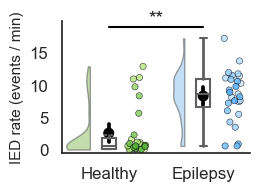

In [127]:
import seaborn as sns
import matplotlib.pyplot as plt
import ptitprince as pt
from scipy.stats import ttest_ind

# סגנון
sns.set_context("notebook", font_scale=1.1)
sns.set_style("white")

# קריאת הנתונים
df = pd.read_csv('figures/V1.csv')
df['group'] = df['group'].replace({'HC': 'Healthy', 'EPI': 'Epilepsy'})

# הכנת הנתונים - לא צריך melt כי הנתונים כבר בפורמט הנכון
data_subset = df.copy()

# סדר הקבוצות
group_order = ['Healthy', 'Epilepsy']

# ציור
fig, ax = plt.subplots(figsize=(2.8, 2.1))  # רוחב קטן יותר לשתי קבוצות

# Raincloud (without individual points)
pt.RainCloud(
    x='group',
    y='Spikes_per_min',
    data=data_subset,
    order=group_order,
    palette=['#9CD46A', '#90CCFF'],  # HC = orange, EPI = blue
    bw=.3,
    width_viol=.5,
    ax=ax,
    orient='v',
    move=0.2,
    alpha=0.6,
    pointplot=False,
    box_showfliers=False,
    point_size=0,  # This removes the individual points from RainCloud
)

import json
with open('subject_colors.json', 'r') as f:
    subject_colors = json.load(f)

# חשוב: לקבע גם את סדר רמות ה-hue כדי ש-seaborn לא ינסה לסדר לבד
hue_order = sorted(data_subset['subject'].unique(), key=list(subject_colors.keys()).index)

# Add individual points colored by subject (positioned to the right)
sns.stripplot(
    data=data_subset,
    x='group',
    y='Spikes_per_min',
    hue='subject',
    order=group_order,
    palette=subject_colors,
    hue_order=hue_order,
    ax=ax,
    size=4.5,
    alpha=0.8,
    jitter=0.1,
    edgecolor="black", 
    linewidth=0.4
)

# Get all collections created by stripplot (one for each subject)
stripplot_collections = ax.collections[2:]  # Skip the first 2 collections (violin and box)

# Move all points to the right of boxplots
for collection in stripplot_collections:
    if collection.get_offsets().size > 0:  # Check if collection has points
        offsets = collection.get_offsets()
        # Move points to the right: add 0.3 to all x-coordinates
        offsets[:, 0] = offsets[:, 0] + 0.3
        collection.set_offsets(offsets)

# Remove the legend (too many subjects for a useful legend)
ax.get_legend().remove()

# ממוצעים
sns.pointplot(
    data=data_subset,
    x='group',
    y='Spikes_per_min',
    order=group_order,
    color='black',
    join=False,
    markers='o',
    errorbar=None,
    scale=0.9,
    ax=ax
)

# סטטיסטיקה - השוואה בין HC ל-EPI
vals1 = data_subset[data_subset['group'] == 'Healthy']['Spikes_per_min']
vals2 = data_subset[data_subset['group'] == 'Epilepsy']['Spikes_per_min']
# stat, pval = ttest_ind(vals1, vals2, equal_var=False)

# ציור כוכביות
y_max = data_subset['Spikes_per_min'].max()
y_line = y_max * 1.1  # גובה הקו
y_star = y_max * 1.1  # גובה הכוכבית

# ציור הקו והכוכבית
star = '**'
ax.plot([0, 1], [y_line, y_line], color='black', linewidth=1.5)
ax.text(0.5, y_star, star, ha='center', va='bottom', fontsize=14)

# עיצוב
ax.set_ylabel("IED rate (events / min)", fontsize=11)
ax.set_xlabel("")
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(bottom=-0.5)
ax.set_yticks([0, 5, 10, 15])

plt.tight_layout()
#fig.savefig("figures/V1_green.png", dpi=300, bbox_inches='tight', transparent=False)
plt.show()

In [128]:
import numpy as np
from scipy.stats import ttest_ind

# --- t-test על ממוצעי נבדק (Healthy vs Epilepsy) ---
per_subj = data_subset.groupby(['group','subject'], as_index=False)['Spikes_per_min'].mean()

g_healthy  = per_subj.loc[per_subj['group']=='Healthy',  'Spikes_per_min'].to_numpy()
g_epilepsy = per_subj.loc[per_subj['group']=='Epilepsy', 'Spikes_per_min'].to_numpy()

if g_healthy.size < 2 or g_epilepsy.size < 2:
    print(f"לא ניתן להריץ t-test אמין: Healthy={g_healthy.size}, Epilepsy={g_epilepsy.size}")
else:
    # Welch t-test
    t_stat, pval = ttest_ind(g_healthy, g_epilepsy, equal_var=False)

    # דרגות חופש של Welch (להדפסה בלבד)
    def welch_df(x, y):
        nx, ny = len(x), len(y)
        vx, vy = np.var(x, ddof=1)/nx, np.var(y, ddof=1)/ny
        return (vx + vy)**2 / ((vx**2)/(nx-1) + (vy**2)/(ny-1))

    df_w = welch_df(g_healthy, g_epilepsy)

    print("Welch t-test on per-subject means (Healthy vs Epilepsy)")
    print(f"n_Healthy={g_healthy.size}, n_Epilepsy={g_epilepsy.size}")
    print(f"t={t_stat:.3f}, df≈{df_w:.1f}, p={pval:.4g}")
    print(f"mean±SD: Healthy={np.mean(g_healthy):.2f}±{np.std(g_healthy, ddof=1):.2f}, "
          f"Epilepsy={np.mean(g_epilepsy):.2f}±{np.std(g_epilepsy, ddof=1):.2f}")


Welch t-test on per-subject means (Healthy vs Epilepsy)
n_Healthy=10, n_Epilepsy=10
t=-3.194, df≈18.0, p=0.005031
mean±SD: Healthy=2.76±3.90, Epilepsy=8.25±3.78


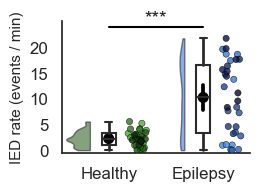

In [125]:
import seaborn as sns
import matplotlib.pyplot as plt
import ptitprince as pt
from scipy.stats import ttest_ind
import json

# סגנון
sns.set_context("notebook", font_scale=1.1)
sns.set_style("white")

# קריאת הנתונים
df = pd.read_csv('figures/V2.csv')
df['group'] = df['group'].replace({'HC': 'Healthy', 'EPI': 'Epilepsy'})

# הכנת הנתונים - לא צריך melt כי הנתונים כבר בפורמט הנכון
data_subset = df.copy()

# סדר הקבוצות
group_order = ['Healthy', 'Epilepsy']

# ציור
fig, ax = plt.subplots(figsize=(2.8, 2.1)) 

# Raincloud (without individual points)
pt.RainCloud(
    x='group',
    y='Spikes_per_min',
    data=data_subset,
    order=group_order,
    palette=['#2E6F20', '#1E6EFF'],  # HC = green, EPI = blue
    bw=.3,
    width_viol=.5,
    ax=ax,
    orient='v',
    move=0.2,
    alpha=0.6,
    pointplot=False,
    box_showfliers=False,
    point_size=0,  # This removes the individual points from RainCloud
)

with open('subject_colors.json', 'r') as f:
    subject_colors = json.load(f)

# חשוב: לקבע גם את סדר רמות ה-hue כדי ש-seaborn לא ינסה לסדר לבד
hue_order = sorted(data_subset['subject'].unique(), key=list(subject_colors.keys()).index)

# Add individual points colored by subject (positioned to the right)
sns.stripplot(
    data=data_subset,
    x='group',
    y='Spikes_per_min',
    hue='subject',
    order=group_order,
    hue_order=hue_order,
    palette=subject_colors, 
    ax=ax,
    size=4.5,
    alpha=0.8,
    jitter=0.1,
    edgecolor="black", 
    linewidth=0.4
)

# Get all collections created by stripplot (one for each subject)
stripplot_collections = ax.collections[2:]  # Skip the first 2 collections (violin and box)

# Move all points to the right of boxplots
for collection in stripplot_collections:
    if collection.get_offsets().size > 0:  # Check if collection has points
        offsets = collection.get_offsets()
        # Move points to the right: add 0.3 to all x-coordinates
        offsets[:, 0] = offsets[:, 0] + 0.3
        collection.set_offsets(offsets)

# Remove the legend (too many subjects for a useful legend)
ax.get_legend().remove()

# ממוצעים
sns.pointplot(
    data=data_subset,
    x='group',
    y='Spikes_per_min',
    order=group_order,
    color='black',
    join=False,
    markers='o',
    errorbar=None,
    scale=0.9,
    ax=ax
)

# סטטיסטיקה - השוואה בין HC ל-EPI
vals1 = data_subset[data_subset['group'] == 'Healthy']['Spikes_per_min']
vals2 = data_subset[data_subset['group'] == 'Epilepsy']['Spikes_per_min']
stat, pval = ttest_ind(vals1, vals2, equal_var=False)

# ציור כוכביות
y_max = data_subset['Spikes_per_min'].max()
y_line = y_max * 1.1  # גובה הקו
y_star = y_max * 1.1  # גובה הכוכבית

if pval < 0.001:
    star = '***'
elif pval < 0.01:
    star = '**'
elif pval < 0.05:
    star = '*'
else:
    star = 'ns'  # לא מובהק

# ציור הקו והכוכבית
if star != 'ns':
    ax.plot([0, 1], [y_line, y_line], color='black', linewidth=1.5)
    ax.text(0.5, y_star, star, ha='center', va='bottom', fontsize=14)

# עיצוב
ax.set_ylabel("IED rate (events / min)", fontsize=11)
ax.set_xlabel("")
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(-0.5)
# set y ticks
ax.set_yticks([0, 5, 10, 15, 20])

plt.tight_layout()
#fig.savefig("figures/V2_green.png", dpi=300, bbox_inches='tight', transparent=False)
plt.show()

In [126]:
import numpy as np
from scipy.stats import ttest_ind

# --- t-test על ממוצעי נבדק (Healthy vs Epilepsy) ---
per_subj = data_subset.groupby(['group','subject'], as_index=False)['Spikes_per_min'].mean()

g_healthy   = per_subj.loc[per_subj['group']=='Healthy',  'Spikes_per_min'].to_numpy()
g_epilepsy  = per_subj.loc[per_subj['group']=='Epilepsy', 'Spikes_per_min'].to_numpy()

if len(g_healthy) < 2 or len(g_epilepsy) < 2:
    print(f"לא ניתן להריץ t-test אמין: Healthy={len(g_healthy)}, Epilepsy={len(g_epilepsy)}")
else:
    t_stat, pval = ttest_ind(g_healthy, g_epilepsy, equal_var=False)  # Welch t-test

    # דרגות חופש של Welch (להדפסה)
    def welch_df(x, y):
        nx, ny = len(x), len(y)
        vx, vy = np.var(x, ddof=1)/nx, np.var(y, ddof=1)/ny
        return (vx + vy)**2 / ((vx**2)/(nx-1) + (vy**2)/(ny-1))

    df_w = welch_df(g_healthy, g_epilepsy)

    print("Welch t-test on per-subject means (Healthy vs Epilepsy)")
    print(f"n_Healthy={len(g_healthy)}, n_Epilepsy={len(g_epilepsy)}")
    print(f"t={t_stat:.3f}, df≈{df_w:.1f}, p={pval:.4g}")
    print(f"mean±SD: Healthy={np.mean(g_healthy):.2f}±{np.std(g_healthy, ddof=1):.2f}, "
          f"Epilepsy={np.mean(g_epilepsy):.2f}±{np.std(g_epilepsy, ddof=1):.2f}")


Welch t-test on per-subject means (Healthy vs Epilepsy)
n_Healthy=11, n_Epilepsy=11
t=-3.739, df≈10.7, p=0.003438
mean±SD: Healthy=2.20±1.33, Epilepsy=10.41±7.16


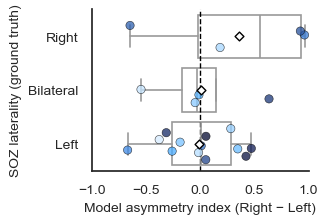

In [39]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import json

# --- טוענים נתונים + צבעים קבועים ---
df = pd.read_csv('figures/laterality.csv')  # חשוב שתהיה עמודה 'subject'
with open('subject_colors.json', 'r') as f:
    subject_colors = json.load(f)

DEFAULT_COLOR = "#BFBFBF"

# נבדקים בגרף
subjects_in_plot = df['subject'].unique()

# בונים מילון צבעים לגרף + הדפסות אם חסרים
palette_for_plot = {}
for s in subjects_in_plot:
    if s in subject_colors:
        palette_for_plot[s] = subject_colors[s]
    else:
        print(f"⚠️ נבדק {s} לא נמצא ב-subject_colors.json – ניתן לו צבע ברירת מחדל ({DEFAULT_COLOR})")
        palette_for_plot[s] = DEFAULT_COLOR

# hue_order יציב: קודם לפי סדר subject_colors, אחר כך מי שלא נמצא
known_order = [s for s in subject_colors.keys() if s in subjects_in_plot]
unknown_order = [s for s in subjects_in_plot if s not in subject_colors]
hue_order = known_order + unknown_order

# --- ציור ---
categories = ['Right', 'Bilateral', 'Left']
plt.figure(figsize=(2.8, 2.1))

sns.boxplot(
    data=df,
    y='Zone Category', x='Asymmetry Index',
    order=categories,
    color='white', linewidth=1.2, showcaps=True, fliersize=0
)

sns.stripplot(
    data=df,
    y='Zone Category', x='Asymmetry Index',
    order=categories,
    hue='subject',
    hue_order=hue_order,
    palette=palette_for_plot,
    alpha=0.75, size=6, jitter=0.3, dodge=False,
    edgecolor='black', linewidth=0.4
)

# ממוצעים (יהלומים לבנים)
group_means = df.groupby('Zone Category')['Asymmetry Index'].mean()
for i, category in enumerate(categories):
    mean_x = group_means.get(category, float('nan'))
    plt.scatter(mean_x, i, color='white', edgecolor='black', marker='D', s=20, zorder=5)

plt.axvline(0, color='black', linestyle='--', linewidth=1)

plt.xlabel('Model asymmetry index (Right − Left)', fontsize=10)
plt.ylabel('SOZ laterality (ground truth)', fontsize=10)
plt.xlim(-1, 1)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend([],[], frameon=False)
plt.grid(False)
sns.despine(top=True, right=True)
#save
plt.tight_layout()
plt.savefig('figures/laterality_colored.png', dpi=300, bbox_inches='tight', transparent=False)

plt.show()


C:\Users\user\AppData\Local\Temp\ipykernel_10800\884807171.py:76: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


Kruskal-Wallis: H=1.363, p=0.5058
Right vs Bilateral: p_raw=0.4857, p_holm=0.9714 (ns)
Right vs Left: p_raw=0.2958, p_holm=0.8874 (ns)
Bilateral vs Left: p_raw=0.9563, p_holm=0.9714 (ns)


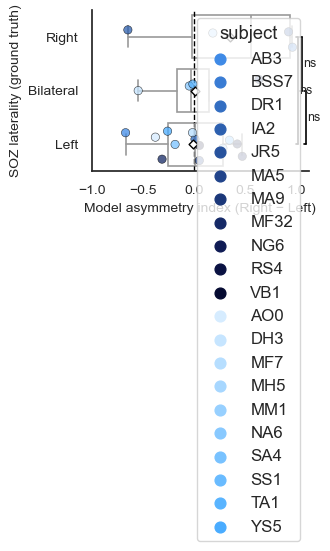

In [43]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import itertools
from scipy.stats import kruskal, mannwhitneyu
import json

# --- טוענים נתונים + צבעים קבועים ---
df = pd.read_csv('figures/laterality.csv')  # חייב לכלול: subject, Zone Category, Asymmetry Index
df['subject'] = df['subject'].astype(str).str.strip()

with open('subject_colors.json', 'r') as f:
    subject_colors = json.load(f)

DEFAULT_COLOR = "#BFBFBF"

# נבדקים בגרף
subjects_in_plot = df['subject'].unique()

# בונים מילון צבעים לגרף + הדפסות אם חסרים
palette_for_plot = {}
for s in subjects_in_plot:
    if s in subject_colors:
        palette_for_plot[s] = subject_colors[s]
    else:
        print(f"⚠️ נבדק {s} לא נמצא ב-subject_colors.json – ניתן לו צבע ברירת מחדל ({DEFAULT_COLOR})")
        palette_for_plot[s] = DEFAULT_COLOR

# hue_order יציב: קודם לפי סדר subject_colors, אחר כך מי שלא נמצא
known_order = [s for s in subject_colors.keys() if s in subjects_in_plot]
unknown_order = [s for s in subjects_in_plot if s not in subject_colors]
hue_order = known_order + unknown_order

# --- ציור ---
categories = ['Right', 'Bilateral', 'Left']
plt.figure(figsize=(2.8, 2.1))

ax = plt.gca()

sns.boxplot(
    data=df,
    y='Zone Category', x='Asymmetry Index',
    order=categories,
    color='white', linewidth=1.2, showcaps=True, fliersize=0,
    ax=ax
)

sns.stripplot(
    data=df,
    y='Zone Category', x='Asymmetry Index',
    order=categories,
    hue='subject',
    hue_order=hue_order,
    palette=palette_for_plot,
    alpha=0.75, size=6, jitter=0.3, dodge=False,
    edgecolor='black', linewidth=0.4,
    ax=ax
)

# ממוצעים (יהלומים לבנים)
group_means = df.groupby('Zone Category')['Asymmetry Index'].mean()
for i, category in enumerate(categories):
    mean_x = group_means.get(category, float('nan'))
    ax.scatter(mean_x, i, color='white', edgecolor='black', marker='D', s=20, zorder=5)

# קו אנכי ב-x=0
ax.axvline(0, color='black', linestyle='--', linewidth=1)

# עיצוב
ax.set_xlabel('Model asymmetry index (Right − Left)', fontsize=10)
ax.set_ylabel('SOZ laterality (ground truth)', fontsize=10)
ax.set_xlim(-1, 1.12)  # מרחב קטן מימין לסוגריים של הסיג'
ax.tick_params(labelsize=10)
ax.grid(False)
sns.despine(top=True, right=True)
plt.tight_layout()

# ======================
# סטטיסטיקה בין הקבוצות
# ======================
def p_to_stars(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'

# ערכים לכל קבוצה
vals = {cat: df.loc[df['Zone Category'] == cat, 'Asymmetry Index'].dropna().values
        for cat in categories}

# Kruskal-Wallis כולל (מדפיס לקונסול)
non_empty_groups = [v for v in vals.values() if len(v) > 0]
if len(non_empty_groups) >= 2:
    try:
        H, p_kw = kruskal(*non_empty_groups)
        print(f"Kruskal-Wallis: H={H:.3f}, p={p_kw:.4g}")
    except Exception as e:
        print(f"בעיה בחישוב Kruskal-Wallis: {e}")
else:
    print("לא ניתן לחשב Kruskal-Wallis: פחות משתי קבוצות עם נתונים.")

# השוואות זוגיות (Mann-Whitney) + תיקון Holm-Bonferroni
pairs = [(a,b) for a,b in itertools.combinations(categories, 2)
         if len(vals[a]) > 0 and len(vals[b]) > 0]

raw_p = {}
for a, b in pairs:
    try:
        stat, p = mannwhitneyu(vals[a], vals[b], alternative='two-sided')
        raw_p[(a,b)] = p
    except Exception as e:
        print(f"לא ניתן לחשב Mann-Whitney עבור {a} vs {b}: {e}")

# תיקון Holm-Bonferroni
def holm_bonferroni(pdict):
    if not pdict:
        return {}
    items = sorted(pdict.items(), key=lambda kv: kv[1])  # לפי p קטן→גדול
    m = len(items)
    adj_vals = []
    max_so_far = 0.0
    for i, ((a,b), p) in enumerate(items):
        adj = min(1.0, (m - i) * p)
        # הבטחת מונוטוניות לא יורדת (step-down)
        adj = max(adj, max_so_far)
        max_so_far = adj
        adj_vals.append(((a,b), adj))
    # החזרה למילון
    return {pair: adj for pair, adj in adj_vals}

adj_p = holm_bonferroni(raw_p)

# הדפס לטקסט
for (a,b) in pairs:
    rp = raw_p.get((a,b), None)
    ap = adj_p.get((a,b), None)
    if rp is not None and ap is not None:
        print(f"{a} vs {b}: p_raw={rp:.4g}, p_holm={ap:.4g} ({p_to_stars(ap)})")

# ======================
# אנוטציות על הגרף (סוגריים ואסטריסקים)
# ======================
def draw_h_bracket(ax, y1, y2, x, text, tick=0.02, lw=1.2, fs=9):
    """y1,y2 הם אינדקסים של הקטגוריות (0=Right,1=Bilateral,2=Left); x הוא מקום הסוגריים על ציר ה-x"""
    # שני קווים קטנים אופקיים + קו מחבר אנכי
    ax.plot([x - tick, x], [y1, y1], color='black', lw=lw)
    ax.plot([x - tick, x], [y2, y2], color='black', lw=lw)
    ax.plot([x, x], [y1, y2], color='black', lw=lw)
    # טקסט מעט מימין
    ax.text(x + 0.005, (y1 + y2) / 2, text, va='center', ha='left', fontsize=fs)

# נציב את שלוש ההשוואות בעמודה מימין, כל אחת ב-x מעט שונה כדי שלא יעלו זו על זו
x_positions = [1.02, 1.06, 1.10]  # ניתן לכוונן לפי צפיפות
pairs_for_annot = [('Right','Left'), ('Right','Bilateral'), ('Bilateral','Left')]

for (pair, x) in zip(pairs_for_annot, x_positions):
    a, b = pair
    if (a,b) in adj_p:
        y1 = categories.index(a)
        y2 = categories.index(b)
        draw_h_bracket(ax, y1, y2, x, p_to_stars(adj_p[(a,b)]))

# שמירה
# plt.savefig('figures/laterality_colored.png', dpi=300, bbox_inches='tight', transparent=False)
plt.show()


In [44]:
raw_p

{('Right', 'Bilateral'): 0.4857142857142857,
 ('Right', 'Left'): 0.2957983193277311,
 ('Bilateral', 'Left'): 0.9563025210084034}

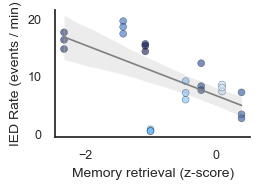

In [129]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import json

# --- קריאת נתונים ---
spikes_df = pd.read_csv('figures/V1_V2_combined.csv')   # כולל 'subject', 'Spikes_per_min', 'part'
cog_df    = pd.read_csv('figures/EPI_Corr.csv', encoding='cp1255')

# ודא שהמזהים נקיים
spikes_df['subject'] = spikes_df['subject'].astype(str).str.strip()
cog_df['subject']    = cog_df['subject'].astype(str).str.strip()

# חיבור הקבצים
var = 'יעילות שליפת המידע'
merged_df = pd.merge(
    spikes_df,
    cog_df[['subject', var]],
    on='subject',
    how='inner'
)

# --- טעינת צבעים קבועים ---
with open('subject_colors.json', 'r') as f:
    subject_colors = json.load(f)

DEFAULT_COLOR = "#BFBFBF"  # צבע ברירת מחדל לנבדקים שלא במילון

# בנה פלטה לגרף והדפס אזהרות על חסרים
subjects_in_plot = merged_df['subject'].unique()
palette_for_plot = {}
for s in subjects_in_plot:
    if s in subject_colors:
        palette_for_plot[s] = subject_colors[s]
    else:
        print(f"⚠️ נבדק {s} לא נמצא ב-subject_colors.json – ניתן לו צבע ברירת מחדל ({DEFAULT_COLOR})")
        palette_for_plot[s] = DEFAULT_COLOR

# סדר עקבי של hue: קודם לפי סדר המילון הראשי, אחר כך הלא־מוכרים
known_order   = [s for s in subject_colors.keys() if s in subjects_in_plot]
unknown_order = [s for s in subjects_in_plot if s not in subject_colors]
hue_order = known_order + unknown_order

# --- ציור ---
plt.figure(figsize=(2.8, 2.1))

# נקודות צבועות לפי subject
sns.scatterplot(
    data=merged_df,
    x=var, y='Spikes_per_min',
    hue='subject',
    hue_order=hue_order,
    palette=palette_for_plot,
    s=25, alpha=0.6,
    edgecolor='black', linewidth=0.3,
    legend=False  # בד"כ יש יותר מדי נבדקים למקרא שימושי
)

# קו רגרסיה (ללא נקודות)
sns.regplot(
    data=merged_df,
    x=var, y='Spikes_per_min',
    scatter=False,
    line_kws={'color': 'gray', 'linewidth': 1.2}
)

# עיצוב
plt.xlabel('Memory retrieval (z-score)', fontsize=10)
plt.ylabel('IED Rate (events / min)', fontsize=10)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
sns.despine(top=True, right=True)
plt.tight_layout()

# שמירה (אופציונלי)
# plt.savefig('figures/epi_corr_colored.png', dpi=300, bbox_inches='tight', transparent=False)

plt.show()


HC: W=0.8795, p=0.0118
MCI: W=0.9593, p=0.5017
AD: W=0.9207, p=0.4355
HC vs MCI p-value: 8.567860993385093e-09
MCI vs AD p-value: 0.044505578851617086
HC vs AD p-value: 0.0006098417240968315


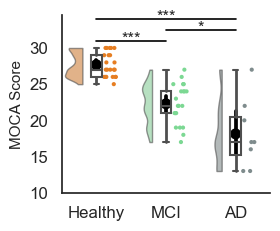

In [59]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import ptitprince as pt
from scipy.stats import ttest_ind

# Load data (contains 'subject', 'group', 'MOCA')
df = pd.read_csv('figures/MCI_corr_final.csv')  # Update with your actual file path
# filter moca > 10
df = df[df['MOCA'] > 10]
# Define group order and palette
group_order = ['HC', 'MCI', 'AD']
group_palette = {'HC': '#e67e22', 'MCI': '#7cd893', 'AD': '#7f8c8d'}

# Plot setup
fig, ax = plt.subplots(figsize=(3, 2.5))

# RainCloud plot (violin + box without fliers, no individual points)
pt.RainCloud(
    x='group',
    y='MOCA',
    data=df,
    order=group_order,
    palette=[group_palette['HC'], group_palette['MCI'], group_palette['AD']],
    bw=.3,
    width_viol=.5,
    ax=ax,
    orient='v',
    move=0.2,
    alpha=0.6,
    pointplot=False,
    box_showfliers=False,
    # point_size=0
)


# Plot group means (black dots)
sns.pointplot(
    data=df,
    x='group',
    y='MOCA',
    order=group_order,
    color='black',
    join=False,
    markers='o',
    errorbar=None,
    scale=0.9,
    ax=ax
)

# --- Statistical comparisons (t-tests between group pairs) ---
hc_vals = df[df['group'] == 'HC']['MOCA']
mci_vals = df[df['group'] == 'MCI']['MOCA']
ad_vals = df[df['group'] == 'AD']['MOCA']

from scipy.stats import shapiro

# בדיקת נורמליות עבור כל קבוצה
for group_name in ['HC', 'MCI', 'AD']:
    stat, p = shapiro(df[df['group'] == group_name]['MOCA'])
    print(f"{group_name}: W={stat:.4f}, p={p:.4f}")

# T-tests
_, pval_HC_MCI = ttest_ind(hc_vals, mci_vals, equal_var=False)
_, pval_MCI_AD = ttest_ind(mci_vals, ad_vals, equal_var=False)
_, pval_HC_AD = ttest_ind(hc_vals, ad_vals, equal_var=False)

# Print p-values for debugging
print(f"HC vs MCI p-value: {pval_HC_MCI}")
print(f"MCI vs AD p-value: {pval_MCI_AD}")
print(f"HC vs AD p-value: {pval_HC_AD}")
# Function for significance stars
def significance_star(pval):
    if pval < 0.001:
        return '***'
    elif pval < 0.01:
        return '**'
    elif pval < 0.05:
        return '*'
    else:
        return 'ns'

# Draw significance lines and stars
y_max = df['MOCA'].max()
offsets = [1, 2.5, 4]  # Vertical offsets for the comparisons
comparisons = [((0, 1), pval_HC_MCI), ((1, 2), pval_MCI_AD), ((0, 2), pval_HC_AD)]

for (x1, x2), pval in comparisons:
    star = significance_star(pval)
    y_line = y_max + offsets.pop(0)
    if star != 'ns':
        ax.plot([x1, x2], [y_line, y_line], color='black', linewidth=1.2)
        ax.text((x1 + x2)/2, y_line-0.8, star, ha='center', va='bottom', fontsize=12)

# Axes styling
ax.set_ylabel("MOCA Score", fontsize=11)
ax.set_xlabel("")
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(10, 34.5)
ax.set_xticklabels(['Healthy', 'MCI', 'AD'])

plt.tight_layout()
# fig.savefig("figures/MCI_moca_box.png", dpi=300, bbox_inches='tight', transparent=False)
plt.show()


In [133]:
# show only rows without NaN
merged_df.subject[~merged_df['יעילות שליפת המידע'].isna()].unique()

array(['DH3', 'SA4', 'SS1', 'DR1', 'JR5', 'MA5', 'MF32', 'NG6'],
      dtype=object)

One-way ANOVA (Young vs HC vs MCI vs AD) on per-subject means: F=19.788, p=2.148e-09


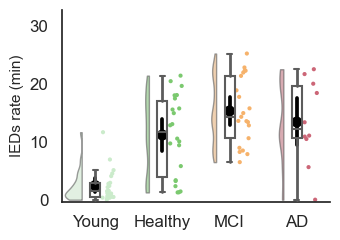

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt
import ptitprince as pt
from scipy.stats import f_oneway
import pandas as pd
import numpy as np

# Styling
sns.set_context("notebook", font_scale=1.1)
sns.set_style("white")

# ----- קבוצה מקורית: HC / MCI / AD -----
df = pd.read_csv('figures/MCI_rates_final.csv')  # מצופה: group, subject, Spikes_per_min
data_subset = df.copy()
data_subset['group'] = data_subset['group'].astype(str).str.strip()
data_subset['subject'] = data_subset['subject'].astype(str).str.strip()

# ממוצע פר-נבדק לכל קבוצה קיימת
data_subset_mean = data_subset.groupby(['group', 'subject'], as_index=False)['Spikes_per_min'].mean()

# ----- קבוצה חדשה: Young (נלקח מ-HC מתוך V1_V2_combined.csv) -----
spikes_df = pd.read_csv('figures/V1_V2_combined.csv')  # מצופה: subject, Spikes_per_min, part, group(=HC/...)
spikes_df['group'] = spikes_df['group'].astype(str).str.strip()
spikes_df['subject'] = spikes_df['subject'].astype(str).str.strip()

young_src = spikes_df[spikes_df['group'] == 'HC'].copy()
young_mean = young_src.groupby('subject', as_index=False)['Spikes_per_min'].mean()
young_mean['group'] = 'Young'  # נגדיר שם קבוצה חדש

# נתוני ממוצע פר-נבדק לכל הקבוצות יחד (Young + HC/MCI/AD)
combined_means = pd.concat(
    [data_subset_mean[['group', 'subject', 'Spikes_per_min']], young_mean[['group', 'subject', 'Spikes_per_min']]],
    ignore_index=True
)

# ----- סדר וקולורים -----
group_order = ['Young', 'HC', 'MCI', 'AD']
palette = ['#CBEBCB', '#7BC96F', '#F6B26B', '#CC6677']  # ירוק בהיר ל-Young, ירוק ל-HC, כתום ל-MCI, בורדו ל-AD

# ----- ANOVA (one-way) על ממוצעי נבדק בארבע הקבוצות -----
groups = [
    combined_means.loc[combined_means['group'] == g, 'Spikes_per_min'].dropna().values
    for g in group_order
]
if any(len(a) == 0 for a in groups):
    print("Cannot run ANOVA: one or more groups are empty.")
else:
    F, p = f_oneway(*groups)
    print(f"One-way ANOVA (Young vs HC vs MCI vs AD) on per-subject means: F={F:.3f}, p={p:.4g}")

# ----- ציור -----
fig, ax = plt.subplots(figsize=(3.6, 2.6))  # מעט רחב יותר ל-4 קבוצות

pt.RainCloud(
    x='group',
    y='Spikes_per_min',
    data=combined_means,
    order=group_order,
    palette=palette,
    bw=.3, width_viol=.5,
    ax=ax, orient='v', move=0.2,
    alpha=0.6, pointplot=False, box_showfliers=False
)

sns.pointplot(
    data=combined_means,
    x='group', y='Spikes_per_min',
    order=group_order,
    color='black', join=False, markers='o',
    errorbar=None, scale=0.9, ax=ax
)

# עיצוב
ax.set_ylabel("IEDs rate (min)", fontsize=11)
ax.set_xlabel("")
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ymax = combined_means['Spikes_per_min'].max()
ax.set_ylim(-0.3, max(29, ymax*1.3))
ax.set_xticklabels(['Young', 'Healthy', 'MCI', 'AD'])

plt.tight_layout()
# plt.savefig("figures/MCI_groups_rates_with_young_ANOVA.png", dpi=300, bbox_inches='tight', transparent=False)
plt.show()


One-way ANOVA (Young vs Elderly vs MCI vs AD) on per-subject means: F=19.788, p=2.148e-09


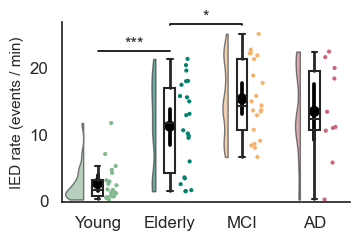

In [91]:
import seaborn as sns
import matplotlib.pyplot as plt
import ptitprince as pt
from scipy.stats import f_oneway
import pandas as pd
import numpy as np

# Styling
sns.set_context("notebook", font_scale=1.1)
sns.set_style("white")

# ----- קבוצה מקורית: HC / MCI / AD -----
df = pd.read_csv('figures/MCI_rates_final.csv')  # מצופה: group, subject, Spikes_per_min
data_subset = df.copy()
data_subset['group'] = data_subset['group'].astype(str).str.strip()
data_subset['subject'] = data_subset['subject'].astype(str).str.strip()

# ממוצע פר-נבדק לכל קבוצה קיימת
data_subset_mean = data_subset.groupby(['group', 'subject'], as_index=False)['Spikes_per_min'].mean()

# ----- קבוצה חדשה: Young (נלקח מ-HC מתוך V1_V2_combined.csv) -----
spikes_df = pd.read_csv('figures/V1_V2_combined.csv')  # מצופה: subject, Spikes_per_min, part, group(=HC/...)
spikes_df['group'] = spikes_df['group'].astype(str).str.strip()
spikes_df['subject'] = spikes_df['subject'].astype(str).str.strip()

young_src = spikes_df[spikes_df['group'] == 'HC'].copy()
young_mean = young_src.groupby('subject', as_index=False)['Spikes_per_min'].mean()
young_mean['group'] = 'Young'  # שם קבוצה חדש

# נתוני ממוצע פר-נבדק לכל הקבוצות יחד (Young + HC/MCI/AD)
combined_means = pd.concat(
    [data_subset_mean[['group', 'subject', 'Spikes_per_min']], young_mean[['group', 'subject', 'Spikes_per_min']]],
    ignore_index=True
)

# שינוי שם HC -> Elderly (לנוחות הצגה)
combined_means['group'] = combined_means['group'].replace({'HC': 'Elderly'})

# ----- סדר וקולורים -----
group_order = ['Young', 'Elderly', 'MCI', 'AD']
palette = ['#81b88e', '#00826e', '#F6B26B', '#CC6677']  # Young=ירוק בהיר, Elderly=זית כהה, MCI=כתום, AD=בורדו

# ----- ANOVA (one-way) על ממוצעי נבדק בארבע הקבוצות -----
groups = [
    combined_means.loc[combined_means['group'] == g, 'Spikes_per_min'].dropna().values
    for g in group_order
]
if any(len(a) == 0 for a in groups):
    print("Cannot run ANOVA: one or more groups are empty.")
else:
    F, p = f_oneway(*groups)
    print(f"One-way ANOVA (Young vs Elderly vs MCI vs AD) on per-subject means: F={F:.3f}, p={p:.4g}")

# ----- ציור -----
fig, ax = plt.subplots(figsize=(3.8, 2.6))  # מעט רחב יותר ל-4 קבוצות

pt.RainCloud(
    x='group',
    y='Spikes_per_min',
    data=combined_means,
    order=group_order,
    palette=palette,
    bw=.3, width_viol=.5,
    ax=ax, orient='v', move=0.2,
    alpha=0.6, pointplot=False, box_showfliers=False
)

sns.pointplot(
    data=combined_means,
    x='group', y='Spikes_per_min',
    order=group_order,
    color='black', join=False, markers='o',
    errorbar=None, scale=0.9, ax=ax
)

# --- כוכביות מבוקשות ---
def add_sig(ax, x1, x2, y, text, h=0.08):
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], color='black', lw=1.2)
    ax.text((x1+x2)/2, y+h*1.05, text, ha='center', va='bottom', fontsize=12)

ymax = combined_means['Spikes_per_min'].max()
base = ymax * 1.05
step = max(0.1, (ymax - (-0.3)) * 0.07)

# *** בין Young (0) ל-Elderly (1)
add_sig(ax, 0, 1, 22.5, '***')
# * בין Elderly (1) ל-MCI (2)
add_sig(ax, 1, 2, 26.5, '*')

# עיצוב
ax.set_ylabel("IED rate (events / min)", fontsize=11)
ax.set_xlabel("")
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_ylim(-0.3, 27)  # מקום לכוכביות
ax.set_xticklabels(['Young', 'Elderly', 'MCI', 'AD'])

plt.tight_layout()
plt.savefig("figures/MCI_groups_rates_with_young_ANOVA_stars.png", dpi=300, bbox_inches='tight', transparent=False)
plt.show()


One-way ANOVA (Young vs Elderly vs MCI vs AD) on per-subject means: F=19.788, p=2.148e-09


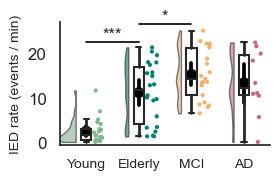

In [118]:
import seaborn as sns
import matplotlib.pyplot as plt
import ptitprince as pt
from scipy.stats import f_oneway
import pandas as pd
import numpy as np

# Styling
sns.set_context("notebook", font_scale=1.1)
sns.set_style("white")

# ----- קבוצה מקורית: HC / MCI / AD -----
df = pd.read_csv('figures/MCI_rates_final.csv')  # מצופה: group, subject, Spikes_per_min
data_subset = df.copy()
data_subset['group'] = data_subset['group'].astype(str).str.strip()
data_subset['subject'] = data_subset['subject'].astype(str).str.strip()

# ממוצע פר-נבדק לכל קבוצה קיימת
data_subset_mean = data_subset.groupby(['group', 'subject'], as_index=False)['Spikes_per_min'].mean()

# ----- קבוצה חדשה: Young (נלקח מ-HC מתוך V1_V2_combined.csv) -----
spikes_df = pd.read_csv('figures/V1_V2_combined.csv')  # מצופה: subject, Spikes_per_min, part, group(=HC/...)
spikes_df['group'] = spikes_df['group'].astype(str).str.strip()
spikes_df['subject'] = spikes_df['subject'].astype(str).str.strip()

young_src = spikes_df[spikes_df['group'] == 'HC'].copy()
young_mean = young_src.groupby('subject', as_index=False)['Spikes_per_min'].mean()
young_mean['group'] = 'Young'  # שם קבוצה חדש

# נתוני ממוצע פר-נבדק לכל הקבוצות יחד (Young + HC/MCI/AD)
combined_means = pd.concat(
    [data_subset_mean[['group', 'subject', 'Spikes_per_min']], young_mean[['group', 'subject', 'Spikes_per_min']]],
    ignore_index=True
)

# שינוי שם HC -> Elderly (לנוחות הצגה)
combined_means['group'] = combined_means['group'].replace({'HC': 'Elderly'})

# ----- סדר וקולורים -----
group_order = ['Young', 'Elderly', 'MCI', 'AD']
palette = ['#81b88e', '#00826e', '#F6B26B', '#CC6677']  # Young=ירוק בהיר, Elderly=זית כהה, MCI=כתום, AD=בורדו

# ----- ANOVA (one-way) על ממוצעי נבדק בארבע הקבוצות -----
groups = [
    combined_means.loc[combined_means['group'] == g, 'Spikes_per_min'].dropna().values
    for g in group_order
]
if any(len(a) == 0 for a in groups):
    print("Cannot run ANOVA: one or more groups are empty.")
else:
    F, p = f_oneway(*groups)
    print(f"One-way ANOVA (Young vs Elderly vs MCI vs AD) on per-subject means: F={F:.3f}, p={p:.4g}")

# ----- ציור -----
fig, ax = plt.subplots(figsize=(3, 2))  # מעט רחב יותר ל-4 קבוצות

pt.RainCloud(
    x='group',
    y='Spikes_per_min',
    data=combined_means,
    order=group_order,
    palette=palette,
    bw=.3, width_viol=.65,
    ax=ax, orient='v', move=0.25,
    alpha=0.6, pointplot=False, box_showfliers=False, width_box=0.2
)

sns.pointplot(
    data=combined_means,
    x='group', y='Spikes_per_min',
    order=group_order,
    color='black', join=False, markers='o',
    errorbar=None, scale=0.9, ax=ax
)

# --- כוכביות מבוקשות ---
def add_sig(ax, x1, x2, y, text, h=0.08):
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], color='black', lw=1.2)
    ax.text((x1+x2)/2, y+h*1.05, text, ha='center', va='bottom', fontsize=12)

ymax = combined_means['Spikes_per_min'].max()
base = ymax * 1.05
step = max(0.1, (ymax - (-0.3)) * 0.07)

# *** בין Young (0) ל-Elderly (1)
add_sig(ax, 0, 1, 22.5, '***')
# * בין Elderly (1) ל-MCI (2)
add_sig(ax, 1, 2, 26.5, '*')

# עיצוב
ax.set_ylabel("IED rate (events / min)", fontsize=10)
ax.set_xlabel("")
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_ylim(-0.6, 27)  # מקום לכוכביות
ax.set_xticklabels(['Young', 'Elderly', 'MCI', 'AD'])
# x font
plt.xticks(fontsize=10)

plt.tight_layout()
plt.savefig("figures/MCI_groups_rates_with_young_ANOVA_stars.png", dpi=300, bbox_inches='tight', transparent=False)
plt.show()


In [64]:
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind

# ===== להכין combined_means אם לא קיים =====
try:
    combined_means
except NameError:
    # מ-MCI_rates_final: HC/MCI/AD
    df = pd.read_csv('figures/MCI_rates_final.csv')
    df['group']   = df['group'].astype(str).str.strip()
    df['subject'] = df['subject'].astype(str).str.strip()
    data_subset_mean = df.groupby(['group','subject'], as_index=False)['Spikes_per_min'].mean()

    # מ-V1_V2_combined: Young = כל מי שמסומן HC
    spikes_df = pd.read_csv('figures/V1_V2_combined.csv')
    spikes_df['group']   = spikes_df['group'].astype(str).str.strip()
    spikes_df['subject'] = spikes_df['subject'].astype(str).str.strip()
    young_mean = (spikes_df[spikes_df['group']=='HC']
                  .groupby('subject', as_index=False)['Spikes_per_min'].mean())
    young_mean['group'] = 'Young'

    combined_means = pd.concat(
        [data_subset_mean[['group','subject','Spikes_per_min']],
         young_mean[['group','subject','Spikes_per_min']]],
        ignore_index=True
    )

# ===== פונקציות עזר =====
def welch_df(x, y):
    nx, ny = len(x), len(y)
    vx, vy = x.var(ddof=1)/nx, y.var(ddof=1)/ny
    return (vx + vy)**2 / ((vx**2)/(nx-1) + (vy**2)/(ny-1))

def holm_bonferroni(pvals):
    order = np.argsort(pvals)
    m = len(pvals)
    adj = np.zeros_like(pvals, dtype=float)
    max_prev = 0.0
    for i, idx in enumerate(order):
        val = min(1.0, (m - i) * pvals[idx])
        val = max(val, max_prev)
        max_prev = val
        adj[idx] = val
    return adj

def p_to_stars(p):
    return '***' if p < 1e-3 else '**' if p < 1e-2 else '*' if p < 0.05 else 'ns'

# ===== שתי ההשוואות שביקשת =====
pairs = [('Young','HC'), ('HC','MCI')]

ts, dfs, p_raw = [], [], []
for a, b in pairs:
    xa = combined_means.loc[combined_means['group']==a, 'Spikes_per_min'].dropna().values
    xb = combined_means.loc[combined_means['group']==b, 'Spikes_per_min'].dropna().values
    if xa.size==0 or xb.size==0:
        ts.append(np.nan); dfs.append(np.nan); p_raw.append(np.nan)
        print(f"Cannot run t-test for {a} vs {b}: empty group.")
        continue
    t, p = ttest_ind(xa, xb, equal_var=False)  # Welch t-test
    df_w = welch_df(xa, xb)
    ts.append(t); dfs.append(df_w); p_raw.append(p)

# תיקון Holm–Bonferroni לשתי בדיקות
p_raw_arr = np.array([p if np.isfinite(p) else 1.0 for p in p_raw])
p_adj_arr = holm_bonferroni(p_raw_arr)

# הדפסה מסודרת
print("\nPairwise Welch t-tests (only requested contrasts) with Holm–Bonferroni:")
for (a,b), t, dfw, pr, pa in zip(pairs, ts, dfs, p_raw_arr, p_adj_arr):
    stars = p_to_stars(pa) if np.isfinite(pa) else ''
    print(f"{a} vs {b}: t={t:.3f}, df≈{dfw:.1f}, p_raw={pr:.4g}, p_holm={pa:.4g} {stars}")



Pairwise Welch t-tests (only requested contrasts) with Holm–Bonferroni:
Young vs HC: t=-5.508, df≈28.1, p_raw=6.823e-06, p_holm=1.365e-05 ***
HC vs MCI: t=-2.155, df≈40.3, p_raw=0.03717, p_holm=0.03717 *


r = -0.39
p = 0.009


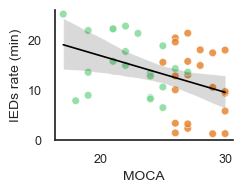

In [51]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Load spikes file
spikes_df = pd.read_csv('figures/MCI_rates_final.csv')

# Load cognitive scores file
cog_df = pd.read_csv('figures/MCI_corr_final.csv')

# Rename columns if needed
cog_df = cog_df.rename(columns={
    'Moca memory test': 'Moca_mem',
    'Spikes_per_min': 'Spikes'
})
group_palette = {'HC': '#e67e22', 'MCI': '#7cd893'}

# Average Spikes_per_min per subject
avg_spikes = spikes_df.groupby('subject')['Spikes_per_min'].mean().reset_index()
avg_spikes = avg_spikes.rename(columns={'Spikes_per_min': 'Avg_Spikes_per_min'})

# Merge with cognitive scores
merged_df = pd.merge(cog_df, avg_spikes, on='subject', how='inner')

# exclude AD group
filtered_df = merged_df[(merged_df['group'] != 'AD')]

# Plotting linear regression
plt.figure(figsize=(2.7, 2.2))

# Scatter plot
sns.scatterplot(
    data=filtered_df,
    x='MOCA',
    y='Avg_Spikes_per_min',
    hue='group',
    palette=group_palette,
    s=30,
    alpha=0.8
)

# Linear regression line (no polynomial)
sns.regplot(
    data=filtered_df,
    x='MOCA',
    y='Avg_Spikes_per_min',
    scatter=False,
    color='black',
    line_kws={'linewidth': 1.2}
)

# Pearson correlation
valid_df = filtered_df[['MOCA', 'Avg_Spikes_per_min']].dropna()
if len(valid_df) >= 2:
    r, p = pearsonr(valid_df['MOCA'], valid_df['Avg_Spikes_per_min'])
    annotation = f'r = {r:.2f}\np = {p:.3f}'
else:
    annotation = 'Not enough data'

# Annotate r and p
# plt.text(0.05, 0.95, annotation, transform=plt.gca().transAxes,
#          ha='left', va='bottom', fontsize=9,
#          bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))
print(annotation)
# Axis styling
plt.legend([],[], frameon=False)  # Optional: Hide legend
plt.xlabel('MOCA', fontsize=10)
plt.ylabel('IEDs rate (min)', fontsize=10)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.ylim(0, 26)  # Adjust Y limits if needed
sns.despine(top=True, right=True)
plt.tight_layout()
# save
# plt.savefig('figures/moca_corr.png', dpi=300, bbox_inches='tight', transparent=False)
plt.show()

r = -0.39
p = 0.009


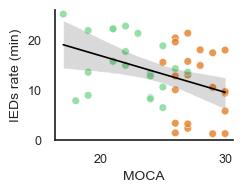

In [57]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Load spikes file
spikes_df = pd.read_csv('figures/MCI_rates_final.csv')

# Load cognitive scores file
cog_df = pd.read_csv('figures/MCI_corr_final.csv')

# Rename columns if needed
cog_df = cog_df.rename(columns={
    'Moca memory test': 'Moca_mem',
    'Spikes_per_min': 'Spikes'
})
group_palette = {'HC': '#e67e22', 'MCI': '#7cd893', 'AD': '#3498db'}

# Average Spikes_per_min per subject
avg_spikes = spikes_df.groupby('subject')['Spikes_per_min'].mean().reset_index()
avg_spikes = avg_spikes.rename(columns={'Spikes_per_min': 'Avg_Spikes_per_min'})

# Merge with cognitive scores
merged_df = pd.merge(cog_df, avg_spikes, on='subject', how='inner')

# exclude AD group
# filtered_df = merged_df[(merged_df['group'] != 'AD')]
filtered_df = merged_df

# Plotting linear regression
plt.figure(figsize=(2.7, 2.2))

# Scatter plot
sns.scatterplot(
    data=filtered_df,
    x='MOCA',
    y='Avg_Spikes_per_min',
    hue='group',
    palette=group_palette,
    s=30,
    alpha=0.8
)

# Linear regression line (no polynomial)
sns.regplot(
    data=filtered_df,
    x='MOCA',
    y='Avg_Spikes_per_min',
    scatter=False,
    color='black',
    line_kws={'linewidth': 1.2}
)

# Pearson correlation
valid_df = filtered_df[['MOCA', 'Avg_Spikes_per_min']].dropna()
if len(valid_df) >= 2:
    r, p = pearsonr(valid_df['MOCA'], valid_df['Avg_Spikes_per_min'])
    annotation = f'r = {r:.2f}\np = {p:.3f}'
else:
    annotation = 'Not enough data'

# Annotate r and p
# plt.text(0.05, 0.95, annotation, transform=plt.gca().transAxes,
#          ha='left', va='bottom', fontsize=9,
#          bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))
print(annotation)
# Axis styling
plt.legend([],[], frameon=False)  # Optional: Hide legend
plt.xlabel('MOCA', fontsize=10)
plt.ylabel('IEDs rate (min)', fontsize=10)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.ylim(0, 26)  # Adjust Y limits if needed
sns.despine(top=True, right=True)
plt.tight_layout()
# save
# plt.savefig('figures/moca_corr.png', dpi=300, bbox_inches='tight', transparent=False)
plt.show()

r = -0.25
p = 0.072


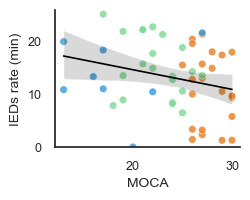

In [124]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Load spikes file
spikes_df = pd.read_csv('figures/MCI_rates_final.csv')

# Load cognitive scores file
cog_df = pd.read_csv('figures/MCI_corr_final.csv')

# Rename columns if needed
cog_df = cog_df.rename(columns={
    'Moca memory test': 'Moca_mem',
    'Spikes_per_min': 'Spikes'
})
group_palette = {'HC': '#e67e22', 'MCI': '#7cd893', 'AD': '#3498db'}

# Average Spikes_per_min per subject
avg_spikes = spikes_df.groupby('subject')['Spikes_per_min'].mean().reset_index()
avg_spikes = avg_spikes.rename(columns={'Spikes_per_min': 'Avg_Spikes_per_min'})

# Merge with cognitive scores
merged_df = pd.merge(cog_df, avg_spikes, on='subject', how='inner')

# exclude AD group
filtered_df = merged_df[(merged_df['MOCA'] > 10)]

# Plotting linear regression
plt.figure(figsize=(2.7, 2.2))

# Scatter plot
sns.scatterplot(
    data=filtered_df,
    x='MOCA',
    y='Avg_Spikes_per_min',
    hue='group',
    palette=group_palette,
    s=30,
    alpha=0.8
)

# Linear regression line (no polynomial)
sns.regplot(
    data=filtered_df,
    x='MOCA',
    y='Avg_Spikes_per_min',
    scatter=False,
    color='black',
    line_kws={'linewidth': 1.2}
)

# Pearson correlation
valid_df = filtered_df[['MOCA', 'Avg_Spikes_per_min']].dropna()
if len(valid_df) >= 2:
    r, p = pearsonr(valid_df['MOCA'], valid_df['Avg_Spikes_per_min'])
    annotation = f'r = {r:.2f}\np = {p:.3f}'
else:
    annotation = 'Not enough data'

# Annotate r and p
# plt.text(0.05, 0.95, annotation, transform=plt.gca().transAxes,
#          ha='left', va='bottom', fontsize=9,
#          bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))
print(annotation)
# Axis styling
plt.legend([],[], frameon=False)  # Optional: Hide legend
plt.xlabel('MOCA', fontsize=10)
plt.ylabel('IEDs rate (min)', fontsize=10)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.ylim(0, 26)  # Adjust Y limits if needed
sns.despine(top=True, right=True)
plt.tight_layout()
# save
# plt.savefig('figures/moca_corr.png', dpi=300, bbox_inches='tight', transparent=False)
plt.show()

התווספו מהקובץ EPI_MOCA: ['LS56', 'NE36', 'ON68', 'RD43', 'SB00', 'YF58']
r = -0.48
p = 0.00046


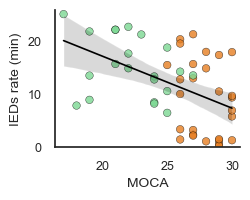

In [87]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import numpy as np

# --- קבצים ---
spikes_main = pd.read_csv('figures/MCI_rates_final.csv')   # כולל subject, group, Spikes_per_min
cog_main    = pd.read_csv('figures/MCI_corr_final.csv')    # כולל subject, group, MOCA (נניח שהעמודות כך)
epi         = pd.read_csv('figures/EPI_MOCA.csv')          # subject, Spikes_per_min, group, MOCA

# --- ניקוי בסיסי ---
for df in (spikes_main, cog_main, epi):
    for col in ('subject','group'):
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip()

# ודא ש-HC מסומן כראוי בקובץ הנוסף
epi['group'] = 'HC'

# --- ממוצע ספייקים לכל נבדק ---
avg_main = (spikes_main.groupby('subject', as_index=False)['Spikes_per_min']
            .mean().rename(columns={'Spikes_per_min':'Avg_Spikes_per_min'}))

# אם אין ספייקים בקובץ הראשי, קח מה-EPI_MOCA
avg_epi = (epi.groupby('subject', as_index=False)['Spikes_per_min']
           .mean().rename(columns={'Spikes_per_min':'Avg_Spikes_per_min'}))

# מאחדים, עם עדיפות לערך מהקובץ הראשי (אם קיים)
spikes_all = avg_main.merge(avg_epi, on='subject', how='outer', suffixes=('_main','_epi'))
spikes_all['Avg_Spikes_per_min'] = spikes_all['Avg_Spikes_per_min_main'].combine_first(spikes_all['Avg_Spikes_per_min_epi'])
spikes_all = spikes_all[['subject','Avg_Spikes_per_min']]

# --- מאחדים קוגניציה: קובץ ראשי + קובץ HC הנוסף (עדיפות לראשי אם יש כפילויות) ---
cog_keep_cols = ['subject','group','MOCA']
cog_all = pd.concat([cog_main[cog_keep_cols], epi[cog_keep_cols]], ignore_index=True)
cog_all = cog_all.drop_duplicates(subset=['subject'], keep='first').reset_index(drop=True)

# --- מיזוג קוגניציה+ספייקים ---
merged_df = pd.merge(cog_all, spikes_all, on='subject', how='inner')

# דיווח מי התווסף מהקובץ הנוסף
new_from_epi = set(epi['subject']) - set(cog_main['subject'])
actually_added = sorted(list(set(merged_df['subject']) & new_from_epi))
if actually_added:
    print(f"התווספו מהקובץ EPI_MOCA: {actually_added}")

# --- סינון בלי AD (כמו בקוד שלך) ---
filtered_df = merged_df[merged_df['group'] != 'AD'].copy()

# --- ציור + מתאם ---
group_palette = {'HC': '#e67e22', 'MCI': '#7cd893', 'AD': '#3498db'}  # AD לא יוצג כי סונן
plt.figure(figsize=(2.7, 2.2))

sns.scatterplot(
    data=filtered_df,
    x='MOCA', y='Avg_Spikes_per_min',
    hue='group', palette=group_palette,
    s=30, alpha=0.8, edgecolor='black', linewidth=0.3
)

sns.regplot(
    data=filtered_df,
    x='MOCA', y='Avg_Spikes_per_min',
    scatter=False, color='black',
    line_kws={'linewidth': 1.2}
)

valid_df = filtered_df[['MOCA','Avg_Spikes_per_min']].dropna()
if len(valid_df) >= 2:
    r, p = pearsonr(valid_df['MOCA'], valid_df['Avg_Spikes_per_min'])
    print(f"r = {r:.2f}\np = {p:.5f}")
else:
    print("Not enough data")

plt.legend([], [], frameon=False)
plt.xlabel('MOCA', fontsize=10)
plt.ylabel('IEDs rate (min)', fontsize=10)
plt.xticks(fontsize=9); plt.yticks(fontsize=9)
plt.ylim(0, 26)
sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()


התווספו מהקובץ EPI_MOCA: ['LS56', 'NE36', 'ON68', 'RD43', 'SB00', 'YF58']
r = -0.36
p = 0.006


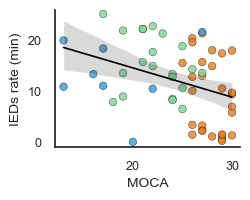

In [86]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import numpy as np

# --- קבצים ---
spikes_main = pd.read_csv('figures/MCI_rates_final.csv')   # כולל subject, group, Spikes_per_min
cog_main    = pd.read_csv('figures/MCI_corr_final.csv')    # כולל subject, group, MOCA (נניח שהעמודות כך)
epi         = pd.read_csv('figures/EPI_MOCA.csv')          # subject, Spikes_per_min, group, MOCA

# --- ניקוי בסיסי ---
for df in (spikes_main, cog_main, epi):
    for col in ('subject','group'):
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip()

# ודא ש-HC מסומן כראוי בקובץ הנוסף
epi['group'] = 'HC'

# --- ממוצע ספייקים לכל נבדק ---
avg_main = (spikes_main.groupby('subject', as_index=False)['Spikes_per_min']
            .mean().rename(columns={'Spikes_per_min':'Avg_Spikes_per_min'}))

# אם אין ספייקים בקובץ הראשי, קח מה-EPI_MOCA
avg_epi = (epi.groupby('subject', as_index=False)['Spikes_per_min']
           .mean().rename(columns={'Spikes_per_min':'Avg_Spikes_per_min'}))

# מאחדים, עם עדיפות לערך מהקובץ הראשי (אם קיים)
spikes_all = avg_main.merge(avg_epi, on='subject', how='outer', suffixes=('_main','_epi'))
spikes_all['Avg_Spikes_per_min'] = spikes_all['Avg_Spikes_per_min_main'].combine_first(spikes_all['Avg_Spikes_per_min_epi'])
spikes_all = spikes_all[['subject','Avg_Spikes_per_min']]

# --- מאחדים קוגניציה: קובץ ראשי + קובץ HC הנוסף (עדיפות לראשי אם יש כפילויות) ---
cog_keep_cols = ['subject','group','MOCA']
cog_all = pd.concat([cog_main[cog_keep_cols], epi[cog_keep_cols]], ignore_index=True)
cog_all = cog_all.drop_duplicates(subset=['subject'], keep='first').reset_index(drop=True)

# --- מיזוג קוגניציה+ספייקים ---
merged_df = pd.merge(cog_all, spikes_all, on='subject', how='inner')

# דיווח מי התווסף מהקובץ הנוסף
new_from_epi = set(epi['subject']) - set(cog_main['subject'])
actually_added = sorted(list(set(merged_df['subject']) & new_from_epi))
if actually_added:
    print(f"התווספו מהקובץ EPI_MOCA: {actually_added}")

# --- סינון בלי AD (כמו בקוד שלך) ---
filtered_df = merged_df[merged_df['MOCA'] > 10].copy()

# --- ציור + מתאם ---
group_palette = {'HC': '#e67e22', 'MCI': '#7cd893', 'AD': '#3498db'}  # AD לא יוצג כי סונן
plt.figure(figsize=(2.7, 2.2))

sns.scatterplot(
    data=filtered_df,
    x='MOCA', y='Avg_Spikes_per_min',
    hue='group', palette=group_palette,
    s=30, alpha=0.8, edgecolor='black', linewidth=0.3
)

sns.regplot(
    data=filtered_df,
    x='MOCA', y='Avg_Spikes_per_min',
    scatter=False, color='black',
    line_kws={'linewidth': 1.2}
)

valid_df = filtered_df[['MOCA','Avg_Spikes_per_min']].dropna()
if len(valid_df) >= 2:
    r, p = pearsonr(valid_df['MOCA'], valid_df['Avg_Spikes_per_min'])
    print(f"r = {r:.2f}\np = {p:.3f}")
else:
    print("Not enough data")

plt.legend([], [], frameon=False)
plt.xlabel('MOCA', fontsize=10)
plt.ylabel('IEDs rate (min)', fontsize=10)
plt.xticks(fontsize=9); plt.yticks(fontsize=9)
plt.ylim(-1, 26)
sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()


In [121]:
import pandas as pd
import numpy as np
from scipy.stats import f_oneway, ttest_ind

# ===== קריאה וניקוי =====
spikes_main = pd.read_csv('figures/MCI_rates_final.csv')   # subject, group, Spikes_per_min
cog_main    = pd.read_csv('figures/MCI_corr_final.csv')    # subject, group, MOCA (או עמודה דומה)
epi         = pd.read_csv('figures/EPI_MOCA.csv')          # subject, Spikes_per_min, group, MOCA

for df in (spikes_main, cog_main, epi):
    for col in ('subject','group'):
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip()

# ודא שהקובץ הנוסף מסומן כ-HC (גם אם כבר מסומן)
epi['group'] = 'HC'

# מאחדים את טבלאות הקוגניציה (עדיפות לרשומה מהקובץ הראשי אם יש כפילויות)
cog_keep_cols = ['subject','group','MOCA']
cog_all = pd.concat([cog_main[cog_keep_cols], epi[cog_keep_cols]], ignore_index=True)
cog_all = cog_all.drop_duplicates(subset=['subject'], keep='first').reset_index(drop=True)

# ===== מיפוי HC ל-Young/Elderly =====
young_subjects = set(epi['subject'])
def map_group(row):
    if row['group'] == 'HC':
        return 'Young' if row['subject'] in young_subjects else 'Elderly'
    return row['group']

cog_all['group4'] = cog_all.apply(map_group, axis=1)
cog_all['MOCA'] = pd.to_numeric(cog_all['MOCA'], errors='coerce')

# נשמור רק מי שיש לו MOCA וקבוצה מוגדרת
df_anova = cog_all.dropna(subset=['MOCA','group4']).copy()

# ----- ANOVA חד-כיווני על MOCA בארבע קבוצות -----
group_order = ['Young', 'Elderly', 'MCI', 'AD']
groups = [df_anova.loc[df_anova['group4']==g, 'MOCA'].dropna().values for g in group_order]

# שומר על יציבות אם קבוצה ריקה
empty = [g for g, arr in zip(group_order, groups) if arr.size == 0]
if empty:
    print(f"Cannot run ANOVA: empty groups: {empty}")
else:
    k = len(group_order)
    N = sum(arr.size for arr in groups)
    F, p = f_oneway(*groups)
    print(f"One-way ANOVA on MoCA across 4 groups: F({k-1}, {N-k}) = {F:.3f}, p = {p:.4g}")

# ----- t-tests ספציפיים (Welch) -----
def welch_df(x, y):
    nx, ny = len(x), len(y)
    vx, vy = x.var(ddof=1)/nx, y.var(ddof=1)/ny
    return (vx + vy)**2 / ((vx**2)/(nx-1) + (vy**2)/(ny-1))

pairs = [('Elderly','MCI'), ('MCI','AD')]
results = []
for a, b in pairs:
    xa = df_anova.loc[df_anova['group4']==a, 'MOCA'].dropna().values
    xb = df_anova.loc[df_anova['group4']==b, 'MOCA'].dropna().values
    if xa.size == 0 or xb.size == 0:
        print(f"Cannot run t-test for {a} vs {b}: empty group.")
        results.append((a,b,np.nan,np.nan,np.nan))
        continue
    t, p_raw = ttest_ind(xa, xb, equal_var=False)  # Welch
    df_w = welch_df(xa, xb)
    results.append((a,b,t,p_raw,df_w))

# תיקון Holm–Bonferroni לשתי ההשוואות
pvals = np.array([r[3] if np.isfinite(r[3]) else 1.0 for r in results])
order = np.argsort(pvals)
m = len(pvals)
p_holm = np.empty_like(pvals, dtype=float)
max_prev = 0.0
for i, idx in enumerate(order):
    val = min(1.0, (m - i) * pvals[idx])
    val = max(val, max_prev)  # מונוטוניות
    max_prev = val
    p_holm[idx] = val

def stars(p):
    return '***' if p < 1e-3 else '**' if p < 1e-2 else '*' if p < 0.05 else 'ns'

print("\nPairwise Welch t-tests (requested only) with Holm–Bonferroni:")
for (a,b,t,p_raw,df_w), ph in zip(results, p_holm):
    if not np.isfinite(p_raw):
        print(f"{a} vs {b}: not computed (empty group)")
    else:
        print(f"{a} vs {b}: t={t:.3f}, df≈{df_w:.1f}, p_raw={p_raw:.4g}, p_holm={ph:.4g}  {stars(ph)}")


One-way ANOVA on MoCA across 4 groups: F(3, 54) = 32.207, p = 4.506e-12

Pairwise Welch t-tests (requested only) with Holm–Bonferroni:
Elderly vs MCI: t=7.673, df≈32.5, p_raw=8.568e-09, p_holm=1.714e-08  ***
MCI vs AD: t=2.560, df≈9.3, p_raw=0.02994, p_holm=0.02994  *


r = -0.25
p = 0.072


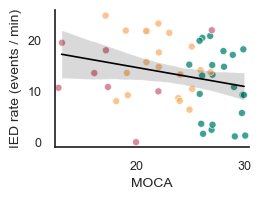

In [138]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import numpy as np

# --- קבצים ---
spikes_main = pd.read_csv('figures/MCI_rates_final.csv')   # subject, group, Spikes_per_min
cog_main    = pd.read_csv('figures/MCI_corr_final.csv')    # subject, group, MOCA
epi         = pd.read_csv('figures/EPI_MOCA.csv')          # subject, Spikes_per_min, group, MOCA

# --- ניקוי בסיסי ---
for df in (spikes_main, cog_main, epi):
    for col in ('subject','group'):
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip()

# ודא שהקובץ הנוסף מסומן כ-HC
epi['group'] = 'HC'

# --- ממוצע ספייקים לכל נבדק ---
avg_main = (spikes_main.groupby('subject', as_index=False)['Spikes_per_min']
            .mean().rename(columns={'Spikes_per_min':'Avg_Spikes_per_min'}))
avg_epi  = (epi.groupby('subject', as_index=False)['Spikes_per_min']
            .mean().rename(columns={'Spikes_per_min':'Avg_Spikes_per_min'}))

# מאחדים ממוצעי ספייקים (עדיפות ל-main)
spikes_all = avg_main.merge(avg_epi, on='subject', how='outer', suffixes=('_main','_epi'))
spikes_all['Avg_Spikes_per_min'] = spikes_all['Avg_Spikes_per_min_main'].combine_first(spikes_all['Avg_Spikes_per_min_epi'])
spikes_all = spikes_all[['subject','Avg_Spikes_per_min']]

# --- איחוד קוגניציה (עדיפות ל-main) ---
cog_keep_cols = ['subject','group','MOCA']
cog_all = pd.concat([cog_main[cog_keep_cols], epi[cog_keep_cols]], ignore_index=True)
cog_all = cog_all.drop_duplicates(subset=['subject'], keep='first').reset_index(drop=True)

# --- Young/Elderly: כל מי שמגיע מ-EPI_MOCA => Young; שאר ה-HC => Elderly ---
young_subjects = set(epi['subject'])
def map_group4(row):
    if row['group'] == 'HC':
        return 'Young' if row['subject'] in young_subjects else 'Elderly'
    return row['group']  # MCI / AD

cog_all['group4'] = cog_all.apply(map_group4, axis=1)
cog_all['MOCA'] = pd.to_numeric(cog_all['MOCA'], errors='coerce')

# --- מיזוג קוגניציה + ספייקים ---
merged_df = pd.merge(cog_all, spikes_all, on='subject', how='inner')

# --- פילטר (אם צריך, כמו אצלך) ---
filtered_df = merged_df[merged_df['MOCA'] > 10].copy()
# select only the two groups
filtered_df = filtered_df[filtered_df['group4'].isin(['Elderly', 'MCI', 'AD'])]
# --- צבעים כמו ב-RainCloud: Young/Elderly/MCI/AD ---
palette_map = {'Young': '#81b88e', 'Elderly': '#00826e', 'MCI': '#F6B26B', 'AD': '#CC6677'}
hue_order   = ['Young', 'Elderly', 'MCI', 'AD']

# --- ציור + מתאם ---
sns.set_context("notebook", font_scale=1.1)
sns.set_style("white")
plt.figure(figsize=(2.8, 2.2))

# --- פרמטרים לנראות ---
DOT_SIZE = 26          # היה ~32
ALPHA    = 0.75        # היה 0.85
EDGE_LW  = 0.6         # קצה לבן קצת עבה יותר

# --- Jitter עדין (עם seed לשחזור) ---
rng = np.random.default_rng(42)
SIGMA_X = 0.15         # ~0.15 נק' MOCA
SIGMA_Y = 0.35         # ~0.35 באירועים/דקה

plot_df = filtered_df.copy()
plot_df['MOCA_plot'] = plot_df['MOCA'] + rng.normal(0, SIGMA_X, len(plot_df))
plot_df['IED_plot']  = np.clip(
    plot_df['Avg_Spikes_per_min'] + rng.normal(0, SIGMA_Y, len(plot_df)),
    0, None
)

# נקודות משופרות
sns.scatterplot(
    data=plot_df,
    x='MOCA_plot', y='IED_plot',
    hue='group4', hue_order=['Young','Elderly','MCI','AD'],
    palette={'Young':'#81b88e','Elderly':'#00826e','MCI':'#F6B26B','AD':'#CC6677'},
    s=DOT_SIZE, alpha=ALPHA,
    edgecolor='white', linewidth=EDGE_LW
)

# קו רגרסיה על הנתונים המקוריים (בלי נקודות)
sns.regplot(
    data=filtered_df,
    x='MOCA', y='Avg_Spikes_per_min',
    scatter=False, color='black',
    line_kws={'linewidth': 1.2}
)

# Pearson r,p על כל המדגם (אפשר גם לפי קבוצה אם תרצי)
valid_df = filtered_df[['MOCA','Avg_Spikes_per_min']].dropna()
if len(valid_df) >= 2:
    r, p = pearsonr(valid_df['MOCA'], valid_df['Avg_Spikes_per_min'])
    print(f"r = {r:.2f}\np = {p:.3f}")
else:
    print("Not enough data")

# עיצוב
plt.legend([], [], frameon=False)   # בלי מקרא; הסדר נשמר ב-hue_order אם תרצי להציג
plt.xlabel('MOCA', fontsize=10)
plt.ylabel('IED rate (events / min)', fontsize=10)
plt.xticks(fontsize=9); plt.yticks(fontsize=9)
plt.ylim(-1, 26)
plt.xlim(12.4, 30.5)
sns.despine(top=True, right=True)
plt.tight_layout()
# save
plt.show()


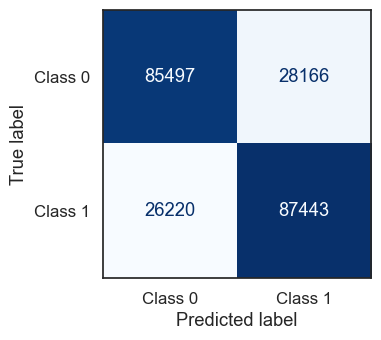

In [139]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import pandas as pd
import matplotlib.pyplot as plt

# קריאת התוצאות ששמרת
df = pd.read_csv('figures/confusion_bmax_asym_metrics.csv')

# מטריצת בלבול גולמית (לא מנורמלת)
cm = confusion_matrix(df['y_true'], df['y_pred'])

# ציור – בלי colorbar
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Class 0", "Class 1"])

fig, ax = plt.subplots(figsize=(4, 4))
disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format="d")  # "d" = integer format
plt.tight_layout()
plt.show()


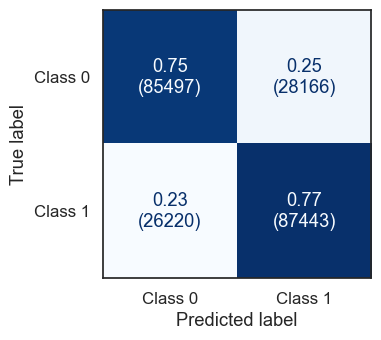

In [140]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# קריאת התוצאות ששמרת
df = pd.read_csv('figures/confusion_bmax_asym_metrics.csv')

# מטריצות: גולמית ומנורמלת לפי שורה
cm_raw = confusion_matrix(df['y_true'], df['y_pred'])
cm_norm = confusion_matrix(df['y_true'], df['y_pred'], normalize='true')

# יצירת טקסט מותאם לכל תא (שורה ראשונה - ערך מנורמל, שורה שנייה - ערך גולמי בסוגריים)
labels = np.array([[f"{cm_norm[i,j]:.2f}\n({cm_raw[i,j]})" for j in range(cm_raw.shape[1])]
                   for i in range(cm_raw.shape[0])])

# ציור
fig, ax = plt.subplots(figsize=(4, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=["Class 0", "Class 1"])
disp.plot(ax=ax, cmap='Blues', colorbar=False)

# החלפת הערכים המודפסים
for text, label in zip(ax.texts, labels.flatten()):
    text.set_text(label)

plt.tight_layout()
plt.show()


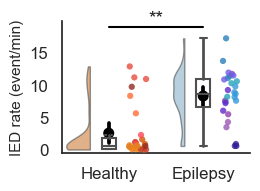

In [142]:
import seaborn as sns
import matplotlib.pyplot as plt
import ptitprince as pt
from scipy.stats import ttest_ind

# סגנון
sns.set_context("notebook", font_scale=1.1)
sns.set_style("white")

# קריאת הנתונים
df = pd.read_csv('figures/V1.csv')
df['group'] = df['group'].replace({'HC': 'Healthy', 'EPI': 'Epilepsy'})

# הכנת הנתונים - לא צריך melt כי הנתונים כבר בפורמט הנכון
data_subset = df.copy()

# סדר הקבוצות
group_order = ['Healthy', 'Epilepsy']

# ציור
fig, ax = plt.subplots(figsize=(2.8, 2.1))  # רוחב קטן יותר לשתי קבוצות

# Raincloud (without individual points)
pt.RainCloud(
    x='group',
    y='Spikes_per_min',
    data=data_subset,
    order=group_order,
    palette=['#e67e22', '#7fb3d3'],  # HC = orange, EPI = blue
    bw=.3,
    width_viol=.5,
    ax=ax,
    orient='v',
    move=0.2,
    alpha=0.6,
    pointplot=False,
    box_showfliers=False,
    point_size=0,  # This removes the individual points from RainCloud
)

# Get unique subjects for each group
hc_subjects = data_subset[data_subset['group'] == 'Healthy']['subject'].unique()
epi_subjects = data_subset[data_subset['group'] == 'Epilepsy']['subject'].unique()

# Create color palette
subject_colors = {}

# HC subjects - orange to red shades
hc_colors = [
    '#e88c1b',  # Original orange
    '#e67e22',  # Orange
    '#d35400',  # Dark orange
    '#e74c3c',  # Red
    '#c0392b',  # Dark red
    '#922b21',  # Darker red
    '#ff6b35',  # Orange-red
    '#ff4757',  # Light red
]

# Extend the list if we have more HC subjects than predefined colors
while len(hc_colors) < len(hc_subjects):
    hc_colors.extend(hc_colors)

for i, subject in enumerate(hc_subjects):
    subject_colors[subject] = hc_colors[i % len(hc_colors)]

# EPI subjects - blue to purple shades
epi_colors = [
    '#26a3b8',  # Original blue
    '#3498db',  # Light blue
    '#2980b9',  # Blue
    '#8e44ad',  # Purple
    '#9b59b6',  # Light purple
    '#6c5ce7',  # Blue-purple
    '#5f27cd',  # Dark purple
    '#341f97',  # Very dark purple
]

# Extend the list if we have more EPI subjects than predefined colors
while len(epi_colors) < len(epi_subjects):
    epi_colors.extend(epi_colors)

for i, subject in enumerate(epi_subjects):
    subject_colors[subject] = epi_colors[i % len(epi_colors)]

# Convert to list in the order seaborn expects
subject_palette = [subject_colors[subject] for subject in data_subset['subject'].unique()]

# Add individual points colored by subject (positioned to the right)
sns.stripplot(
    data=data_subset,
    x='group',
    y='Spikes_per_min',
    hue='subject',
    order=group_order,
    palette=subject_palette,
    ax=ax,
    size=4.5,
    alpha=0.8,
    jitter=0.1
)

# Get all collections created by stripplot (one for each subject)
stripplot_collections = ax.collections[2:]  # Skip the first 2 collections (violin and box)

# Move all points to the right of boxplots
for collection in stripplot_collections:
    if collection.get_offsets().size > 0:  # Check if collection has points
        offsets = collection.get_offsets()
        # Move points to the right: add 0.3 to all x-coordinates
        offsets[:, 0] = offsets[:, 0] + 0.3
        collection.set_offsets(offsets)

# Remove the legend (too many subjects for a useful legend)
ax.get_legend().remove()

# ממוצעים
sns.pointplot(
    data=data_subset,
    x='group',
    y='Spikes_per_min',
    order=group_order,
    color='black',
    join=False,
    markers='o',
    errorbar=None,
    scale=0.9,
    ax=ax
)

# סטטיסטיקה - השוואה בין HC ל-EPI
vals1 = data_subset[data_subset['group'] == 'Healthy']['Spikes_per_min']
vals2 = data_subset[data_subset['group'] == 'Epilepsy']['Spikes_per_min']
# stat, pval = ttest_ind(vals1, vals2, equal_var=False)

# ציור כוכביות
y_max = data_subset['Spikes_per_min'].max()
y_line = y_max * 1.1  # גובה הקו
y_star = y_max * 1.1  # גובה הכוכבית

# ציור הקו והכוכבית
star = '**'
ax.plot([0, 1], [y_line, y_line], color='black', linewidth=1.5)
ax.text(0.5, y_star, star, ha='center', va='bottom', fontsize=14)

# עיצוב
ax.set_ylabel("IED rate (event/min)", fontsize=11)
ax.set_xlabel("")
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(bottom=-0.5)
ax.set_yticks([0, 5, 10, 15])

plt.tight_layout()
# fig.savefig("figures/V1.png", dpi=300, bbox_inches='tight', transparent=False)
plt.show()

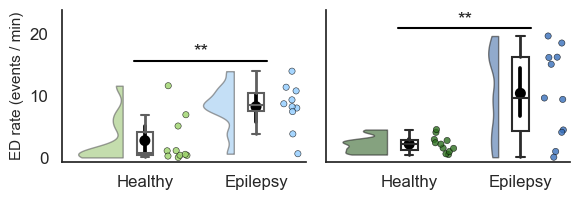

In [144]:
# mean values
import seaborn as sns
import matplotlib.pyplot as plt
import ptitprince as pt
import pandas as pd
from scipy.stats import ttest_ind
import numpy as np

# ---------- Shared style ----------
sns.set_context("notebook", font_scale=1.1)
sns.set_style("white")

def p_to_stars(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "ns"

def annotate_sig(ax, data, group_col="group", value_col="Spikes_per_min",
                 groups=("Healthy", "Epilepsy")):
    """Welch t-test between the two groups and star annotation."""
    g1 = data.loc[data[group_col] == groups[0], value_col].dropna().to_numpy()
    g2 = data.loc[data[group_col] == groups[1], value_col].dropna().to_numpy()

    # Welch t-test
    if len(g1) >= 2 and len(g2) >= 2:
        tstat, p = ttest_ind(g1, g2, equal_var=False)
        label = p_to_stars(p)
    else:
        p, label = np.nan, "ns"

    # Place bar & text a bit above the tallest point
    ymin, ymax = ax.get_ylim()
    data_max = np.nanmax([ymax, data[value_col].max() if len(data) else ymax])
    rng = data_max - ymin if data_max > ymin else 1.0
    y = data_max + 0.06 * rng
    ax.plot([0 - 0.1, 1 + 0.1], [y, y], color='black', linewidth=1.5)
    ax.text(0.5, y, label, ha='center', va='bottom', fontsize=14)

    # Ensure there’s room for the bar
    ax.set_ylim(ymin, y + 0.15 * rng)

def draw_panel(ax, csv_path, palette_dict):
    # Params that control geometry
    width_viol = 0.8
    move = 0.2
    point_shift = 0.30
    pad = 0.15

    # ---- Data: load and collapse to one mean per subject ----
    df = pd.read_csv(csv_path)
    df['group'] = df['group'].replace({'HC': 'Healthy', 'EPI': 'Epilepsy'})
    df_mean = (
        df.groupby(['subject', 'group'], as_index=False)['Spikes_per_min']
          .mean()
    )

    group_order = ['Healthy', 'Epilepsy']
    palette_list = [palette_dict[g] for g in group_order]

    # RainCloud over subject means
    pt.RainCloud(
        x='group', y='Spikes_per_min',
        data=df_mean, order=group_order,
        palette=palette_list, bw=.3,
        width_viol=width_viol, ax=ax, orient='v',
        move=move, alpha=0.6,
        pointplot=False, box_showfliers=False,
        point_size=0,
    )

    # Individual points: one per subject
    pre_n = len(ax.collections)
    sns.stripplot(
        data=df_mean, x='group', y='Spikes_per_min',
        hue='group', order=group_order,
        palette=palette_dict, dodge=False,
        ax=ax, size=4.5, alpha=0.8, jitter=0.1,
        edgecolor="black", linewidth=0.4
    )
    # Shift dots slightly right for visibility
    new_cols = ax.collections[pre_n:]
    for col in new_cols:
        offs = col.get_offsets()
        if offs.size > 0:
            offs[:, 0] = offs[:, 0] + point_shift
            col.set_offsets(offs)

    # Group means (of subject means)
    sns.pointplot(
        data=df_mean, x='group', y='Spikes_per_min',
        order=group_order, color='black',
        join=False, markers='o', errorbar=None, scale=0.9, ax=ax
    )

    # Axes cosmetics
    ax.set_xlabel("")
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Prevent left violin from being clipped (computed xlim)
    left_extent  = 0 + move - width_viol   # -0.6 with current params
    right_extent = 1 + point_shift         # ~1.30
    ax.set_xlim(left_extent - pad, right_extent + pad)

    # Significance stars from Welch t-test
    annotate_sig(ax, df_mean)

    return ax

# ---------- Figure with two side-by-side panels ----------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6.0, 2.2), sharey=True)

# Left panel: V1
palette_v1 = {'Healthy': '#9CD46A', 'Epilepsy': '#90CCFF'}
draw_panel(ax1, 'figures/V1.csv', palette_v1)
ax1.set_ylabel("ED rate (events / min)", fontsize=11)
ax1.get_legend().remove()

# Right panel: V2
palette_v2 = {'Healthy': '#2E6F20', 'Epilepsy': '#3870bb'}
draw_panel(ax2, 'figures/V2.csv', palette_v2)
ax2.set_ylabel("")  # sharey=True keeps ticks; no duplicate label
ax2.get_legend().remove()

plt.tight_layout()
# plt.savefig("figures/V1_V2_side_by_side.pdf", dpi=600, bbox_inches='tight', transparent=False)
plt.show()


### depth cognitive

In [145]:
import mne
import joblib

mtl_path = 'C:\\clean_zeeg\\P%s_mtl_clean.fif'
tlv_subjects = ['013', '017', '018', '025', '38', '39', '44', '46', '47', '48', '49', '51', '53', '54', '55', '56', '57']
bonn_subjects = ['707', '708', '709', '710', '711', '712', '713', '714', '715', '723', '724', '728', '731', '733', '734', '735', '737', '744', '746', '752']
milan_subjects = ['801', '802', '804', '805', '807', '809', '810', '812', '813', '814', '815', '816', '817', '818']
all_subjects = tlv_subjects + bonn_subjects + milan_subjects
depth_channels = ['RAH1', 'LAH1', 'RA1', 'LA1', 'LEC1', 'REC1', 'RPHG1', 'LPHG1', 'RMH1', 'LMH1', 'LH1', 'RH1', 'RA3'
                  'RAH2', 'LAH2', 'RA2', 'LA2', 'LEC2', 'REC2', 'RPHG2', 'LPHG2', 'RMH2', 'LMH2', 'LH2', 'RH2']
scalp_channels = ['C3', 'C4', 'PZ', 'EOG1', 'EOG2', 'F4', 'P4', 'F10', 'T10', 'F3', 'P3', 'F9', 'T9', 'CZ', 'P4', 'F8',
                  'T8', 'P8', 'O1', 'O2', 'T5', 'C6', 'P6', 'F7', 'C5', 'P5', 'FZ']

subj_data = joblib.load('subj_data_final - Copy.pkl')
bad_under_55 = ['39', '55', '801', '802', '805', '809', '812', '813', '815', '816', '817']
less_4_chans = ['018', '025', '46', '53', '801', '809', '814', '818']
less_10 = ['025', '46', '49', '807', '814']
tlv_nrem = ['013', '017', '018', '025', '38', '39', '44', '46', '47', '48', '51', '53', '56',
            '57']  # without 49- no scoring, 55- scoring doesnt fit, 54- mismtach
# clean_subjects = [x for x in all_subjects if x not in bad_under_55+less_10]
# clean_subjects = [x for x in tlv_subjects+bonn_subjects if x not in bad_under_55+less_10]
clean_subjects = [x for x in all_subjects if x != '807']
print(len(all_subjects), len(clean_subjects))

51 50


In [147]:
# combine all nrem
import numpy as np
import pandas as pd

# Combine all subjects
symmetric = True
x = pd.DataFrame()
y = np.array([])
# [13, 18, 25, 38, 39] 
for subj in ['013']:
    print(f'Processing {subj}')

    # Load subject data
    eog1_subj = subj_data[subj]['eog1']
    eog2_subj = subj_data[subj]['eog2']
    y_subj = subj_data[subj]['y']

    # Reset index
    eog1_subj.reset_index(drop=True, inplace=True)
    eog2_subj.reset_index(drop=True, inplace=True)

    # Load FIF file to get sampling frequency
    fif_file = rf"D:\clean_zeeg\P{subj}_mtl_clean.fif"
    raw = mne.io.read_raw_fif(fif_file, preload=True, verbose=False)
    raw.pick(picks=0)  # Pick only the first channel
    sfreq = raw.info['sfreq']  # Get sampling frequency

    # Load hypnogram and expand it to 250ms resolution
    hypnogram_file = rf"D:\Ichilov_scoring\P{subj}.txt"
    hypnogram = np.loadtxt(hypnogram_file)
    hypnogram_250ms = np.repeat(hypnogram, 4)  # Expand to match epochs

    # Compute correct epoch size in samples
    epoch_samples = int(sfreq * 0.25)  # 250ms in samples

    # Get raw data and flatten it
    raw_data = raw.get_data(reject_by_annotation='NaN').flatten()

    # Find valid indices (epochs without NaNs)
    valid_hypnogram_indices = []
    for i in range(0, len(raw_data) - 4 * epoch_samples, epoch_samples):
        epoch = raw_data[i: i + epoch_samples]

        # Check if the epoch contains NaN
        if not np.isnan(epoch).any():
            valid_hypnogram_indices.append(i // epoch_samples)  # Save the valid hypnogram index

    # Extract the valid hypnogram values
    valid_hypno = hypnogram_250ms[valid_hypnogram_indices]

    # Keep only epochs where hypno == 2 or 3
    sleep_mask = np.isin(valid_hypno, [2, 3])

    # Apply filtering to the subject's data
    eog1_subj = eog1_subj.iloc[sleep_mask]
    eog2_subj = eog2_subj.iloc[sleep_mask]
    y_subj = y_subj[sleep_mask]

    # Combine EOG signals into a single dataframe
    x_subj = pd.concat([eog1_subj, eog2_subj], axis=1, ignore_index=True)
    x_subj.columns = [f'eog1_{col}' for col in eog1_subj.columns] + [f'eog2_{col}' for col in eog2_subj.columns]

    # Append to overall dataset
    x = pd.concat([x, x_subj], ignore_index=True)
    y = np.concatenate((y, y_subj))


print("Final dataset shape:", x.shape, y.shape)

Processing 013


C:\Users\user\AppData\Local\Temp\ipykernel_10800\4046304315.py:24: RuntimeWarning: This filename (D:\clean_zeeg\P013_mtl_clean.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(fif_file, preload=True, verbose=False)


Setting 2929940 of 30162000 (9.71%) samples to NaN, retaining 27232060 (90.29%) samples.
Final dataset shape: (72002, 216) (72002,)


In [152]:
# load model
model_path = r'C:\repos\spikes_notebooks\validation_models_v3\xgb_s50_f210_b_3000max.pkl'
model = joblib.load(model_path)

# predict on x columns according the model features
y_pred = model.predict_proba(x[model.feature_names_in_])[:, 1]
y_pred

array([0.08878148, 0.0988229 , 0.16686232, ..., 0.22572123, 0.33402187,
       0.1508398 ], dtype=float32)

In [157]:
# take only above 70%
y_pred_bin = (y_pred >= 0.7).astype(int)
import numpy as np

# נניח שיש לך את y_pred_bin
# y_pred_bin = np.array([...])

samples_per_second = 4
seconds_per_chunk = 20 * 60  # 20 דקות = 1200 שניות
samples_per_chunk = seconds_per_chunk * samples_per_second
merge_window_sec = 2
merge_window_samples = merge_window_sec * samples_per_second

counts = []
for i in range(3):
    start = i * samples_per_chunk
    end = (i + 1) * samples_per_chunk
    chunk = y_pred_bin[start:end]

    # אינדקסים שבהם יש 1
    ones_idx = np.where(chunk == 1)[0]

    if len(ones_idx) == 0:
        counts.append(0)
        continue

    # מיזוג אירועים בהפרש קטן מ-2 שניות
    merged_events = [ones_idx[0]]
    for idx in ones_idx[1:]:
        if idx - merged_events[-1] > merge_window_samples:
            merged_events.append(idx)

    counts.append(len(merged_events) / 20)

print(counts)

[10.4, 11.05, 8.3]


In [159]:
import numpy as np
import pandas as pd
import mne
import joblib

# הגדרות כלליות
samples_per_second = 4
seconds_per_chunk = 20 * 60  # 20 דקות = 1200 שניות
samples_per_chunk = seconds_per_chunk * samples_per_second
merge_window_sec = 2
merge_window_samples = merge_window_sec * samples_per_second

# רשימת נבדקים
subjects = ['013', '018', '025', '38', '39']

# טען את המודל
model_path = r'C:\repos\spikes_notebooks\validation_models_v3\xgb_s50_f210_b_3000max.pkl'
model = joblib.load(model_path)

# יצירת רשימה לשמירת התוצאות
results = []

for subj in subjects:
    print(f'Processing {subj}')

    # --- שלב 1: טעינת נתונים לנבדק --- #
    eog1_subj = subj_data[subj]['eog1']
    eog2_subj = subj_data[subj]['eog2']
    y_subj = subj_data[subj]['y']

    eog1_subj.reset_index(drop=True, inplace=True)
    eog2_subj.reset_index(drop=True, inplace=True)

    fif_file = rf"D:\clean_zeeg\P{subj}_mtl_clean.fif"
    raw = mne.io.read_raw_fif(fif_file, preload=True, verbose=False)
    raw.pick(picks=0)
    sfreq = raw.info['sfreq']

    hypnogram_file = rf"D:\Ichilov_scoring\P{subj}.txt"
    hypnogram = np.loadtxt(hypnogram_file)
    hypnogram_250ms = np.repeat(hypnogram, 4)

    epoch_samples = int(sfreq * 0.25)
    raw_data = raw.get_data(reject_by_annotation='NaN').flatten()

    valid_hypnogram_indices = []
    for i in range(0, len(raw_data) - 4 * epoch_samples, epoch_samples):
        epoch = raw_data[i: i + epoch_samples]
        if not np.isnan(epoch).any():
            valid_hypnogram_indices.append(i // epoch_samples)

    valid_hypno = hypnogram_250ms[valid_hypnogram_indices]
    sleep_mask = np.isin(valid_hypno, [2, 3])

    eog1_subj = eog1_subj.iloc[sleep_mask]
    eog2_subj = eog2_subj.iloc[sleep_mask]
    y_subj = y_subj[sleep_mask]

    x_subj = pd.concat([eog1_subj, eog2_subj], axis=1, ignore_index=True)
    x_subj.columns = [f'eog1_{col}' for col in eog1_subj.columns] + [f'eog2_{col}' for col in eog2_subj.columns]

    # --- שלב 2: חיזוי --- #
    y_pred = model.predict_proba(x_subj[model.feature_names_in_])[:, 1]
    y_pred_bin = (y_pred >= 0.7).astype(int)

    # --- שלב 3: ספירת אירועים במקטעים --- #
    counts = []
    for i in range(3):
        start = i * samples_per_chunk
        end = (i + 1) * samples_per_chunk
        chunk = y_pred_bin[start:end]

        ones_idx = np.where(chunk == 1)[0]
        if len(ones_idx) == 0:
            counts.append(0)
            continue

        merged_events = [ones_idx[0]]
        for idx in ones_idx[1:]:
            if idx - merged_events[-1] > merge_window_samples:
                merged_events.append(idx)

        # קצב לדקה
        counts.append(len(merged_events) / 20)

    # הוסף לתוצאות
    results.append([subj] + counts)

# --- שלב 4: יצירת טבלה --- #
df_results = pd.DataFrame(results, columns=['subject', 'chunk1_rate', 'chunk2_rate', 'chunk3_rate'])
print(df_results)


Processing 013


C:\Users\user\AppData\Local\Temp\ipykernel_10800\2219746551.py:35: RuntimeWarning: This filename (D:\clean_zeeg\P013_mtl_clean.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(fif_file, preload=True, verbose=False)


Setting 2929940 of 30162000 (9.71%) samples to NaN, retaining 27232060 (90.29%) samples.
Processing 018


C:\Users\user\AppData\Local\Temp\ipykernel_10800\2219746551.py:35: RuntimeWarning: This filename (D:\clean_zeeg\P018_mtl_clean.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(fif_file, preload=True, verbose=False)


Setting 1494674 of 5345000 (27.96%) samples to NaN, retaining 3850326 (72.04%) samples.
Processing 025


...

Setting 2965949 of 32259000 (9.19%) samples to NaN, retaining 29293051 (90.81%) samples.
Processing 38


C:\Users\user\AppData\Local\Temp\ipykernel_10800\2219746551.py:35: RuntimeWarning: This filename (D:\clean_zeeg\P38_mtl_clean.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(fif_file, preload=True, verbose=False)


Setting 1787181 of 37045000 (4.82%) samples to NaN, retaining 35257819 (95.18%) samples.
Processing 39


C:\Users\user\AppData\Local\Temp\ipykernel_10800\2219746551.py:35: RuntimeWarning: This filename (D:\clean_zeeg\P39_mtl_clean.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(fif_file, preload=True, verbose=False)


Setting 2378228 of 18548000 (12.82%) samples to NaN, retaining 16169772 (87.18%) samples.
  subject  chunk1_rate  chunk2_rate  chunk3_rate
0     013        10.40        11.05         8.30
1     018        13.05        10.35         6.60
2     025        15.10        17.80        20.90
3      38         6.75         9.80        11.45
4      39         3.10         4.65         6.10


In [167]:
import numpy as np
import pandas as pd
import mne
import joblib

# הגדרות כלליות
samples_per_second = 4
seconds_per_chunk = 20 * 60  # 20 דקות = 1200 שניות
samples_per_chunk = seconds_per_chunk * samples_per_second
merge_window_sec = 2
merge_window_samples = merge_window_sec * samples_per_second

# רשימת נבדקים
subjects = ['013', '018', '025', '38', '39']

# טען את המודל
model_path = r'C:\repos\spikes_notebooks\validation_models_v3\xgb_s50_f210_b_3000max.pkl'
model = joblib.load(model_path)

# יצירת רשימה לשמירת התוצאות
results = []

for subj in subjects:
    print(f'Processing {subj}')

    # --- שלב 1: טעינת נתונים לנבדק --- #
    eog1_subj = subj_data[subj]['eog1']
    eog2_subj = subj_data[subj]['eog2']
    y_subj = subj_data[subj]['y']

    eog1_subj.reset_index(drop=True, inplace=True)
    eog2_subj.reset_index(drop=True, inplace=True)

    fif_file = rf"D:\clean_zeeg\P{subj}_mtl_clean.fif"
    raw = mne.io.read_raw_fif(fif_file, preload=True, verbose=False)
    raw.pick(picks=0)
    sfreq = raw.info['sfreq']

    hypnogram_file = rf"D:\Ichilov_scoring\P{subj}.txt"
    hypnogram = np.loadtxt(hypnogram_file)
    hypnogram_250ms = np.repeat(hypnogram, 4)

    epoch_samples = int(sfreq * 0.25)
    raw_data = raw.get_data(reject_by_annotation='NaN').flatten()

    valid_hypnogram_indices = []
    for i in range(0, len(raw_data) - 4 * epoch_samples, epoch_samples):
        epoch = raw_data[i: i + epoch_samples]
        if not np.isnan(epoch).any():
            valid_hypnogram_indices.append(i // epoch_samples)

    valid_hypno = hypnogram_250ms[valid_hypnogram_indices]
    sleep_mask = np.isin(valid_hypno, [2, 3])

    eog1_subj = eog1_subj.iloc[sleep_mask]
    eog2_subj = eog2_subj.iloc[sleep_mask]
    y_subj = y_subj[sleep_mask]

    x_subj = pd.concat([eog1_subj, eog2_subj], axis=1, ignore_index=True)
    x_subj.columns = [f'eog1_{col}' for col in eog1_subj.columns] + [f'eog2_{col}' for col in eog2_subj.columns]

    # --- שלב 2: חיזוי --- #
    y_pred = model.predict_proba(x_subj[model.feature_names_in_])[:, 1]
    y_pred_bin = (y_pred >= 0.7).astype(int)

    # --- פונקציה לחישוב קצב אירועים במקטעים --- #
    def compute_event_rates(signal_bin):
        counts = []
        for i in range(3):
            start = i * samples_per_chunk
            end = (i + 1) * samples_per_chunk
            chunk = signal_bin[start:end]

            ones_idx = np.where(chunk == 1)[0]
            if len(ones_idx) == 0:
                counts.append(0)
                continue

            merged_events = [ones_idx[0]]
            for idx in ones_idx[1:]:
                if idx - merged_events[-1] > merge_window_samples:
                    merged_events.append(idx)

            # קצב לדקה
            counts.append(len(merged_events) / 20)
        return counts

    # --- שלב 3: ספירה על פי פרדיקציה ועל פי אמת --- #
    pred_counts = compute_event_rates(y_pred_bin)
    true_counts = compute_event_rates(y_subj)

    # --- שלב 4: הוספה לטבלה --- #
    results.append(
        [subj]
        + pred_counts
        + true_counts
    )

# --- שלב 5: יצירת טבלה --- #
df_results = pd.DataFrame(
    results,
    columns=[
        'subject',
        'chunk1_pred_rate', 'chunk2_pred_rate', 'chunk3_pred_rate',
        'chunk1_true_rate', 'chunk2_true_rate', 'chunk3_true_rate'
    ]
)

print(df_results)


Processing 013


C:\Users\user\AppData\Local\Temp\ipykernel_10800\2262404244.py:35: RuntimeWarning: This filename (D:\clean_zeeg\P013_mtl_clean.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(fif_file, preload=True, verbose=False)


Setting 2929940 of 30162000 (9.71%) samples to NaN, retaining 27232060 (90.29%) samples.
Processing 018


C:\Users\user\AppData\Local\Temp\ipykernel_10800\2262404244.py:35: RuntimeWarning: This filename (D:\clean_zeeg\P018_mtl_clean.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(fif_file, preload=True, verbose=False)


Setting 1494674 of 5345000 (27.96%) samples to NaN, retaining 3850326 (72.04%) samples.
Processing 025


...

Setting 2965949 of 32259000 (9.19%) samples to NaN, retaining 29293051 (90.81%) samples.
Processing 38


C:\Users\user\AppData\Local\Temp\ipykernel_10800\2262404244.py:35: RuntimeWarning: This filename (D:\clean_zeeg\P38_mtl_clean.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(fif_file, preload=True, verbose=False)


Setting 1787181 of 37045000 (4.82%) samples to NaN, retaining 35257819 (95.18%) samples.
Processing 39


C:\Users\user\AppData\Local\Temp\ipykernel_10800\2262404244.py:35: RuntimeWarning: This filename (D:\clean_zeeg\P39_mtl_clean.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(fif_file, preload=True, verbose=False)


Setting 2378228 of 18548000 (12.82%) samples to NaN, retaining 16169772 (87.18%) samples.
  subject  chunk1_pred_rate  chunk2_pred_rate  chunk3_pred_rate  \
0     013             10.40             11.05              8.30   
1     018             13.05             10.35              6.60   
2     025             15.10             17.80             20.90   
3      38              6.75              9.80             11.45   
4      39              3.10              4.65              6.10   

   chunk1_true_rate  chunk2_true_rate  chunk3_true_rate  
0              2.55              1.55              0.25  
1              1.45              1.00              0.30  
2              0.10              0.00              0.00  
3              0.75              3.60              2.90  
4              0.40              0.75              2.85  


In [169]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import spectrogram
import os

output_dir = r"figures"

for subj in ['013', '025']: #['013', '018', '025', '38', '39']:
    print(f"Processing {subj}")

    # --- שלב טעינת הנתונים כמו אצלך --- #
    eog1_subj = subj_data[subj]['eog1']
    eog2_subj = subj_data[subj]['eog2']
    y_subj = subj_data[subj]['y']

    eog1_subj.reset_index(drop=True, inplace=True)
    eog2_subj.reset_index(drop=True, inplace=True)

    fif_file = rf"D:\clean_zeeg\P{subj}_mtl_clean.fif"
    raw = mne.io.read_raw_fif(fif_file, preload=True, verbose=False)
    raw.pick("EOG1")  # EOG1
    sfreq = raw.info['sfreq']

    hypnogram_file = rf"D:\Ichilov_scoring\P{subj}.txt"
    hypnogram = np.loadtxt(hypnogram_file)

    # --- שלב יצירת ספקטרוגרמה --- #
    eog_data = raw.get_data().flatten()

    # חלון של 10 שניות, חפיפה של 9 שניות (resolution טובה)
    f, t, Sxx = spectrogram(
        eog_data, fs=sfreq,
        nperseg=int(sfreq * 10),
        noverlap=int(sfreq * 9)
    )
    Sxx_log = 10 * np.log10(Sxx + 1e-10)

    # התאמת ההיפנוגרמה לאורך הזמן של הספקטרוגרמה
    hypno_resampled = np.interp(
        np.linspace(0, len(eog_data) / sfreq, len(t)),
        np.linspace(0, len(eog_data) / sfreq, len(hypnogram)),
        hypnogram
    )

    # --- ציור --- #
    fig, ax = plt.subplots(figsize=(10, 4))
    im = ax.pcolormesh(t / 60, f, Sxx_log, shading='auto', cmap='magma')
    ax.set_ylabel('Frequency (Hz)', fontsize=10)
    ax.set_xlabel('Time (min)', fontsize=10)
    ax.set_ylim(0, 30)  # תחום רלוונטי ל־EOG

    # היפנוגרמה על ציר נוסף
    ax2 = ax.twinx()
    ax2.plot(t / 60, hypno_resampled, color='cyan', linewidth=1.5)
    ax2.set_ylabel('Sleep stage', fontsize=10)
    ax2.set_ylim(-0.5, np.nanmax(hypnogram) + 0.5)
    ax2.grid(False)

    plt.title(f"Spectrogram with Hypnogram - Subject {subj}", fontsize=11)
    fig.colorbar(im, ax=ax, label='Power (dB)')

    plt.tight_layout()

    # --- שמירה --- #
    save_path = os.path.join(output_dir, f"spectrogram_P{subj}.png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close(fig)  # לסגור כדי לא לצבור גרפים בזיכרון

    print(f"Saved spectrogram for subject {subj} to {save_path}")


Processing 013


C:\Users\user\AppData\Local\Temp\ipykernel_10800\3667825071.py:20: RuntimeWarning: This filename (D:\clean_zeeg\P013_mtl_clean.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(fif_file, preload=True, verbose=False)


Saved spectrogram for subject 013 to figures\spectrogram_P013.png
Processing 025


C:\Users\user\AppData\Local\Temp\ipykernel_10800\3667825071.py:20: RuntimeWarning: This filename (D:\clean_zeeg\P025_mtl_clean.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(fif_file, preload=True, verbose=False)


Saved spectrogram for subject 025 to figures\spectrogram_P025.png


In [172]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import spectrogram
import mne
import os

output_dir = r"figures"

for subj in ['013', '018', '025', '38', '39']:
    print(f"Processing {subj}")

    # --- טעינת הנתונים --- #
    fif_file = rf"D:\clean_zeeg\P{subj}_mtl_clean.fif"
    raw = mne.io.read_raw_fif(fif_file, preload=True, verbose=False).crop(tmax=60*3)
    raw.pick("EOG1")  # רק ערוץ EOG1
    sfreq = raw.info['sfreq']
    eog_data = raw.get_data().flatten()

    hypnogram_file = rf"D:\Ichilov_scoring\P{subj}.txt"
    hypnogram = np.loadtxt(hypnogram_file)

    # --- חישוב ספקטרוגרמה --- #
    f, t, Sxx = spectrogram(
        eog_data,
        fs=sfreq,
        nperseg=int(sfreq * 10),   # חלון של 10 שניות
        noverlap=int(sfreq * 9),   # חפיפה של 9 שניות
    )

    # ממירים ל־dB
    Sxx_db = 10 * np.log10(Sxx + 1e-10)

    # נחתוך תדרים עד 30Hz בלבד (רלוונטי ל־EOG)
    mask = f <= 30
    f = f[mask]
    Sxx_db = Sxx_db[mask, :]

    # ננרמל לפי אחוזונים כדי לשפר קונטרסט
    vmin, vmax = np.percentile(Sxx_db, [5, 99])

    # --- סנכרון היפנוגרמה --- #
    hypno_resampled = np.interp(
        np.linspace(0, len(eog_data) / sfreq, len(t)),
        np.linspace(0, len(eog_data) / sfreq, len(hypnogram)),
        hypnogram
    )

    # --- ציור --- #
    fig, ax = plt.subplots(figsize=(12, 4))
    im = ax.pcolormesh(t / 60, f, Sxx_db, shading='gouraud', cmap='magma',
                       vmin=vmin, vmax=vmax)
    ax.set_ylabel('Frequency (Hz)', fontsize=10)
    ax.set_xlabel('Time (min)', fontsize=10)
    ax.set_ylim(0, 30)

    # היפנוגרמה על ציר נוסף
    ax2 = ax.twinx()
    ax2.plot(t / 60, hypno_resampled, color='cyan', linewidth=1.5)
    ax2.set_ylabel('Sleep stage', fontsize=10, color='cyan')
    ax2.tick_params(axis='y', colors='cyan')
    ax2.set_ylim(-0.5, np.nanmax(hypnogram) + 0.5)
    ax2.grid(False)

    # כותרת ובר צבע
    plt.title(f"Spectrogram with Hypnogram - Subject {subj}", fontsize=12)
    plt.tight_layout()

    # --- שמירה --- #
    save_path = os.path.join(output_dir, f"spectrogram_P{subj}_3.png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close(fig)

    print(f"✅ Saved spectrogram for subject {subj} to {save_path}")


Processing 013


C:\Users\user\AppData\Local\Temp\ipykernel_10800\1872335182.py:14: RuntimeWarning: This filename (D:\clean_zeeg\P013_mtl_clean.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(fif_file, preload=True, verbose=False).crop(tmax=60*3)


✅ Saved spectrogram for subject 013 to figures\spectrogram_P013_3.png
Processing 018


C:\Users\user\AppData\Local\Temp\ipykernel_10800\1872335182.py:14: RuntimeWarning: This filename (D:\clean_zeeg\P018_mtl_clean.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(fif_file, preload=True, verbose=False).crop(tmax=60*3)


✅ Saved spectrogram for subject 018 to figures\spectrogram_P018_3.png
Processing 025


...

✅ Saved spectrogram for subject 025 to figures\spectrogram_P025_3.png
Processing 38


C:\Users\user\AppData\Local\Temp\ipykernel_10800\1872335182.py:14: RuntimeWarning: This filename (D:\clean_zeeg\P38_mtl_clean.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(fif_file, preload=True, verbose=False).crop(tmax=60*3)


✅ Saved spectrogram for subject 38 to figures\spectrogram_P38_3.png
Processing 39


C:\Users\user\AppData\Local\Temp\ipykernel_10800\1872335182.py:14: RuntimeWarning: This filename (D:\clean_zeeg\P39_mtl_clean.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(fif_file, preload=True, verbose=False).crop(tmax=60*3)


✅ Saved spectrogram for subject 39 to figures\spectrogram_P39_3.png


C:\Users\user\AppData\Local\Temp\ipykernel_10800\2838826420.py:141: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


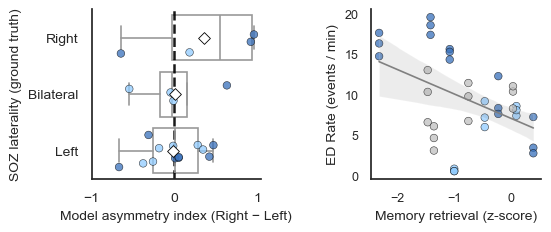

In [174]:
# 2 colors
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# --- סגנון ---
sns.set_context("notebook", font_scale=1.1)
sns.set_style("white")

# --- קריאת נתוני קוהורטות (משותף לשני הגרפים) ---
v1 = pd.read_csv('figures/V1.csv')
v2 = pd.read_csv('figures/V2.csv')
v1['subject'] = v1['subject'].astype(str).str.strip()
v2['subject'] = v2['subject'].astype(str).str.strip()

v1_subjects = set(v1['subject'].unique())
v2_subjects = set(v2['subject'].unique())

def cohort_of(subj):
    in_v1 = subj in v1_subjects
    in_v2 = subj in v2_subjects
    if in_v1 and not in_v2:
        return 'V1'
    if in_v2 and not in_v1:
        return 'V2'
    if in_v1 and in_v2:
        return 'V2'
    return 'Unknown'

# --- צבעים ושקיפות משותפים ---
palette_cohort = {
    'V1': '#90CCFF',
    'V2': '#3870bb',
    'Unknown': '#BFBFBF'
}
point_alpha = 0.75  # שקיפות אחידה
point_size = 30     # גודל אחיד (ב-scatter s=, ב-stripplot size= שונה)

# --- יצירת Figure עם שני subplots ---
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 2.4))
fig, (ax1, ax2) = plt.subplots(
    ncols=2, figsize=(5.8, 2.2),  # שני פאנלים קומפקטיים
    gridspec_kw={'wspace': 0.65}
)

# ========== גרף שמאל: Laterality ==========
df_lat = pd.read_csv('figures/laterality.csv')
df_lat['subject'] = df_lat['subject'].astype(str).str.strip()
df_lat['cohort'] = df_lat['subject'].map(cohort_of)

categories = ['Right', 'Bilateral', 'Left']
hue_order = ['V1', 'V2', 'Unknown'] if 'Unknown' in df_lat['cohort'].unique() else ['V1', 'V2']

sns.boxplot(
    data=df_lat,
    y='Zone Category', x='Asymmetry Index',
    order=categories,
    color='white', linewidth=1.2, showcaps=True, fliersize=0, ax=ax1
)

sns.stripplot(
    data=df_lat,
    y='Zone Category', x='Asymmetry Index',
    order=categories,
    hue='cohort', hue_order=hue_order,
    palette=palette_cohort,
    alpha=point_alpha, size=5.5, jitter=0.30, dodge=False,
    edgecolor='black', linewidth=0.4, ax=ax1
)

# ממוצעים
group_means = df_lat.groupby('Zone Category')['Asymmetry Index'].mean()
for i, category in enumerate(categories):
    mean_x = group_means.get(category, float('nan'))
    ax1.scatter(mean_x, i, color='white', edgecolor='black',
                marker='D', s=36, linewidth=0.6, zorder=5)

# קו 0
ax1.axvline(0, color='black', linestyle='--', linewidth=1.8, alpha=0.9)

# עיצוב
ax1.set_xlabel('Model asymmetry index (Right − Left)', fontsize=10)
ax1.set_ylabel('SOZ laterality (ground truth)', fontsize=10)
ax1.set_xlim(-1, 1.05)
ax1.set_xticks([-1, 0, 1])
ax1.tick_params(labelsize=10)
ax1.grid(False)
sns.despine(ax=ax1, top=True, right=True)
if ax1.get_legend():
    ax1.get_legend().remove()

# ========== גרף ימין: Correlation ==========
spikes_df = pd.read_csv('figures/V1_V2_combined_with_depth.csv')
cog_df = pd.read_csv('figures/EPI_Corr_with_depth.csv', encoding='cp1255')

spikes_df['subject'] = spikes_df['subject'].astype(str).str.strip()
cog_df['subject'] = cog_df['subject'].astype(str).str.strip()

var = 'יעילות שליפת המידע'
merged_df = pd.merge(
    spikes_df,
    cog_df[['subject', var]],
    on='subject',
    how='inner'
)

merged_df['cohort'] = merged_df['subject'].map(cohort_of)
hue_levels = ['V1', 'V2'] + (['Unknown'] if 'Unknown' in merged_df['cohort'].unique() else [])

# remove subject 025
merged_df = merged_df[merged_df['subject'] != 'D25'].copy()

# נקודות
sns.scatterplot(
    data=merged_df,
    x=var, y='Spikes_per_min',
    hue='cohort', hue_order=hue_levels,
    palette=palette_cohort,
    s=point_size, alpha=point_alpha,
    edgecolor='black', linewidth=0.4, legend=False,
    ax=ax2
)

# קו רגרסיה
sns.regplot(
    data=merged_df,
    x=var, y='Spikes_per_min',
    scatter=False,
    line_kws={'color': 'gray', 'linewidth': 1.2},
    ax=ax2
)

# עיצוב
ax2.set_xlabel('Memory retrieval (z-score)', fontsize=10)
ax2.set_ylabel('ED Rate (events / min)', fontsize=10)
ax2.tick_params(labelsize=9)
sns.despine(ax=ax2, top=True, right=True)

# --- שמירה ---
plt.tight_layout()
plt.show()

Pearson r = -0.171, p = 0.5760


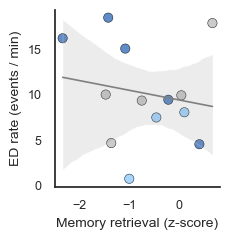

In [165]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# --- סגנון גרפי ---
sns.set_context("notebook", font_scale=1.1)
sns.set_style("white")

# --- קריאת קובצי הקוהורטות ---
v1 = pd.read_csv('figures/V1.csv')
v2 = pd.read_csv('figures/V2.csv')
v1['subject'] = v1['subject'].astype(str).str.strip()
v2['subject'] = v2['subject'].astype(str).str.strip()

v1_subjects = set(v1['subject'].unique())
v2_subjects = set(v2['subject'].unique())

def cohort_of(subj):
    in_v1 = subj in v1_subjects
    in_v2 = subj in v2_subjects
    if in_v1 and not in_v2:
        return 'V1'
    if in_v2 and not in_v1:
        return 'V2'
    if in_v1 and in_v2:
        return 'V2'
    return 'Unknown'

# --- קריאת הנתונים --- #
spikes_df = pd.read_csv('figures/V1_V2_combined_with_depth.csv')
cog_df = pd.read_csv('figures/EPI_Corr_with_depth.csv', encoding='cp1255')

spikes_df['subject'] = spikes_df['subject'].astype(str).str.strip()
cog_df['subject'] = cog_df['subject'].astype(str).str.strip()

# שם המשתנה הקוגניטיבי
var = 'יעילות שליפת המידע'

# מיזוג לפי subject
merged_df = pd.merge(
    spikes_df,
    cog_df[['subject', var]],
    on='subject',
    how='inner'
)

# 🔹 סינון שורות עם ערך חסר בעמודת היעילות
merged_df = merged_df[~merged_df[var].isna()].copy()

# הוספת קוהורטה
merged_df['cohort'] = merged_df['subject'].map(cohort_of)

# --- חישוב ממוצע לכל נבדק --- #
df_mean = merged_df.groupby(['subject', 'cohort'], as_index=False).agg({
    var: 'mean',
    'Spikes_per_min': 'mean'
})


# --- חישוב קורלציה --- #
r, p = pearsonr(df_mean[var], df_mean['Spikes_per_min'])
print(f"Pearson r = {r:.3f}, p = {p:.4f}")

# --- גרף --- #
palette_cohort = {'V1': '#90CCFF', 'V2': '#3870bb', 'Unknown': '#BFBFBF'}

fig, ax = plt.subplots(figsize=(2.6, 2.6))

sns.scatterplot(
    data=df_mean,
    x=var, y='Spikes_per_min',
    hue='cohort', palette=palette_cohort,
    s=45, alpha=0.8, edgecolor='black', linewidth=0.4, ax=ax, legend=False
)

sns.regplot(
    data=df_mean,
    x=var, y='Spikes_per_min',
    scatter=False,
    line_kws={'color': 'gray', 'linewidth': 1.2},
    ax=ax
)

# --- עיצוב --- #
ax.set_xlabel('Memory retrieval (z-score)', fontsize=10)
ax.set_ylabel('ED rate (events / min)', fontsize=10)
ax.tick_params(labelsize=9)
sns.despine(ax=ax, top=True, right=True)

plt.tight_layout()
plt.show()


Pearson r = -0.465, p = 0.1279


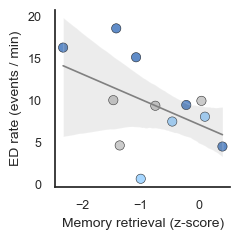

In [175]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# --- סגנון גרפי ---
sns.set_context("notebook", font_scale=1.1)
sns.set_style("white")

# --- קריאת קובצי הקוהורטות ---
v1 = pd.read_csv('figures/V1.csv')
v2 = pd.read_csv('figures/V2.csv')
v1['subject'] = v1['subject'].astype(str).str.strip()
v2['subject'] = v2['subject'].astype(str).str.strip()

v1_subjects = set(v1['subject'].unique())
v2_subjects = set(v2['subject'].unique())

def cohort_of(subj):
    in_v1 = subj in v1_subjects
    in_v2 = subj in v2_subjects
    if in_v1 and not in_v2:
        return 'V1'
    if in_v2 and not in_v1:
        return 'V2'
    if in_v1 and in_v2:
        return 'V2'
    return 'Unknown'

# --- קריאת הנתונים --- #
spikes_df = pd.read_csv('figures/V1_V2_combined_with_depth.csv')
cog_df = pd.read_csv('figures/EPI_Corr_with_depth.csv', encoding='cp1255')

spikes_df['subject'] = spikes_df['subject'].astype(str).str.strip()
cog_df['subject'] = cog_df['subject'].astype(str).str.strip()

# שם המשתנה הקוגניטיבי
var = 'יעילות שליפת המידע'

# מיזוג לפי subject
merged_df = pd.merge(
    spikes_df,
    cog_df[['subject', var]],
    on='subject',
    how='inner'
)

# 🔹 סינון שורות עם ערך חסר בעמודת היעילות
merged_df = merged_df[~merged_df[var].isna()].copy()

# הוספת קוהורטה
merged_df['cohort'] = merged_df['subject'].map(cohort_of)

# --- חישוב ממוצע לכל נבדק --- #
df_mean = merged_df.groupby(['subject', 'cohort'], as_index=False).agg({
    var: 'mean',
    'Spikes_per_min': 'mean'
})

# remove subject 025
df_mean = df_mean[df_mean['subject'] != 'D25'].copy()

# --- חישוב קורלציה --- #
r, p = pearsonr(df_mean[var], df_mean['Spikes_per_min'])
print(f"Pearson r = {r:.3f}, p = {p:.4f}")

# --- גרף --- #
palette_cohort = {'V1': '#90CCFF', 'V2': '#3870bb', 'Unknown': '#BFBFBF'}

fig, ax = plt.subplots(figsize=(2.6, 2.6))

sns.scatterplot(
    data=df_mean,
    x=var, y='Spikes_per_min',
    hue='cohort', palette=palette_cohort,
    s=45, alpha=0.8, edgecolor='black', linewidth=0.4, ax=ax, legend=False
)

sns.regplot(
    data=df_mean,
    x=var, y='Spikes_per_min',
    scatter=False,
    line_kws={'color': 'gray', 'linewidth': 1.2},
    ax=ax
)

# --- עיצוב --- #
ax.set_xlabel('Memory retrieval (z-score)', fontsize=10)
ax.set_ylabel('ED rate (events / min)', fontsize=10)
ax.tick_params(labelsize=9)
sns.despine(ax=ax, top=True, right=True)

plt.tight_layout()
plt.show()

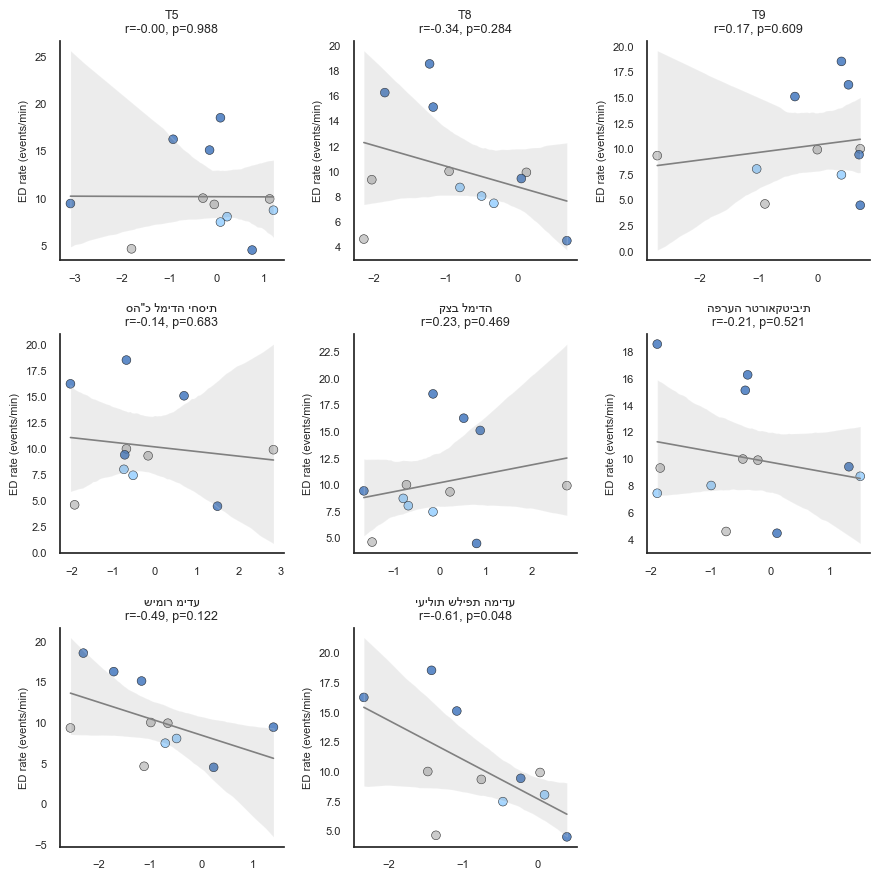

             Variable         r         p
0                  T5 -0.004995  0.987707
1                  T8 -0.337315  0.283611
2                  T9  0.174121  0.608626
3    סה"כ למידה יחסית -0.139238  0.683050
4           קצב למידה  0.231590  0.468911
5   הפרעה רטרואקטיבית -0.205620  0.521443
6          שימור מידע -0.494044  0.122444
7  יעילות שליפת המידע -0.605469  0.048380


In [183]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import numpy as np

# --- סגנון גרפי --- #
sns.set_context("notebook", font_scale=1.1)
sns.set_style("white")

# --- קריאת קובצי הקוהורטות --- #
v1 = pd.read_csv('figures/V1.csv')
v2 = pd.read_csv('figures/V2.csv')
v1['subject'] = v1['subject'].astype(str).str.strip()
v2['subject'] = v2['subject'].astype(str).str.strip()

v1_subjects = set(v1['subject'].unique())
v2_subjects = set(v2['subject'].unique())

def cohort_of(subj):
    in_v1 = subj in v1_subjects
    in_v2 = subj in v2_subjects
    if in_v1 and not in_v2:
        return 'V1'
    if in_v2 and not in_v1:
        return 'V2'
    if in_v1 and in_v2:
        return 'V2'
    return 'Unknown'

# --- קריאת הנתונים --- #
spikes_df = pd.read_csv('figures/V1_V2_combined_with_depth.csv')
cog_df = pd.read_csv('figures/EPI_Corr_with_depth.csv', encoding='cp1255')

spikes_df['subject'] = spikes_df['subject'].astype(str).str.strip()
cog_df['subject'] = cog_df['subject'].astype(str).str.strip()

# --- רשימת המשתנים הקוגניטיביים לבדיקה --- #
cog_vars = [col for col in cog_df.columns if col != 'subject']

# --- הגדרת פלטת צבעים --- #
palette_cohort = {'V1': '#90CCFF', 'V2': '#3870bb', 'Unknown': '#BFBFBF'}

# --- גריד של פאנלים --- #
n_vars = len(cog_vars)
ncols = 3
nrows = int(np.ceil(n_vars / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(3*ncols, 3*nrows))
axes = axes.flatten()

results = []

for i, var in enumerate(cog_vars):
    # מיזוג לפי subject
    merged_df = pd.merge(
        spikes_df,
        cog_df[['subject', var]],
        on='subject',
        how='inner'
    )
    
    # merged_df = merged_df[merged_df['subject'] != 'SS1']
    # סינון ערכים חסרים
    merged_df = merged_df[~merged_df[var].isna()].copy()

    # הוספת קוהורטה
    merged_df['cohort'] = merged_df['subject'].map(cohort_of)

    # ממוצע לכל נבדק
    df_mean = merged_df.groupby(['subject', 'cohort'], as_index=False).agg({
        var: 'mean',
        'Spikes_per_min': 'mean'
    })

    # חישוב קורלציה
    if df_mean[var].nunique() > 1:
        r, p = pearsonr(df_mean[var], df_mean['Spikes_per_min'])
    else:
        r, p = np.nan, np.nan
    results.append((var, r, p))

    ax = axes[i]
    sns.scatterplot(
        data=df_mean,
        x=var, y='Spikes_per_min',
        hue='cohort', palette=palette_cohort,
        s=40, alpha=0.8, edgecolor='black', linewidth=0.4, ax=ax, legend=False
    )
    sns.regplot(
        data=df_mean,
        x=var, y='Spikes_per_min',
        scatter=False,
        line_kws={'color': 'gray', 'linewidth': 1.2},
        ax=ax
    )

    ax.set_title(f"{var}\nr={r:.2f}, p={p:.3f}", fontsize=9)
    ax.set_xlabel('')
    ax.set_ylabel('ED rate (events/min)', fontsize=8)
    ax.tick_params(labelsize=8)
    sns.despine(ax=ax, top=True, right=True)

# הסרת פאנלים ריקים
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# --- הדפסת תוצאות המתאם --- #
res_df = pd.DataFrame(results, columns=['Variable', 'r', 'p'])
print(res_df)

[Correlation on subject means] r = -0.6253, p = 0.0973, n = 8


C:\Users\user\AppData\Local\Temp\ipykernel_10800\1464787871.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


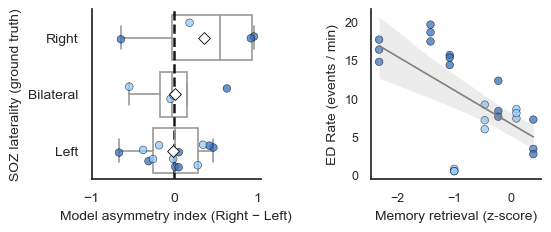

In [177]:
# 2 colors
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# --- סגנון ---
sns.set_context("notebook", font_scale=1.1)
sns.set_style("white")

# --- קריאת נתוני קוהורטות (משותף לשני הגרפים) ---
v1 = pd.read_csv('figures/V1.csv')
v2 = pd.read_csv('figures/V2.csv')
v1['subject'] = v1['subject'].astype(str).str.strip()
v2['subject'] = v2['subject'].astype(str).str.strip()

v1_subjects = set(v1['subject'].unique())
v2_subjects = set(v2['subject'].unique())

def cohort_of(subj):
    in_v1 = subj in v1_subjects
    in_v2 = subj in v2_subjects
    if in_v1 and not in_v2:
        return 'V1'
    if in_v2 and not in_v1:
        return 'V2'
    if in_v1 and in_v2:
        return 'V2'
    return 'Unknown'

# --- צבעים ושקיפות משותפים ---
palette_cohort = {
    'V1': '#90CCFF',
    'V2': '#3870bb',
    'Unknown': '#BFBFBF'
}
point_alpha = 0.75  # שקיפות אחידה
point_size = 30     # גודל אחיד (ב-scatter s=, ב-stripplot size= שונה)

# --- יצירת Figure עם שני subplots ---
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 2.4))
fig, (ax1, ax2) = plt.subplots(
    ncols=2, figsize=(5.8, 2.2),  # שני פאנלים קומפקטיים
    gridspec_kw={'wspace': 0.65}
)

# ========== גרף שמאל: Laterality ==========
df_lat = pd.read_csv('figures/laterality.csv')
df_lat['subject'] = df_lat['subject'].astype(str).str.strip()
df_lat['cohort'] = df_lat['subject'].map(cohort_of)

categories = ['Right', 'Bilateral', 'Left']
hue_order = ['V1', 'V2', 'Unknown'] if 'Unknown' in df_lat['cohort'].unique() else ['V1', 'V2']

sns.boxplot(
    data=df_lat,
    y='Zone Category', x='Asymmetry Index',
    order=categories,
    color='white', linewidth=1.2, showcaps=True, fliersize=0, ax=ax1
)

sns.stripplot(
    data=df_lat,
    y='Zone Category', x='Asymmetry Index',
    order=categories,
    hue='cohort', hue_order=hue_order,
    palette=palette_cohort,
    alpha=point_alpha, size=5.5, jitter=0.30, dodge=False,
    edgecolor='black', linewidth=0.4, ax=ax1
)

# ממוצעים
group_means = df_lat.groupby('Zone Category')['Asymmetry Index'].mean()
for i, category in enumerate(categories):
    mean_x = group_means.get(category, float('nan'))
    ax1.scatter(mean_x, i, color='white', edgecolor='black',
                marker='D', s=36, linewidth=0.6, zorder=5)

# קו 0
ax1.axvline(0, color='black', linestyle='--', linewidth=1.8, alpha=0.9)

# עיצוב
ax1.set_xlabel('Model asymmetry index (Right − Left)', fontsize=10)
ax1.set_ylabel('SOZ laterality (ground truth)', fontsize=10)
ax1.set_xlim(-1, 1.05)
ax1.set_xticks([-1, 0, 1])
ax1.tick_params(labelsize=10)
ax1.grid(False)
sns.despine(ax=ax1, top=True, right=True)
if ax1.get_legend():
    ax1.get_legend().remove()

# ========== גרף ימין: Correlation ==========
spikes_df = pd.read_csv('figures/V1_V2_combined.csv')
cog_df    = pd.read_csv('figures/EPI_Corr.csv', encoding='cp1255')

spikes_df['subject'] = spikes_df['subject'].astype(str).str.strip()
cog_df['subject']    = cog_df['subject'].astype(str).str.strip()

var = 'יעילות שליפת המידע'
merged_df = pd.merge(
    spikes_df,
    cog_df[['subject', var]],
    on='subject',
    how='inner'
).dropna(subset=['subject', 'Spikes_per_min', var])

# שיוך קוהורטות לכל דגימה (לצבע בגרף)
merged_df['cohort'] = merged_df['subject'].map(cohort_of)
hue_levels = ['V1', 'V2'] + (['Unknown'] if 'Unknown' in merged_df['cohort'].unique() else [])

# --- גרף: כל הדגימות ---
sns.scatterplot(
    data=merged_df,
    x=var, y='Spikes_per_min',
    hue='cohort', hue_order=hue_levels,
    palette=palette_cohort,
    s=point_size, alpha=point_alpha,
    edgecolor='black', linewidth=0.4, legend=False,
    ax=ax2
)

# (אופציונלי) קו רגרסיה על כל הדגימות – להשאיר ויזואלית בלבד
sns.regplot(
    data=merged_df,
    x=var, y='Spikes_per_min',
    scatter=False,
    line_kws={'color': 'gray', 'linewidth': 1.2},
    ax=ax2
)

# --- קורלציה: רק על ממוצעים לנבדק (מודפס לקונסול בלבד) ---
subj_means = (
    merged_df.groupby('subject', as_index=False)
             .agg(Spikes_per_min=('Spikes_per_min', 'mean'),
                  **{var: (var, 'mean')})
)

# סינון בטיחותי ונטרול מקרים דגנרטיביים
import numpy as np
x = subj_means[var].to_numpy()
y = subj_means['Spikes_per_min'].to_numpy()
mask = np.isfinite(x) & np.isfinite(y)

if mask.sum() >= 2 and np.std(x[mask]) > 0 and np.std(y[mask]) > 0:
    r, p = pearsonr(x[mask], y[mask])
    print(f"[Correlation on subject means] r = {r:.4f}, p = {p:.4g}, n = {mask.sum()}")
else:
    print(f"[Correlation on subject means] insufficient/constant data (n = {mask.sum()})")

# עיצוב
ax2.set_xlabel('Memory retrieval (z-score)', fontsize=10)
ax2.set_ylabel('ED Rate (events / min)', fontsize=10)
ax2.tick_params(labelsize=9)
sns.despine(ax=ax2, top=True, right=True)


# --- שמירה ---
plt.tight_layout()
plt.show()

In [178]:

# === סטטיסטיקה: LMM + Repeated-Measures Correlation ===
import numpy as np
import pandas as pd

# 1) להכין DF מודלי עם שם עמודה סטנדרטי ולוודא נומריקה
model_df = (
    merged_df
      .rename(columns={var: 'retrieval_efficiency'})  # var='יעילות שליפת המידע'
      .loc[:, ['subject', 'Spikes_per_min', 'retrieval_efficiency']]
      .copy()
)

# להמיר לנומרי ולהפיל NaN
model_df['Spikes_per_min'] = pd.to_numeric(model_df['Spikes_per_min'], errors='coerce')
model_df['retrieval_efficiency'] = pd.to_numeric(model_df['retrieval_efficiency'], errors='coerce')
model_df = model_df.dropna(subset=['subject', 'Spikes_per_min', 'retrieval_efficiency'])

# ליתר בטחון: subject כמחרוזת
model_df['subject'] = model_df['subject'].astype(str).str.strip()

# 2) Mixed Effects Model: רנדום-אינטרספט לפי subject
import statsmodels.formula.api as smf

# ננסה התאמה; אם יש אזהרות קונברגנציה – ננסה method='lbfgs'
try:
    result = smf.mixedlm(
        "Spikes_per_min ~ retrieval_efficiency",
        data=model_df,
        groups="subject",
        re_formula="1"
    ).fit(reml=True)
except Exception as e:
    print("[MixedLM] First try failed, retrying with lbfgs. Details:", str(e))
    result = smf.mixedlm(
        "Spikes_per_min ~ retrieval_efficiency",
        data=model_df,
        groups="subject",
        re_formula="1"
    ).fit(method='lbfgs', reml=True)

# מקדמים, טעויות תקן, סטטיסטיקות
beta1 = result.params.get('retrieval_efficiency', np.nan)
se1   = result.bse.get('retrieval_efficiency', np.nan)
z1    = result.tvalues.get('retrieval_efficiency', np.nan)  # ב-MixedLM זה נקרא tvalues אך מתנהג כ-z במודל לינארי
p1    = result.pvalues.get('retrieval_efficiency', np.nan)

# 3) R^2 (Nakagawa): מרג'ינלי וקונדישנלי — תיקון y_fixed באמצעות exog @ fe_params
import numpy as np

# חיזוי מהאפקטים הקבועים בלבד (Fixed effects only)
X = result.model.exog                  # מטריצת העיצוב של האפקטים הקבועים
beta = result.fe_params                # וקטור המקדמים של האפקטים הקבועים
y_fixed = np.asarray(X @ beta)         # תחזית ללא רנדום-אינטרספט

var_fixed = np.var(y_fixed, ddof=1)

# וריאנס הרכיב הרנדומי (רנדום-אינטרספט) — עבור מודל עם רכיב רנדומי יחיד
try:
    var_random = float(result.cov_re.iloc[0, 0])
except Exception:
    var_random = float(np.squeeze(np.asarray(result.cov_re)))

# וריאנס שיורי (Scale = σ^2)
var_resid = float(result.scale)

R2_marg = var_fixed / (var_fixed + var_random + var_resid)
R2_cond = (var_fixed + var_random) / (var_fixed + var_random + var_resid)

print(f"Mixed model: β = {beta.get('retrieval_efficiency', np.nan):.2f}, "
      f"SE = {result.bse.get('retrieval_efficiency', np.nan):.2f}, "
      f"z = {result.tvalues.get('retrieval_efficiency', np.nan):.2f}, "
      f"p = {result.pvalues.get('retrieval_efficiency', np.nan):.4g}")
print(f"R² (marginal) = {R2_marg:.3f}, R² (conditional) = {R2_cond:.3f}")


# 4) Repeated-measures correlation (Pingouin)
try:
    import pingouin as pg
    rm = pg.rm_corr(data=model_df, x='retrieval_efficiency', y='Spikes_per_min', subject='subject')
    # הדפסה נעימה
    r_rm   = float(rm['r'].iat[0])
    p_rm   = float(rm['pval'].iat[0])
    ci_rm  = rm['CI95%'].iat[0]  # מחרוזת כמו "[low, high]"
    print(f"Repeated-measures correlation: r_rm = {r_rm:.2f}, 95% CI {ci_rm}, p = {p_rm:.3g}")
except ImportError:
    print("pingouin לא מותקן (pip install pingouin) — מדלגים על rmcorr.")


Mixed model: β = -4.34, SE = 2.21, z = -1.96, p = 0.04965
R² (marginal) = 0.322, R² (conditional) = 0.944
Repeated-measures correlation: r_rm = -0.80, 95% CI [-0.92, -0.53], p = 6.47e-05


[Correlation on subject means] r = -0.4648, p = 0.1279, n = 12


C:\Users\user\AppData\Local\Temp\ipykernel_10800\3147646199.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


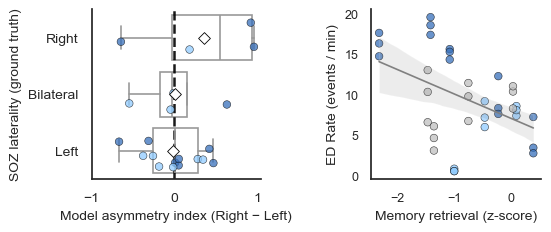

In [179]:
# 2 colors
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# --- סגנון ---
sns.set_context("notebook", font_scale=1.1)
sns.set_style("white")

# --- קריאת נתוני קוהורטות (משותף לשני הגרפים) ---
v1 = pd.read_csv('figures/V1.csv')
v2 = pd.read_csv('figures/V2.csv')
v1['subject'] = v1['subject'].astype(str).str.strip()
v2['subject'] = v2['subject'].astype(str).str.strip()

v1_subjects = set(v1['subject'].unique())
v2_subjects = set(v2['subject'].unique())

def cohort_of(subj):
    in_v1 = subj in v1_subjects
    in_v2 = subj in v2_subjects
    if in_v1 and not in_v2:
        return 'V1'
    if in_v2 and not in_v1:
        return 'V2'
    if in_v1 and in_v2:
        return 'V2'
    return 'Unknown'

# --- צבעים ושקיפות משותפים ---
palette_cohort = {
    'V1': '#90CCFF',
    'V2': '#3870bb',
    'Unknown': '#BFBFBF'
}
point_alpha = 0.75  # שקיפות אחידה
point_size = 30     # גודל אחיד (ב-scatter s=, ב-stripplot size= שונה)

# --- יצירת Figure עם שני subplots ---
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 2.4))
fig, (ax1, ax2) = plt.subplots(
    ncols=2, figsize=(5.8, 2.2),  # שני פאנלים קומפקטיים
    gridspec_kw={'wspace': 0.65}
)

# ========== גרף שמאל: Laterality ==========
df_lat = pd.read_csv('figures/laterality.csv')
df_lat['subject'] = df_lat['subject'].astype(str).str.strip()
df_lat['cohort'] = df_lat['subject'].map(cohort_of)

categories = ['Right', 'Bilateral', 'Left']
hue_order = ['V1', 'V2', 'Unknown'] if 'Unknown' in df_lat['cohort'].unique() else ['V1', 'V2']

sns.boxplot(
    data=df_lat,
    y='Zone Category', x='Asymmetry Index',
    order=categories,
    color='white', linewidth=1.2, showcaps=True, fliersize=0, ax=ax1
)

sns.stripplot(
    data=df_lat,
    y='Zone Category', x='Asymmetry Index',
    order=categories,
    hue='cohort', hue_order=hue_order,
    palette=palette_cohort,
    alpha=point_alpha, size=5.5, jitter=0.30, dodge=False,
    edgecolor='black', linewidth=0.4, ax=ax1
)

# ממוצעים
group_means = df_lat.groupby('Zone Category')['Asymmetry Index'].mean()
for i, category in enumerate(categories):
    mean_x = group_means.get(category, float('nan'))
    ax1.scatter(mean_x, i, color='white', edgecolor='black',
                marker='D', s=36, linewidth=0.6, zorder=5)

# קו 0
ax1.axvline(0, color='black', linestyle='--', linewidth=1.8, alpha=0.9)

# עיצוב
ax1.set_xlabel('Model asymmetry index (Right − Left)', fontsize=10)
ax1.set_ylabel('SOZ laterality (ground truth)', fontsize=10)
ax1.set_xlim(-1, 1.05)
ax1.set_xticks([-1, 0, 1])
ax1.tick_params(labelsize=10)
ax1.grid(False)
sns.despine(ax=ax1, top=True, right=True)
if ax1.get_legend():
    ax1.get_legend().remove()

# ========== גרף ימין: Correlation ==========
spikes_df = pd.read_csv('figures/V1_V2_combined_with_depth.csv')
cog_df    = pd.read_csv('figures/EPI_Corr_with_depth.csv', encoding='cp1255')

spikes_df['subject'] = spikes_df['subject'].astype(str).str.strip()
cog_df['subject']    = cog_df['subject'].astype(str).str.strip()

var = 'יעילות שליפת המידע'
merged_df = pd.merge(
    spikes_df,
    cog_df[['subject', var]],
    on='subject',
    how='inner'
).dropna(subset=['subject', 'Spikes_per_min', var])

# שיוך קוהורטות לכל דגימה (לצבע בגרף)
merged_df['cohort'] = merged_df['subject'].map(cohort_of)
hue_levels = ['V1', 'V2'] + (['Unknown'] if 'Unknown' in merged_df['cohort'].unique() else [])

# --- גרף: כל הדגימות ---
sns.scatterplot(
    data=merged_df,
    x=var, y='Spikes_per_min',
    hue='cohort', hue_order=hue_levels,
    palette=palette_cohort,
    s=point_size, alpha=point_alpha,
    edgecolor='black', linewidth=0.4, legend=False,
    ax=ax2
)

# (אופציונלי) קו רגרסיה על כל הדגימות – להשאיר ויזואלית בלבד
sns.regplot(
    data=merged_df,
    x=var, y='Spikes_per_min',
    scatter=False,
    line_kws={'color': 'gray', 'linewidth': 1.2},
    ax=ax2
)

# --- קורלציה: רק על ממוצעים לנבדק (מודפס לקונסול בלבד) ---
subj_means = (
    merged_df.groupby('subject', as_index=False)
             .agg(Spikes_per_min=('Spikes_per_min', 'mean'),
                  **{var: (var, 'mean')})
)

# סינון בטיחותי ונטרול מקרים דגנרטיביים
import numpy as np
x = subj_means[var].to_numpy()
y = subj_means['Spikes_per_min'].to_numpy()
mask = np.isfinite(x) & np.isfinite(y)

if mask.sum() >= 2 and np.std(x[mask]) > 0 and np.std(y[mask]) > 0:
    r, p = pearsonr(x[mask], y[mask])
    print(f"[Correlation on subject means] r = {r:.4f}, p = {p:.4g}, n = {mask.sum()}")
else:
    print(f"[Correlation on subject means] insufficient/constant data (n = {mask.sum()})")

# עיצוב
ax2.set_xlabel('Memory retrieval (z-score)', fontsize=10)
ax2.set_ylabel('ED Rate (events / min)', fontsize=10)
ax2.tick_params(labelsize=9)
sns.despine(ax=ax2, top=True, right=True)


# --- שמירה ---
plt.tight_layout()
plt.show()

[Correlation on subject means] r = -0.6055, p = 0.04838, n = 11


C:\Users\user\AppData\Local\Temp\ipykernel_10800\958142915.py:161: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


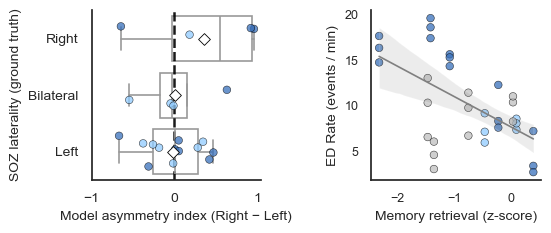

In [184]:
# 2 colors
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# --- סגנון ---
sns.set_context("notebook", font_scale=1.1)
sns.set_style("white")

# --- קריאת נתוני קוהורטות (משותף לשני הגרפים) ---
v1 = pd.read_csv('figures/V1.csv')
v2 = pd.read_csv('figures/V2.csv')
v1['subject'] = v1['subject'].astype(str).str.strip()
v2['subject'] = v2['subject'].astype(str).str.strip()

v1_subjects = set(v1['subject'].unique())
v2_subjects = set(v2['subject'].unique())

def cohort_of(subj):
    in_v1 = subj in v1_subjects
    in_v2 = subj in v2_subjects
    if in_v1 and not in_v2:
        return 'V1'
    if in_v2 and not in_v1:
        return 'V2'
    if in_v1 and in_v2:
        return 'V2'
    return 'Unknown'

# --- צבעים ושקיפות משותפים ---
palette_cohort = {
    'V1': '#90CCFF',
    'V2': '#3870bb',
    'Unknown': '#BFBFBF'
}
point_alpha = 0.75  # שקיפות אחידה
point_size = 30     # גודל אחיד (ב-scatter s=, ב-stripplot size= שונה)

# --- יצירת Figure עם שני subplots ---
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 2.4))
fig, (ax1, ax2) = plt.subplots(
    ncols=2, figsize=(5.8, 2.2),  # שני פאנלים קומפקטיים
    gridspec_kw={'wspace': 0.65}
)

# ========== גרף שמאל: Laterality ==========
df_lat = pd.read_csv('figures/laterality.csv')
df_lat['subject'] = df_lat['subject'].astype(str).str.strip()
df_lat['cohort'] = df_lat['subject'].map(cohort_of)

categories = ['Right', 'Bilateral', 'Left']
hue_order = ['V1', 'V2', 'Unknown'] if 'Unknown' in df_lat['cohort'].unique() else ['V1', 'V2']

sns.boxplot(
    data=df_lat,
    y='Zone Category', x='Asymmetry Index',
    order=categories,
    color='white', linewidth=1.2, showcaps=True, fliersize=0, ax=ax1
)

sns.stripplot(
    data=df_lat,
    y='Zone Category', x='Asymmetry Index',
    order=categories,
    hue='cohort', hue_order=hue_order,
    palette=palette_cohort,
    alpha=point_alpha, size=5.5, jitter=0.30, dodge=False,
    edgecolor='black', linewidth=0.4, ax=ax1
)

# ממוצעים
group_means = df_lat.groupby('Zone Category')['Asymmetry Index'].mean()
for i, category in enumerate(categories):
    mean_x = group_means.get(category, float('nan'))
    ax1.scatter(mean_x, i, color='white', edgecolor='black',
                marker='D', s=36, linewidth=0.6, zorder=5)

# קו 0
ax1.axvline(0, color='black', linestyle='--', linewidth=1.8, alpha=0.9)

# עיצוב
ax1.set_xlabel('Model asymmetry index (Right − Left)', fontsize=10)
ax1.set_ylabel('SOZ laterality (ground truth)', fontsize=10)
ax1.set_xlim(-1, 1.05)
ax1.set_xticks([-1, 0, 1])
ax1.tick_params(labelsize=10)
ax1.grid(False)
sns.despine(ax=ax1, top=True, right=True)
if ax1.get_legend():
    ax1.get_legend().remove()

# ========== גרף ימין: Correlation ==========
spikes_df = pd.read_csv('figures/V1_V2_combined_with_depth.csv')
cog_df    = pd.read_csv('figures/EPI_Corr_with_depth.csv', encoding='cp1255')

spikes_df['subject'] = spikes_df['subject'].astype(str).str.strip()
cog_df['subject']    = cog_df['subject'].astype(str).str.strip()

var = 'יעילות שליפת המידע'
merged_df = pd.merge(
    spikes_df,
    cog_df[['subject', var]],
    on='subject',
    how='inner'
).dropna(subset=['subject', 'Spikes_per_min', var])

# שיוך קוהורטות לכל דגימה (לצבע בגרף)
merged_df['cohort'] = merged_df['subject'].map(cohort_of)
hue_levels = ['V1', 'V2'] + (['Unknown'] if 'Unknown' in merged_df['cohort'].unique() else [])

# remove subject SS1
merged_df = merged_df[merged_df['subject'] != 'SS1']
# --- גרף: כל הדגימות ---
sns.scatterplot(
    data=merged_df,
    x=var, y='Spikes_per_min',
    hue='cohort', hue_order=hue_levels,
    palette=palette_cohort,
    s=point_size, alpha=point_alpha,
    edgecolor='black', linewidth=0.4, legend=False,
    ax=ax2
)

# (אופציונלי) קו רגרסיה על כל הדגימות – להשאיר ויזואלית בלבד
sns.regplot(
    data=merged_df,
    x=var, y='Spikes_per_min',
    scatter=False,
    line_kws={'color': 'gray', 'linewidth': 1.2},
    ax=ax2
)

# --- קורלציה: רק על ממוצעים לנבדק (מודפס לקונסול בלבד) ---
subj_means = (
    merged_df.groupby('subject', as_index=False)
             .agg(Spikes_per_min=('Spikes_per_min', 'mean'),
                  **{var: (var, 'mean')})
)

# סינון בטיחותי ונטרול מקרים דגנרטיביים
import numpy as np
x = subj_means[var].to_numpy()
y = subj_means['Spikes_per_min'].to_numpy()
mask = np.isfinite(x) & np.isfinite(y)

if mask.sum() >= 2 and np.std(x[mask]) > 0 and np.std(y[mask]) > 0:
    r, p = pearsonr(x[mask], y[mask])
    print(f"[Correlation on subject means] r = {r:.4f}, p = {p:.4g}, n = {mask.sum()}")
else:
    print(f"[Correlation on subject means] insufficient/constant data (n = {mask.sum()})")

# עיצוב
ax2.set_xlabel('Memory retrieval (z-score)', fontsize=10)
ax2.set_ylabel('ED Rate (events / min)', fontsize=10)
ax2.tick_params(labelsize=9)
sns.despine(ax=ax2, top=True, right=True)


# --- שמירה ---
plt.tight_layout()
plt.show()

In [182]:

# === סטטיסטיקה: LMM + Repeated-Measures Correlation ===
import numpy as np
import pandas as pd

# 1) להכין DF מודלי עם שם עמודה סטנדרטי ולוודא נומריקה
model_df = (
    merged_df
      .rename(columns={var: 'retrieval_efficiency'})  # var='יעילות שליפת המידע'
      .loc[:, ['subject', 'Spikes_per_min', 'retrieval_efficiency']]
      .copy()
)

# להמיר לנומרי ולהפיל NaN
model_df['Spikes_per_min'] = pd.to_numeric(model_df['Spikes_per_min'], errors='coerce')
model_df['retrieval_efficiency'] = pd.to_numeric(model_df['retrieval_efficiency'], errors='coerce')
model_df = model_df.dropna(subset=['subject', 'Spikes_per_min', 'retrieval_efficiency'])

# ליתר בטחון: subject כמחרוזת
model_df['subject'] = model_df['subject'].astype(str).str.strip()
# remove subject MF7
# model_df = model_df[model_df['subject'] != 'SS1']

# 2) Mixed Effects Model: רנדום-אינטרספט לפי subject
import statsmodels.formula.api as smf

# ננסה התאמה; אם יש אזהרות קונברגנציה – ננסה method='lbfgs'
try:
    result = smf.mixedlm(
        "Spikes_per_min ~ retrieval_efficiency",
        data=model_df,
        groups="subject",
        re_formula="1"
    ).fit(reml=True)
except Exception as e:
    print("[MixedLM] First try failed, retrying with lbfgs. Details:", str(e))
    result = smf.mixedlm(
        "Spikes_per_min ~ retrieval_efficiency",
        data=model_df,
        groups="subject",
        re_formula="1"
    ).fit(method='lbfgs', reml=True)

# מקדמים, טעויות תקן, סטטיסטיקות
beta1 = result.params.get('retrieval_efficiency', np.nan)
se1   = result.bse.get('retrieval_efficiency', np.nan)
z1    = result.tvalues.get('retrieval_efficiency', np.nan)  # ב-MixedLM זה נקרא tvalues אך מתנהג כ-z במודל לינארי
p1    = result.pvalues.get('retrieval_efficiency', np.nan)

# 3) R^2 (Nakagawa): מרג'ינלי וקונדישנלי — תיקון y_fixed באמצעות exog @ fe_params
import numpy as np

# חיזוי מהאפקטים הקבועים בלבד (Fixed effects only)
X = result.model.exog                  # מטריצת העיצוב של האפקטים הקבועים
beta = result.fe_params                # וקטור המקדמים של האפקטים הקבועים
y_fixed = np.asarray(X @ beta)         # תחזית ללא רנדום-אינטרספט

var_fixed = np.var(y_fixed, ddof=1)

# וריאנס הרכיב הרנדומי (רנדום-אינטרספט) — עבור מודל עם רכיב רנדומי יחיד
try:
    var_random = float(result.cov_re.iloc[0, 0])
except Exception:
    var_random = float(np.squeeze(np.asarray(result.cov_re)))

# וריאנס שיורי (Scale = σ^2)
var_resid = float(result.scale)

R2_marg = var_fixed / (var_fixed + var_random + var_resid)
R2_cond = (var_fixed + var_random) / (var_fixed + var_random + var_resid)

print(f"Mixed model: β = {beta.get('retrieval_efficiency', np.nan):.2f}, "
      f"SE = {result.bse.get('retrieval_efficiency', np.nan):.2f}, "
      f"z = {result.tvalues.get('retrieval_efficiency', np.nan):.2f}, "
      f"p = {result.pvalues.get('retrieval_efficiency', np.nan):.4g}")
print(f"R² (marginal) = {R2_marg:.3f}, R² (conditional) = {R2_cond:.3f}")


# 4) Repeated-measures correlation (Pingouin)
try:
    import pingouin as pg
    rm = pg.rm_corr(data=model_df, x='retrieval_efficiency', y='Spikes_per_min', subject='subject')
    # הדפסה נעימה
    r_rm   = float(rm['r'].iat[0])
    p_rm   = float(rm['pval'].iat[0])
    ci_rm  = rm['CI95%'].iat[0]  # מחרוזת כמו "[low, high]"
    print(f"Repeated-measures correlation: r_rm = {r_rm:.2f}, 95% CI {ci_rm}, p = {p_rm:.3g}")
except ImportError:
    print("pingouin לא מותקן (pip install pingouin) — מדלגים על rmcorr.")


Mixed model: β = -3.30, SE = 1.45, z = -2.28, p = 0.02247
R² (marginal) = 0.296, R² (conditional) = 0.852
Repeated-measures correlation: r_rm = -0.46, 95% CI [-0.73, -0.07], p = 0.0238


Columns in CSV: ['subject', 'Left SPM', 'Right SPM', 'Asymmetry Index', 'Seizure Onset Zone', 'Zone Category', 'Temporal', '0.1', 'Unnamed: 8', 'exclusion', '0.05', 'Unnamed: 11', 'exclusion.1', 'memory']
Pearson correlation: r = 0.279, p = 5.031e-01


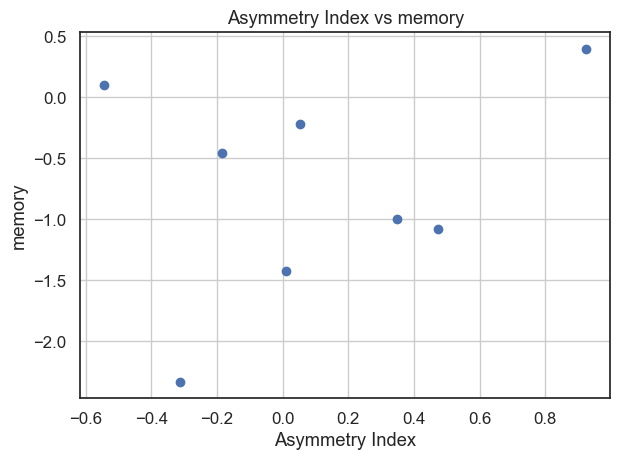

In [185]:
import pandas as pd
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

# Load the data
path = "figures/try_left_Ray.csv"  # adjust if needed
df = pd.read_csv(path)

# Columns of interest
col_x = "Asymmetry Index"
col_y = "memory"

# Check if columns exist
print("Columns in CSV:", df.columns.tolist())
if col_x not in df.columns or col_y not in df.columns:
    raise ValueError(f"One or both columns not found: {col_x}, {col_y}")

# Drop rows with NaN values for these columns
df_clean = df[[col_x, col_y]].dropna()

# Pearson correlation
corr, pval = pearsonr(df_clean[col_x], df_clean[col_y])
print(f"Pearson correlation: r = {corr:.3f}, p = {pval:.3e}")

# Scatter plot
plt.figure()
plt.scatter(df_clean[col_x], df_clean[col_y])
plt.xlabel(col_x)
plt.ylabel(col_y)
plt.title(f"{col_x} vs {col_y}")
plt.grid(True)
plt.tight_layout()
plt.show()


Pearson r = 0.638, p = 1.232e-01


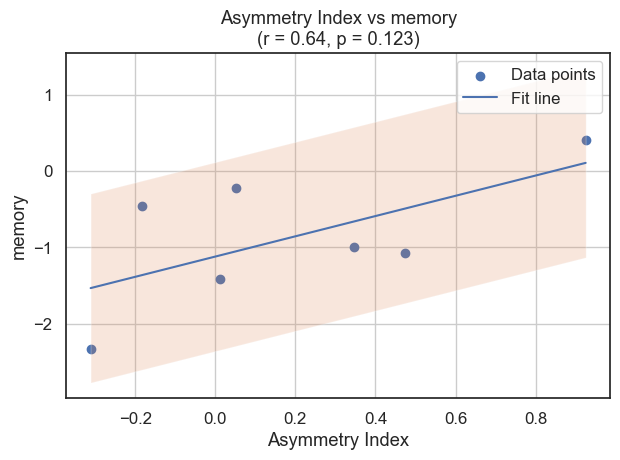

In [188]:
import pandas as pd
from scipy.stats import pearsonr, linregress
import numpy as np
import matplotlib.pyplot as plt

# Load the data
path = "figures/try_left_Ray.csv"
df = pd.read_csv(path)

# Columns of interest
col_x = "Asymmetry Index"
col_y = "memory"

# Drop NaNs
df_clean = df[[col_x, col_y]].dropna()
# remove subject ==DH3
df_clean = df_clean[df_clean.index != df[df['subject'] == 'DH3'].index[0]]
# Pearson correlation
corr, pval = pearsonr(df_clean[col_x], df_clean[col_y])
print(f"Pearson r = {corr:.3f}, p = {pval:.3e}")

# Regression line
slope, intercept, _, _, _ = linregress(df_clean[col_x], df_clean[col_y])
x_vals = np.linspace(df_clean[col_x].min(), df_clean[col_x].max(), 100)
y_vals = slope * x_vals + intercept

# Compute 95 percent confidence interval for the regression
y_err = np.std(df_clean[col_y] - (slope * df_clean[col_x] + intercept))
ci = 1.96 * y_err  # approx 95 percent CI

# Plot
plt.figure()
plt.scatter(df_clean[col_x], df_clean[col_y], label="Data points")
plt.plot(x_vals, y_vals, label="Fit line")

# Fill confidence interval
plt.fill_between(x_vals, y_vals - ci, y_vals + ci, alpha=0.2)

plt.xlabel(col_x)
plt.ylabel(col_y)
plt.title(f"{col_x} vs {col_y}\n(r = {corr:.2f}, p = {pval:.3f})")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


Pearson r = -0.544, p = 1.630e-01


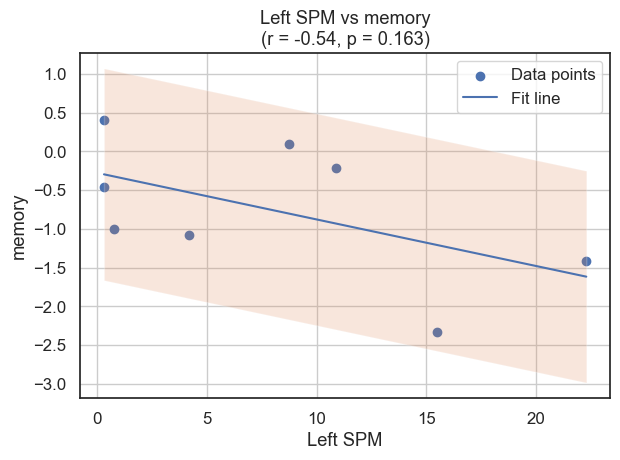

In [189]:
import pandas as pd
from scipy.stats import pearsonr, linregress
import numpy as np
import matplotlib.pyplot as plt

# Load the data
path = "figures/try_left_Ray.csv"
df = pd.read_csv(path)

# Columns of interest
col_x = "Left SPM"
col_y = "memory"

# Drop NaNs
df_clean = df[[col_x, col_y]].dropna()
# remove subject ==DH3
# df_clean = df_clean[df_clean.index != df[df['subject'] == 'DH3'].index[0]]
# Pearson correlation
corr, pval = pearsonr(df_clean[col_x], df_clean[col_y])
print(f"Pearson r = {corr:.3f}, p = {pval:.3e}")

# Regression line
slope, intercept, _, _, _ = linregress(df_clean[col_x], df_clean[col_y])
x_vals = np.linspace(df_clean[col_x].min(), df_clean[col_x].max(), 100)
y_vals = slope * x_vals + intercept

# Compute 95 percent confidence interval for the regression
y_err = np.std(df_clean[col_y] - (slope * df_clean[col_x] + intercept))
ci = 1.96 * y_err  # approx 95 percent CI

# Plot
plt.figure()
plt.scatter(df_clean[col_x], df_clean[col_y], label="Data points")
plt.plot(x_vals, y_vals, label="Fit line")

# Fill confidence interval
plt.fill_between(x_vals, y_vals - ci, y_vals + ci, alpha=0.2)

plt.xlabel(col_x)
plt.ylabel(col_y)
plt.title(f"{col_x} vs {col_y}\n(r = {corr:.2f}, p = {pval:.3f})")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


Pearson r = -0.315, p = 4.466e-01


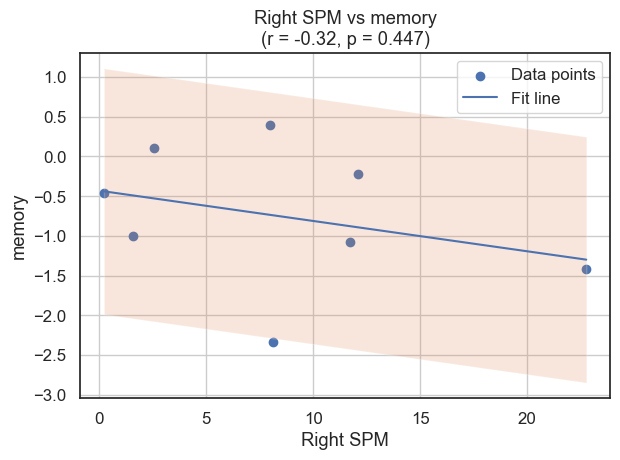

In [190]:
import pandas as pd
from scipy.stats import pearsonr, linregress
import numpy as np
import matplotlib.pyplot as plt

# Load the data
path = "figures/try_left_Ray.csv"
df = pd.read_csv(path)

# Columns of interest
col_x = "Right SPM"
col_y = "memory"

# Drop NaNs
df_clean = df[[col_x, col_y]].dropna()
# remove subject ==DH3
# df_clean = df_clean[df_clean.index != df[df['subject'] == 'DH3'].index[0]]
# Pearson correlation
corr, pval = pearsonr(df_clean[col_x], df_clean[col_y])
print(f"Pearson r = {corr:.3f}, p = {pval:.3e}")

# Regression line
slope, intercept, _, _, _ = linregress(df_clean[col_x], df_clean[col_y])
x_vals = np.linspace(df_clean[col_x].min(), df_clean[col_x].max(), 100)
y_vals = slope * x_vals + intercept

# Compute 95 percent confidence interval for the regression
y_err = np.std(df_clean[col_y] - (slope * df_clean[col_x] + intercept))
ci = 1.96 * y_err  # approx 95 percent CI

# Plot
plt.figure()
plt.scatter(df_clean[col_x], df_clean[col_y], label="Data points")
plt.plot(x_vals, y_vals, label="Fit line")

# Fill confidence interval
plt.fill_between(x_vals, y_vals - ci, y_vals + ci, alpha=0.2)

plt.xlabel(col_x)
plt.ylabel(col_y)
plt.title(f"{col_x} vs {col_y}\n(r = {corr:.2f}, p = {pval:.3f})")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


C:\Users\user\AppData\Local\Temp\ipykernel_10800\3543016446.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_epi_clean["subject"] = df_epi_clean["subject"].astype(str)


Merged samples: 24; unique subjects: 8
Subjects included: ['DH3', 'DR1', 'JR5', 'MA5', 'MF32', 'NG6', 'SA4', 'SS1']
Pearson correlation (all samples pooled): r = -0.519, p = 9.354e-03

--- MixedLM summary ---
             Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: memory_efficiency
No. Observations: 24      Method:             ML               
No. Groups:       8       Scale:              0.0000           
Min. group size:  3       Log-Likelihood:     158.0547         
Max. group size:  3       Converged:          Yes              
Mean group size:  3.0                                          
-----------------------------------------------------------------
            Coef.     Std.Err.     z      P>|z|   [0.025   0.975]
-----------------------------------------------------------------
Intercept   -0.751       0.170   -4.428   0.000   -1.084   -0.419
Left_SPM    -0.000       0.000   -0.000   1.000   -0.000    0.000
Group Var    0.230   12163

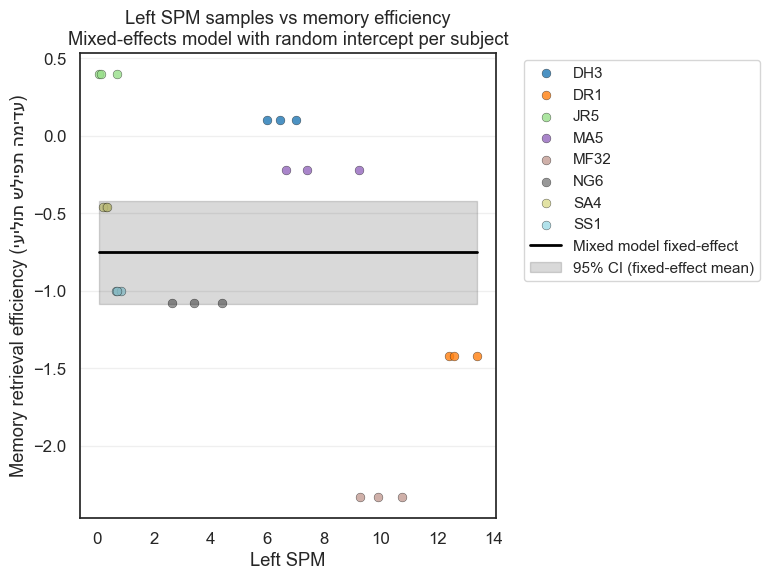

Fixed-effect Left_SPM: coef = -0.0000, p-value ~ 0.9999

Subject-level Pearson (mean Left_SPM vs memory): r = -0.523, p = 1.834e-01


In [192]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy.stats import pearsonr

# -----------------------
# File paths (edit if needed)
# -----------------------
PATH_ASYM = "figures/asymmetry_index_bins.csv"
PATH_EPI = "figures/EPI_Corr.csv"
OUTPUT_FIG = "figures/leftSPM_vs_memory_mixedlm.png"

# -----------------------
# Load data
# -----------------------
df_asym = pd.read_csv(PATH_ASYM)
df_epi = pd.read_csv(PATH_EPI, encoding='cp1255')

# -----------------------
# Column names & mapping
# -----------------------
left_col = "Left SPM"
memory_col_he = "יעילות שליפת המידע"   # Hebrew column name in EPI_Corr.csv
# We'll create safe ascii names to use in formulas/plots
df_asym = df_asym.rename(columns={left_col: "Left_SPM", "subject_base": "subject_base"})
df_epi = df_epi.rename(columns={memory_col_he: "memory_efficiency", "subject": "subject"})

# -----------------------
# Keep only rows/subjects with memory score
# -----------------------
df_epi_clean = df_epi.dropna(subset=["memory_efficiency"])
# Force strings for merging keys
df_asym["subject_base"] = df_asym["subject_base"].astype(str)
df_epi_clean["subject"] = df_epi_clean["subject"].astype(str)

# -----------------------
# Merge asymmetry samples with per-subject memory score
# Merge on: df_asym.subject_base  <-> df_epi_clean.subject
# -----------------------
df_merged = df_asym.merge(
    df_epi_clean[["subject", "memory_efficiency"]],
    left_on="subject_base",
    right_on="subject",
    how="inner",
)

# Drop rows with missing Left_SPM or memory
df_merged = df_merged.dropna(subset=["Left_SPM", "memory_efficiency"]).copy()

if df_merged.empty:
    raise RuntimeError("Merged dataframe is empty. Check that subject IDs and columns match.")

# -----------------------
# Quick summary
# -----------------------
n_subjects = df_merged["subject_base"].nunique()
n_samples = len(df_merged)
print(f"Merged samples: {n_samples}; unique subjects: {n_subjects}")
print("Subjects included:", sorted(df_merged["subject_base"].unique()))

# -----------------------
# Basic Pearson correlation (ignoring within-subject structure)
# This is informative but the inferential test below is mixed-model.
# -----------------------
pearson_r, pearson_p = pearsonr(df_merged["Left_SPM"], df_merged["memory_efficiency"])
print(f"Pearson correlation (all samples pooled): r = {pearson_r:.3f}, p = {pearson_p:.3e}")

# -----------------------
# Mixed-effects linear model:
# memory_efficiency ~ Left_SPM + (1 | subject_base)
# random intercept per subject_base to account for repeated Left_SPM samples
# -----------------------
# Use statsmodels MixedLM via formula API (groups=subject_base)
md = smf.mixedlm("memory_efficiency ~ Left_SPM", df_merged, groups=df_merged["subject_base"])
mdf = md.fit(reml=False)  # use ML for easier comparison of fixed effects (reml=False)
print("\n--- MixedLM summary ---")
print(mdf.summary())

# Extract fixed effects and covariance for CI calculation
fe_params = mdf.fe_params  # fixed effects coefficients (Intercept, Left_SPM)
cov_fe = mdf.cov_params()  # covariance matrix of fixed effects

# Random effect (group) variance and residual variance
# In MixedLM result:
# - mdf.cov_re is covariance matrix of random effects
# - mdf.scale is residual variance (sigma^2)
try:
    re_var = float(mdf.cov_re.iloc[0, 0])  # random intercept variance
except Exception:
    # fallback if cov_re is an array
    re_var = float(mdf.cov_re[0, 0]) if hasattr(mdf.cov_re, "__getitem__") else np.nan
resid_var = float(mdf.scale)

print(f"\nFixed effect (Left_SPM) estimate = {fe_params['Left_SPM']:.4f} (SE approx {np.sqrt(cov_fe.loc['Left_SPM','Left_SPM']):.4f})")
print(f"Random intercept variance (subject) = {re_var:.4f}")
print(f"Residual variance = {resid_var:.4f}")

# -----------------------
# Prepare prediction line + 95% CI for the mean prediction using fixed effects
# CI for mean: var(pred) = X' Cov(beta) X
# where X = [1, x]
# -----------------------
x_grid = np.linspace(df_merged["Left_SPM"].min(), df_merged["Left_SPM"].max(), 200)
X_mat = np.vstack([np.ones_like(x_grid), x_grid]).T  # shape (n_points, 2)
# build covariance matrix in same order as fe_params (Intercept, Left_SPM)
# cov_fe may have a different index order; ensure ordering
param_index = list(fe_params.index)
cov_fe_arr = cov_fe.loc[param_index, param_index].values

# compute se for each x
se_pred = np.array([np.sqrt((X_mat[i:i+1] @ cov_fe_arr @ X_mat[i:i+1].T)[0, 0]) for i in range(len(x_grid))])
y_pred = fe_params["Intercept"] + fe_params["Left_SPM"] * x_grid
ci_lower = y_pred - 1.96 * se_pred
ci_upper = y_pred + 1.96 * se_pred

# -----------------------
# Plotting
# -----------------------
plt.figure(figsize=(8, 6))
# scatter: plot raw samples, color by subject to show repeated measures
subjects = df_merged["subject_base"].unique()
colors = plt.cm.tab20(np.linspace(0, 1, len(subjects)))
color_map = dict(zip(subjects, colors))
for subj in subjects:
    s = df_merged[df_merged["subject_base"] == subj]
    plt.scatter(s["Left_SPM"], s["memory_efficiency"], alpha=0.8, label=subj, color=color_map[subj], s=40, edgecolor='k', linewidth=0.3)

# plot fixed-effect line and CI
plt.plot(x_grid, y_pred, color="black", lw=2, label="Mixed model fixed-effect")
plt.fill_between(x_grid, ci_lower, ci_upper, color="black", alpha=0.15, label="95% CI (fixed-effect mean)")

plt.xlabel("Left SPM")
plt.ylabel("Memory retrieval efficiency (יעילות שליפת המידע)")
plt.title("Left SPM samples vs memory efficiency\nMixed-effects model with random intercept per subject")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize="small", ncol=1)
plt.tight_layout()
plt.grid(axis="y", alpha=0.3)

# Save figure
# plt.savefig(OUTPUT_FIG, dpi=300)
print(f"\nPlot saved to {OUTPUT_FIG}")
plt.show()

# -----------------------
# Report fixed-effect p-value for Left_SPM
# -----------------------
# Some statsmodels versions report pvalues in mdf.pvalues or mdf.fe_pvalues
pval_left = None
if "Left_SPM" in mdf.pvalues.index:
    pval_left = mdf.pvalues["Left_SPM"]
else:
    # fallback: use zvalue and two-sided normal approx if available
    try:
        zval = mdf.tvalues["Left_SPM"]
        pval_left = 2 * (1 - np.abs(0.5 * (1 + np.math.erf(zval / np.sqrt(2)))))
    except Exception:
        pval_left = np.nan

print(f"Fixed-effect Left_SPM: coef = {fe_params['Left_SPM']:.4f}, p-value ~ {pval_left:.4g}")

# -----------------------
# Optional: per-subject aggregated correlation (one memory score per subject)
# This computes the average Left_SPM per subject and then correlates subject-average vs memory.
# -----------------------
df_subject_avg = df_merged.groupby("subject_base").agg(Left_SPM_mean=("Left_SPM", "mean"), memory=("memory_efficiency", "first")).reset_index()
if len(df_subject_avg) >= 3:
    r_subj, p_subj = pearsonr(df_subject_avg["Left_SPM_mean"], df_subject_avg["memory"])
    print(f"\nSubject-level Pearson (mean Left_SPM vs memory): r = {r_subj:.3f}, p = {p_subj:.3e}")
else:
    print("\nNot enough subjects for reliable subject-level Pearson correlation.")


C:\Users\user\AppData\Local\Temp\ipykernel_10800\3507452986.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_epi_clean["subject"] = df_epi_clean["subject"].astype(str)


Merged samples: 24; unique subjects: 8
Subjects included: ['DH3', 'DR1', 'JR5', 'MA5', 'MF32', 'NG6', 'SA4', 'SS1']
Pearson correlation (all samples pooled): r = -0.519, p = 9.354e-03

--- MixedLM summary ---
           Mixed Linear Model Regression Results
Model:              MixedLM   Dependent Variable:   Left_SPM
No. Observations:   24        Method:               ML      
No. Groups:         8         Scale:                0.4710  
Min. group size:    3         Log-Likelihood:       -43.1300
Max. group size:    3         Converged:            Yes     
Mean group size:    3.0                                     
------------------------------------------------------------
                  Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------
Intercept          3.114    1.816  1.714 0.086 -0.446  6.674
memory_efficiency -2.814    1.621 -1.736 0.083 -5.992  0.363
Group Var         14.370   12.961                           


Fixed ef

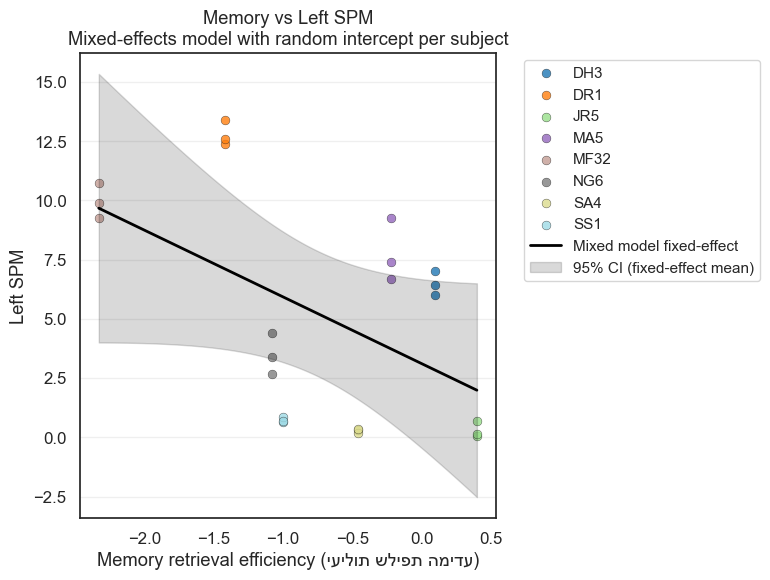

KeyError: 'Left_SPM'

In [194]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy.stats import pearsonr

# -----------------------
# File paths (edit if needed)
# -----------------------
PATH_ASYM = "figures/asymmetry_index_bins.csv"
PATH_EPI = "figures/EPI_Corr.csv"
OUTPUT_FIG = "figures/leftSPM_vs_memory_mixedlm.png"

# -----------------------
# Load data
# -----------------------
df_asym = pd.read_csv(PATH_ASYM)
df_epi = pd.read_csv(PATH_EPI, encoding='cp1255')

# -----------------------
# Column names & mapping
# -----------------------
left_col = "Left SPM"
memory_col_he = "יעילות שליפת המידע"   # Hebrew column name in EPI_Corr.csv
# We'll create safe ascii names to use in formulas/plots
df_asym = df_asym.rename(columns={left_col: "Left_SPM", "subject_base": "subject_base"})
df_epi = df_epi.rename(columns={memory_col_he: "memory_efficiency", "subject": "subject"})

# -----------------------
# Keep only rows/subjects with memory score
# -----------------------
df_epi_clean = df_epi.dropna(subset=["memory_efficiency"])
# Force strings for merging keys
df_asym["subject_base"] = df_asym["subject_base"].astype(str)
df_epi_clean["subject"] = df_epi_clean["subject"].astype(str)

# -----------------------
# Merge asymmetry samples with per-subject memory score
# Merge on: df_asym.subject_base  <-> df_epi_clean.subject
# -----------------------
df_merged = df_asym.merge(
    df_epi_clean[["subject", "memory_efficiency"]],
    left_on="subject_base",
    right_on="subject",
    how="inner",
)

# Drop rows with missing Left_SPM or memory
df_merged = df_merged.dropna(subset=["Left_SPM", "memory_efficiency"]).copy()

if df_merged.empty:
    raise RuntimeError("Merged dataframe is empty. Check that subject IDs and columns match.")

# -----------------------
# Quick summary
# -----------------------
n_subjects = df_merged["subject_base"].nunique()
n_samples = len(df_merged)
print(f"Merged samples: {n_samples}; unique subjects: {n_subjects}")
print("Subjects included:", sorted(df_merged["subject_base"].unique()))

# -----------------------
# Basic Pearson correlation (ignoring within-subject structure)
# This is informative but the inferential test below is mixed-model.
# -----------------------
pearson_r, pearson_p = pearsonr(df_merged["Left_SPM"], df_merged["memory_efficiency"])
print(f"Pearson correlation (all samples pooled): r = {pearson_r:.3f}, p = {pearson_p:.3e}")

# -----------------------
# Mixed-effects linear model:
# memory_efficiency ~ Left_SPM + (1 | subject_base)
# random intercept per subject_base to account for repeated Left_SPM samples
# -----------------------
# Use statsmodels MixedLM via formula API (groups=subject_base)
md = smf.mixedlm("Left_SPM ~ memory_efficiency", df_merged, groups=df_merged["subject_base"])
mdf = md.fit(reml=False)  # use ML for easier comparison of fixed effects (reml=False)
print("\n--- MixedLM summary ---")
print(mdf.summary())

# Extract fixed effects and covariance for CI calculation
fe_params = mdf.fe_params  # fixed effects coefficients (Intercept, Left_SPM)
cov_fe = mdf.cov_params()  # covariance matrix of fixed effects

# Random effect (group) variance and residual variance
# In MixedLM result:
# - mdf.cov_re is covariance matrix of random effects
# - mdf.scale is residual variance (sigma^2)
try:
    re_var = float(mdf.cov_re.iloc[0, 0])  # random intercept variance
except Exception:
    # fallback if cov_re is an array
    re_var = float(mdf.cov_re[0, 0]) if hasattr(mdf.cov_re, "__getitem__") else np.nan
resid_var = float(mdf.scale)


print(f"\nFixed effect (memory_efficiency) estimate = {fe_params['memory_efficiency']:.4f} "
      f"(SE approx {np.sqrt(cov_fe.loc['memory_efficiency','memory_efficiency']):.4f})")

print(f"Random intercept variance (subject) = {re_var:.4f}")
print(f"Residual variance = {resid_var:.4f}")

# -----------------------
# Prepare prediction line + 95% CI for the mean prediction using fixed effects
# CI for mean: var(pred) = X' Cov(beta) X
# where X = [1, x]
# -----------------------
x_grid = np.linspace(df_merged["memory_efficiency"].min(),
                     df_merged["memory_efficiency"].max(), 200)
X_mat = np.vstack([np.ones_like(x_grid), x_grid]).T  # shape (n_points, 2)
# build covariance matrix in same order as fe_params (Intercept, Left_SPM)
# cov_fe may have a different index order; ensure ordering
param_index = list(fe_params.index)
cov_fe_arr = cov_fe.loc[param_index, param_index].values

# compute se for each x
se_pred = np.array([np.sqrt((X_mat[i:i+1] @ cov_fe_arr @ X_mat[i:i+1].T)[0, 0]) for i in range(len(x_grid))])
y_pred = fe_params["Intercept"] + fe_params["memory_efficiency"] * x_grid
ci_lower = y_pred - 1.96 * se_pred
ci_upper = y_pred + 1.96 * se_pred

# -----------------------
# Plotting
# -----------------------
plt.figure(figsize=(8, 6))
# scatter: plot raw samples, color by subject to show repeated measures
subjects = df_merged["subject_base"].unique()
colors = plt.cm.tab20(np.linspace(0, 1, len(subjects)))
color_map = dict(zip(subjects, colors))
for subj in subjects:
    s = df_merged[df_merged["subject_base"] == subj]
    plt.scatter(s["memory_efficiency"], s["Left_SPM"], alpha=0.8, label=subj, color=color_map[subj], s=40, edgecolor='k', linewidth=0.3)

# plot fixed-effect line and CI
plt.plot(x_grid, y_pred, color="black", lw=2, label="Mixed model fixed-effect")
plt.fill_between(x_grid, ci_lower, ci_upper, color="black", alpha=0.15, label="95% CI (fixed-effect mean)")

plt.xlabel("Memory retrieval efficiency (יעילות שליפת המידע)")
plt.ylabel("Left SPM")
plt.title("Memory vs Left SPM\nMixed-effects model with random intercept per subject")

plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize="small", ncol=1)
plt.tight_layout()
plt.grid(axis="y", alpha=0.3)

# Save figure
# plt.savefig(OUTPUT_FIG, dpi=300)
print(f"\nPlot saved to {OUTPUT_FIG}")
plt.show()

# -----------------------
# Report fixed-effect p-value for Left_SPM
# -----------------------
# Some statsmodels versions report pvalues in mdf.pvalues or mdf.fe_pvalues
pval_left = None
if "Left_SPM" in mdf.pvalues.index:
    pval_left = mdf.pvalues["Left_SPM"]
else:
    # fallback: use zvalue and two-sided normal approx if available
    try:
        zval = mdf.tvalues["Left_SPM"]
        pval_left = 2 * (1 - np.abs(0.5 * (1 + np.math.erf(zval / np.sqrt(2)))))
    except Exception:
        pval_left = np.nan

print(f"Fixed-effect Left_SPM: coef = {fe_params['Left_SPM']:.4f}, p-value ~ {pval_left:.4g}")

# -----------------------
# Optional: per-subject aggregated correlation (one memory score per subject)
# This computes the average Left_SPM per subject and then correlates subject-average vs memory.
# -----------------------
df_subject_avg = df_merged.groupby("subject_base").agg(Left_SPM_mean=("Left_SPM", "mean"), memory=("memory_efficiency", "first")).reset_index()
if len(df_subject_avg) >= 3:
    r_subj, p_subj = pearsonr(df_subject_avg["Left_SPM_mean"], df_subject_avg["memory"])
    print(f"\nSubject-level Pearson (mean Left_SPM vs memory): r = {r_subj:.3f}, p = {p_subj:.3e}")
else:
    print("\nNot enough subjects for reliable subject-level Pearson correlation.")


C:\Users\user\AppData\Local\Temp\ipykernel_10800\1337624023.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_epi_clean["subject"] = df_epi_clean["subject"].astype(str)


Merged samples: 24, unique subjects: 8
Subjects: ['DH3', 'DR1', 'JR5', 'MA5', 'MF32', 'NG6', 'SA4', 'SS1']
Pearson (pooled): r = 0.270, p = 2.023e-01

--- MixedLM summary ---
            Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Asymmetry_Index
No. Observations: 24      Method:             ML             
No. Groups:       8       Scale:              0.0125         
Min. group size:  3       Log-Likelihood:     4.0703         
Max. group size:  3       Converged:          Yes            
Mean group size:  3.0                                        
-------------------------------------------------------------
                     Coef. Std.Err.   z   P>|z| [0.025 0.975]
-------------------------------------------------------------
Intercept            0.211    0.187 1.131 0.258 -0.155  0.578
memory_efficiency    0.136    0.167 0.814 0.416 -0.191  0.463
Group Var            0.150    0.841                          


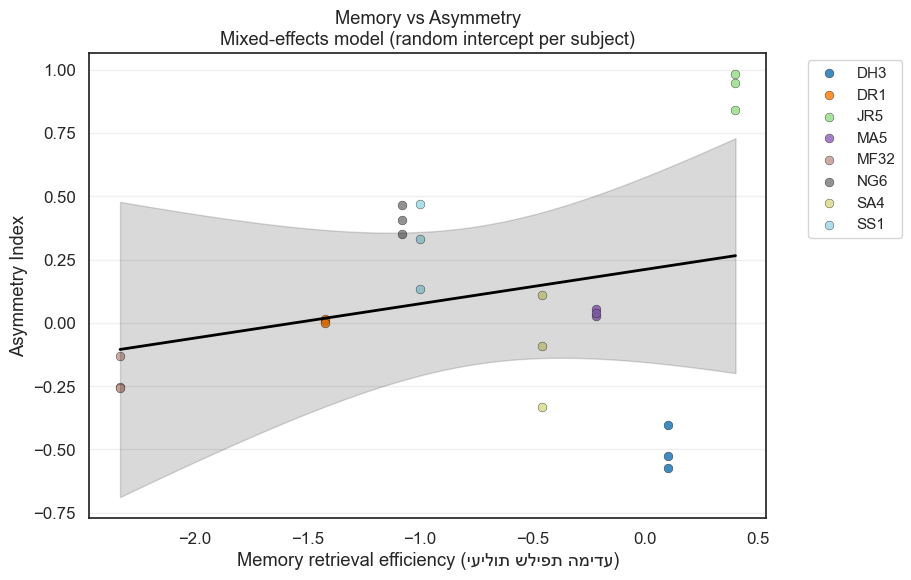

Fixed-effect memory: coef = 0.1357, p = 0.4157
Subject-level Pearson: r = 0.277, p = 5.074e-01


In [195]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy.stats import pearsonr

# -----------------------
# File paths (edit if needed)
# -----------------------
PATH_ASYM = "figures/asymmetry_index_bins.csv"
PATH_EPI = "figures/EPI_Corr.csv"
OUTPUT_FIG = "figures/asymmetry_vs_memory_mixedlm.png"

# -----------------------
# Load data
# -----------------------
df_asym = pd.read_csv(PATH_ASYM)
df_epi = pd.read_csv(PATH_EPI, encoding='cp1255')

# -----------------------
# Column renaming
# -----------------------
asym_col = "Asymmetry Index"
memory_col_he = "יעילות שליפת המידע"  # Hebrew column in EPI_Corr.csv

df_asym = df_asym.rename(columns={
    asym_col: "Asymmetry_Index",
    "subject_base": "subject_base"
})
df_epi = df_epi.rename(columns={
    memory_col_he: "memory_efficiency",
    "subject": "subject"
})

# -----------------------
# Filter only subjects with memory scores
# -----------------------
df_epi_clean = df_epi.dropna(subset=["memory_efficiency"])
df_asym["subject_base"] = df_asym["subject_base"].astype(str)
df_epi_clean["subject"] = df_epi_clean["subject"].astype(str)

# -----------------------
# Merge datasets
# -----------------------
df_merged = df_asym.merge(
    df_epi_clean[["subject", "memory_efficiency"]],
    left_on="subject_base",
    right_on="subject",
    how="inner",
)

df_merged = df_merged.dropna(subset=["Asymmetry_Index", "memory_efficiency"]).copy()

if df_merged.empty:
    raise RuntimeError("Merged dataframe is empty. Check matching subject IDs.")

# Summary print
n_subjects = df_merged["subject_base"].nunique()
print(f"Merged samples: {len(df_merged)}, unique subjects: {n_subjects}")
print("Subjects:", sorted(df_merged['subject_base'].unique()))

# -----------------------
# Pearson correlation (pooled)
# -----------------------
r, p = pearsonr(df_merged["Asymmetry_Index"], df_merged["memory_efficiency"])
print(f"Pearson (pooled): r = {r:.3f}, p = {p:.3e}")

# -----------------------
# Mixed-effects model
# -----------------------
md = smf.mixedlm("Asymmetry_Index ~ memory_efficiency",
                 df_merged,
                 groups=df_merged["subject_base"])
mdf = md.fit(reml=False)
print("\n--- MixedLM summary ---")
print(mdf.summary())

fe_params = mdf.fe_params
cov_fe = mdf.cov_params()

# -----------------------
# Extract CI for fixed effects prediction line
# -----------------------
x_grid = np.linspace(df_merged["memory_efficiency"].min(),
                     df_merged["memory_efficiency"].max(), 200)
X_mat = np.vstack([np.ones_like(x_grid), x_grid]).T

param_index = list(fe_params.index)
cov_fe_arr = cov_fe.loc[param_index, param_index].values

se_pred = np.array([
    np.sqrt((X_mat[i:i+1] @ cov_fe_arr @ X_mat[i:i+1].T)[0, 0])
    for i in range(len(x_grid))
])

y_pred = fe_params["Intercept"] + fe_params["memory_efficiency"] * x_grid
ci_low = y_pred - 1.96 * se_pred
ci_up = y_pred + 1.96 * se_pred

# -----------------------
# Plot
# -----------------------
plt.figure(figsize=(8, 6))
subjects = df_merged["subject_base"].unique()
colors = plt.cm.tab20(np.linspace(0, 1, len(subjects)))
color_map = dict(zip(subjects, colors))

for subj in subjects:
    s = df_merged[df_merged["subject_base"] == subj]
    plt.scatter(s["memory_efficiency"], s["Asymmetry_Index"],
                alpha=0.85, color=color_map[subj], s=40,
                edgecolor='k', linewidth=0.3,
                label=subj)

plt.plot(x_grid, y_pred, color="black", lw=2)
plt.fill_between(x_grid, ci_low, ci_up, color="black", alpha=0.15)

plt.xlabel("Memory retrieval efficiency (יעילות שליפת המידע)")
plt.ylabel("Asymmetry Index")
plt.title("Memory vs Asymmetry\nMixed-effects model (random intercept per subject)")
plt.tight_layout()
plt.grid(axis="y", alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize="small")
# plt.savefig(OUTPUT_FIG, dpi=300)
plt.show()

# -----------------------
# Report p-value
# -----------------------
pval = mdf.pvalues.get("memory_efficiency", np.nan)
print(f"Fixed-effect memory: coef = {fe_params['memory_efficiency']:.4f}, p = {pval:.4g}")

# -----------------------
# Subject-level summary
# -----------------------
df_avg = df_merged.groupby("subject_base").agg(
    Asym=("Asymmetry_Index", "mean"),
    mem=("memory_efficiency", "first")
).reset_index()

if len(df_avg) >= 3:
    r_s, p_s = pearsonr(df_avg["Asym"], df_avg["mem"])
    print(f"Subject-level Pearson: r = {r_s:.3f}, p = {p_s:.3e}")
else:
    print("Not enough subjects for subject-level Pearson.")


Kept 53 subjects with known sex (out of 74).
Groups by Sex:
group    Sex
AD       F       3
         M       7
Elderly  F      14
         M       8
MCI      F       9
         M      12
dtype: int64


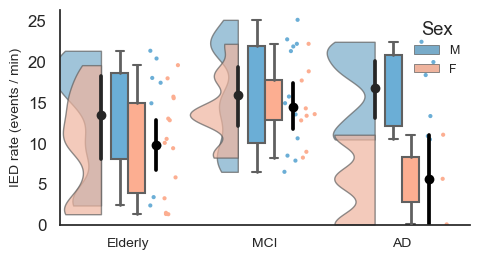

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import ptitprince as pt
from scipy.stats import f_oneway
import pandas as pd
import numpy as np

# ----------------------------
# Load main datasets
# ----------------------------
df = pd.read_csv('figures/MCI_rates_final.csv')
spikes_df = pd.read_csv('figures/V1_V2_combined.csv')
sex_info = pd.read_csv('figures/MCI_corr_final.csv')  # should contain 'subject' and 'Sex' columns

# Normalize column formats
for d in [df, spikes_df, sex_info]:
    for c in ['subject', 'group']:
        if c in d.columns:
            d[c] = d[c].astype(str).str.strip()

# ----------------------------
# Build the combined_means as before
# ----------------------------
data_subset_mean = df.groupby(['group', 'subject'], as_index=False)['Spikes_per_min'].mean()

young_src = spikes_df[spikes_df['group'] == 'HC'].copy()
young_mean = young_src.groupby('subject', as_index=False)['Spikes_per_min'].mean()
young_mean['group'] = 'Young'

combined_means = pd.concat(
    [data_subset_mean[['group', 'subject', 'Spikes_per_min']], young_mean[['group', 'subject', 'Spikes_per_min']]],
    ignore_index=True
)

combined_means['group'] = combined_means['group'].replace({'HC': 'Elderly'})

# ----------------------------
# Merge with sex info
# ----------------------------
# Expect columns: 'subject', 'Sex'
merged = pd.merge(
    combined_means,
    sex_info[['subject', 'Sex']],
    on='subject',
    how='inner'  # keep only those present in sex_info
)

# Check
print(f"Kept {len(merged)} subjects with known sex (out of {len(combined_means)}).")
print("Groups by Sex:")
print(merged.groupby(['group', 'Sex']).size())

# ----------------------------
# Define order and colors
# ----------------------------
group_order = ['Young', 'Elderly', 'MCI', 'AD']
palette = {
    ('Young', 'Male'): '#81b88e',
    ('Young', 'Female'): '#a4d4ac',
    ('Elderly', 'Male'): '#00826e',
    ('Elderly', 'Female'): '#33a391',
    ('MCI', 'Male'): '#F6B26B',
    ('MCI', 'Female'): '#f9c98d',
    ('AD', 'Male'): '#CC6677',
    ('AD', 'Female'): '#e28a9b'
}

# Create a combined hue label
merged['group_sex'] = merged['group'] + ' - ' + merged['Sex']

# ----------------------------
# Plot
# ----------------------------
sns.set_context("notebook", font_scale=1.1)
sns.set_style("white")

# Remove empty groups (no subjects)
present_groups = merged.groupby(['group', 'Sex']).size().reset_index(name='n')
present_groups = present_groups[present_groups['n'] > 0]
valid_groups = merged['group'].isin(present_groups['group'])
merged = merged[valid_groups]

fig, ax = plt.subplots(figsize=(5, 2.8))

# --- Clean RainCloud plot (no connecting lines)
pt.RainCloud(
    x='group', y='Spikes_per_min', hue='Sex',
    data=merged,
    order=[g for g in group_order if g in merged['group'].unique()],
    palette={'M': '#6baed6', 'F': '#fcae91'},
    bw=.3, width_viol=.7, move=0.25,
    orient='v', alpha=0.7,
    dodge=True,
    box_showfliers=False, width_box=0.25,
    ax=ax,
    pointplot=False  # <- disables the connecting lines
)

# --- Mean markers per group & sex (optional, neat summary)
sns.pointplot(
    data=merged,
    x='group', y='Spikes_per_min', hue='Sex',
    order=[g for g in group_order if g in merged['group'].unique()],
    dodge=0.4, join=False, color='black',
    markers='o', scale=0.8, errorbar='se', ax=ax
)

# --- Cleanup
ax.set_ylabel("IED rate (events / min)", fontsize=10)
ax.set_xlabel("")
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(fontsize=10)
ax.set_ylim(0, None)

# --- Single clean legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], labels[:2], title='Sex', frameon=False, fontsize=9)

plt.tight_layout()

plt.show()



In [9]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Filter only Elderly and MCI
data_test = merged[merged['group'].isin(['Elderly', 'MCI'])]

# Fit two-way ANOVA
model = ols('Spikes_per_min ~ C(group) + C(Sex) + C(group):C(Sex)', data=data_test).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)


                      sum_sq    df         F    PR(>F)
C(group)          133.365699   1.0  3.350219  0.074846
C(Sex)             65.586315   1.0  1.647564  0.206865
C(group):C(Sex)    11.639137   1.0  0.292381  0.591774
Residual         1552.514134  39.0       NaN       NaN


In [10]:
from scipy.stats import ttest_ind

for sex in ['M', 'F']:
    data_sex = data_test[data_test['Sex'] == sex]
    elderly_vals = data_sex[data_sex['group'] == 'Elderly']['Spikes_per_min']
    mci_vals = data_sex[data_sex['group'] == 'MCI']['Spikes_per_min']
    
    t_stat, p_val = ttest_ind(elderly_vals, mci_vals, equal_var=False)
    print(f"{sex}: t={t_stat:.3f}, p={p_val:.3f}")



M: t=-0.759, p=0.461
F: t=-2.029, p=0.056


In [11]:
import statsmodels.formula.api as smf

# Mixed model: Spikes ~ group + Sex + (1|subject)
model = smf.mixedlm("Spikes_per_min ~ group + Sex", data=data_test, groups=data_test["subject"])
result = model.fit()
print(result.summary())


           Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Spikes_per_min
No. Observations: 43      Method:             REML          
No. Groups:       43      Scale:              19.5519       
Min. group size:  1       Log-Likelihood:     -134.3126     
Max. group size:  1       Converged:          Yes           
Mean group size:  1.0                                       
-------------------------------------------------------------
              Coef.   Std.Err.    z     P>|z|  [0.025  0.975]
-------------------------------------------------------------
Intercept     10.232     0.220  46.427  0.000   9.800  10.664
group[T.MCI]   3.602     1.532   2.351  0.019   0.599   6.605
Sex[T.M]       2.532     1.766   1.433  0.152  -0.930   5.994
Group Var     19.552                                         


C:\Users\user\anaconda3\envs\depth_ieds\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2262: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


One-way ANOVA (Young vs Elderly vs MCI vs AD) on per-subject means: F=22.417, p=3.051e-10


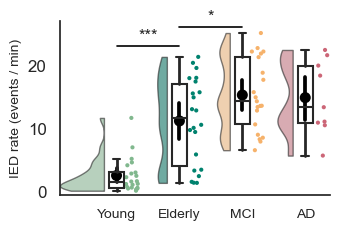

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import ptitprince as pt
from scipy.stats import f_oneway
import pandas as pd
import numpy as np

# Styling
sns.set_context("notebook", font_scale=1.1)
sns.set_style("white")

# ----- קבוצה מקורית: HC / MCI / AD -----
df = pd.read_csv('figures/MCI_rates_final.csv')  # מצופה: group, subject, Spikes_per_min
data_subset = df.copy()
data_subset['group'] = data_subset['group'].astype(str).str.strip()
data_subset['subject'] = data_subset['subject'].astype(str).str.strip()

# ממוצע פר-נבדק לכל קבוצה קיימת
data_subset_mean = data_subset.groupby(['group', 'subject'], as_index=False)['Spikes_per_min'].mean()

# ----- קבוצה חדשה: Young (נלקח מ-HC מתוך V1_V2_combined.csv) -----
spikes_df = pd.read_csv('figures/V1_V2_combined.csv')  # מצופה: subject, Spikes_per_min, part, group(=HC/...)
spikes_df['group'] = spikes_df['group'].astype(str).str.strip()
spikes_df['subject'] = spikes_df['subject'].astype(str).str.strip()

young_src = spikes_df[spikes_df['group'] == 'HC'].copy()
young_mean = young_src.groupby('subject', as_index=False)['Spikes_per_min'].mean()
young_mean['group'] = 'Young'  # שם קבוצה חדש

# נתוני ממוצע פר-נבדק לכל הקבוצות יחד (Young + HC/MCI/AD)
combined_means = pd.concat(
    [data_subset_mean[['group', 'subject', 'Spikes_per_min']], young_mean[['group', 'subject', 'Spikes_per_min']]],
    ignore_index=True
)

# שינוי שם HC -> Elderly (לנוחות הצגה)
combined_means['group'] = combined_means['group'].replace({'HC': 'Elderly'})
# remove specific subject if needed
combined_means = combined_means[combined_means['subject'] != 'SK6']
# ----- סדר וקולורים -----
group_order = ['Young', 'Elderly', 'MCI', 'AD']
palette = ['#81b88e', '#00826e', '#F6B26B', '#CC6677']  # Young=ירוק בהיר, Elderly=זית כהה, MCI=כתום, AD=בורדו

# ----- ANOVA (one-way) על ממוצעי נבדק בארבע הקבוצות -----
groups = [
    combined_means.loc[combined_means['group'] == g, 'Spikes_per_min'].dropna().values
    for g in group_order
]
if any(len(a) == 0 for a in groups):
    print("Cannot run ANOVA: one or more groups are empty.")
else:
    F, p = f_oneway(*groups)
    print(f"One-way ANOVA (Young vs Elderly vs MCI vs AD) on per-subject means: F={F:.3f}, p={p:.4g}")

# ----- ציור -----
# Increased width to accommodate larger violins and prevent clipping
PER_GROUP_INCH = 1.2       # Increased from 1.0 to give more space
HEIGHT_INCH    = 2.5

fig, ax = plt.subplots(figsize=(PER_GROUP_INCH * len(group_order)*0.75, HEIGHT_INCH))

# ---- RainCloud with larger violins ----
pt.RainCloud(
    x='group', y='Spikes_per_min',
    data=combined_means,
    order=group_order,
    palette=palette,
    bw=.3,
    width_viol=1.4,    # Increased from 0.80 to make violins larger
    width_box=0.24,    
    move=0.25,         
    ax=ax, orient='v',
    alpha=0.6,
    pointplot=False,
    box_showfliers=False
)

# ממוצעים
sns.pointplot(
    data=combined_means, x='group', y='Spikes_per_min',
    order=group_order, color='black',
    join=False, markers='o', errorbar=None, scale=0.9, ax=ax
)

# Updated function for flat significance lines (no vertical connectors)
def add_sig_flat(ax, x1, x2, y_frac, text):
    """Add flat significance line without vertical connectors"""
    y0, y1 = ax.get_ylim()
    span = y1 - y0
    y = y0 + y_frac * span
    
    # Draw only horizontal line
    ax.plot([x1, x2], [y, y], color='black', lw=1.2)
    
    # Add text above the line
    ax.text((x1+x2)/2, y + 0.015 * span, text, ha='center', va='bottom', fontsize=12)

# Flat significance lines
add_sig_flat(ax, 0, 1, 0.88, '***')  # Young–Elderly
add_sig_flat(ax, 1, 2, 0.99, '*')    # Elderly–MCI

# עיצוב
ax.set_ylabel("IED rate (events / min)", fontsize=10)
ax.set_xlabel("")
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Adjust x-axis limits to prevent clipping of the leftmost violin
ax.set_xlim(-0.9, 3.4)  # Give more space on the left side
ax.set_ylim(-0.6, 27)   # Keep original y limits
ax.set_xticklabels(['Young', 'Elderly', 'MCI', 'AD'])

# x font
plt.xticks(fontsize=10)

plt.tight_layout()
plt.show()

In [8]:
from scipy.stats import ttest_ind

# וקטורים של Elderly ו-AD אחרי הסינון של SK6
elderly = combined_means.loc[combined_means['group'] == 'Elderly', 'Spikes_per_min'].values
ad      = combined_means.loc[combined_means['group'] == 'AD',       'Spikes_per_min'].values

print("N Elderly:", len(elderly), "N AD:", len(ad))

t_stat, p_val = ttest_ind(elderly, ad, equal_var=False)  # Welch t-test
print(f"Elderly vs AD: t = {t_stat:.3f}, p = {p_val:.4g}")

N Elderly: 22 N AD: 9
Elderly vs AD: t = -1.518, p = 0.1473


In [9]:
p_one_sided = p_val / 2 if t_stat > 0 else 1 - p_val / 2
print(f"One-sided p (AD > Elderly): {p_one_sided:.4g}")


One-sided p (AD > Elderly): 0.9264
